# Themes 1–3 · Political engagement, instability, aspirations, and the South Asian outlook

## Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy.stats import chi2_contingency


In [2]:
# Warm grey-and-teal report theme, based on the selected reference chart.
REPORT_BG = "#F4F1E8"
REPORT_INK = "#252421"
REPORT_MUTED = "#6F6C65"
REPORT_GRID = "#D8D3C8"
REPORT_GREY = "#77756F"
REPORT_LIGHT_GREY = "#AAA79F"
REPORT_TEAL = "#16876F"
REPORT_TEAL_MID = "#63B19E"
REPORT_TEAL_LIGHT = "#A7D2C7"

sns.set_theme(style="white")
plt.rcParams.update({
    "figure.facecolor": REPORT_BG,
    "axes.facecolor": REPORT_BG,
    "savefig.facecolor": REPORT_BG,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelcolor": REPORT_INK,
    "axes.titlecolor": REPORT_INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.color": REPORT_MUTED,
    "ytick.color": REPORT_MUTED,
    "text.color": REPORT_INK,
    "axes.edgecolor": REPORT_INK,
    "grid.color": REPORT_GRID,
    "grid.linewidth": 0.8,
    "figure.dpi": 115,
})

REPORT_CMAP = sns.light_palette(REPORT_TEAL, as_cmap=True)


def report_title(ax, title):
    # Apply the compact centered title used throughout the report.

    ax.set_title(
        title,
        loc="center",
        fontsize=13,
        fontweight="bold",
        color=REPORT_INK,
        pad=15,
    )


def report_axes(ax, grid_axis="x"):
    # Use dark baseline axes, a warm background, and quiet gridlines.

    ax.set_facecolor(REPORT_BG)
    ax.figure.patch.set_facecolor(REPORT_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(REPORT_INK)
    ax.spines["bottom"].set_color(REPORT_INK)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(axis="both", colors=REPORT_MUTED, width=0.9)
    ax.grid(False)
    ax.grid(axis=grid_axis, color=REPORT_GRID, linewidth=0.8)
    ax.set_axisbelow(True)


def report_parity_line(ax):
    # Mark a ratio of one with a direct label rather than a legend.

    ax.axvline(
        1,
        color=REPORT_MUTED,
        linestyle=(0, (3, 2)),
        linewidth=1.1,
        zorder=3,
    )
    ax.annotate(
        "Parity = 1.0",
        xy=(1, 1),
        xycoords=("data", "axes fraction"),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=REPORT_MUTED,
        clip_on=False,
    )


def report_heatmap_text(ax, values):
    # Keep heatmap annotations legible on light and dark cells.

    maximum = float(np.nanmax(values.to_numpy()))
    threshold = maximum * 0.62
    for label, value in zip(ax.texts, values.to_numpy().ravel()):
        label.set_color("white" if value >= threshold else REPORT_INK)
        label.set_fontsize(8.5)


def highlight_bar_colors(values):
    # Highlight the two largest bars while keeping the rest neutral.

    values = pd.Series(values)
    colors = [REPORT_GREY] * len(values)
    if len(values) >= 2:
        second, first = values.nlargest(2).index[::-1]
        colors[second] = REPORT_TEAL_LIGHT
        colors[first] = REPORT_TEAL
    elif len(values) == 1:
        colors[0] = REPORT_TEAL
    return colors


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.precision", 1)

## Import the finalized survey data


In [3]:
data_path = Path("../1_data/2_clean/student_survey_cleaned.dta")

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

df = pd.read_stata(data_path)

print(f"Dataset loaded successfully: {df.shape[0]:,} respondents and {df.shape[1]} variables.")


Dataset loaded successfully: 836 respondents and 115 variables.


In [4]:
assert len(df) == 836, f"Expected 836 respondents, found {len(df)}"
assert df["interview_date"].min() >= pd.Timestamp("2026-08-23")
print("Final analysis sample confirmed: 836 respondents; pilot interviews excluded.")


Final analysis sample confirmed: 836 respondents; pilot interviews excluded.


In [5]:
# Correct the age-cohort labels that arrived with a text-encoding character.
if isinstance(df["age_cohort"].dtype, pd.CategoricalDtype):
    clean_age_labels = ["18–21", "22–25", "26–29", "30–35"]
    if len(df["age_cohort"].cat.categories) == len(clean_age_labels):
        df["age_cohort"] = df["age_cohort"].cat.rename_categories(
            clean_age_labels
        )


def stata_tabulate(data, variable, exclude_values=None):
    # Return a Stata-style one-way frequency table.

    series = data[variable]

    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        series = series.replace(r"^\s*$", pd.NA, regex=True)

    missing_n = int(series.isna().sum())
    excluded_n = 0

    if exclude_values:
        exclude_mask = series.astype("string").isin(exclude_values)
        excluded_n = int(exclude_mask.sum())
        series = series.mask(exclude_mask)

    valid = series.dropna()
    if isinstance(valid.dtype, pd.CategoricalDtype):
        valid = valid.cat.remove_unused_categories()
    counts = valid.value_counts(sort=False)

    table = counts.rename("Frequency").to_frame()
    table["Percent"] = table["Frequency"].div(len(valid)).mul(100)
    table["Cumulative percent"] = table["Percent"].cumsum()
    table.index.name = "Category"

    summary = f"Valid N = {len(valid):,}; missing = {missing_n:,}"
    if excluded_n:
        summary += f"; excluded = {excluded_n:,}"
    print(summary)

    return table.round({"Percent": 1, "Cumulative percent": 1})


def plot_frequency_bar(data, variable, title, exclude_values=None):
    # Plot valid-response percentages using the report theme.

    series = data[variable]

    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        series = series.replace(r"^\s*$", pd.NA, regex=True)

    if exclude_values:
        exclude_mask = series.astype("string").isin(exclude_values)
        series = series.mask(exclude_mask)

    valid = series.dropna()
    if isinstance(valid.dtype, pd.CategoricalDtype):
        valid = valid.cat.remove_unused_categories()
    percentages = valid.value_counts(sort=False, normalize=True).mul(100)

    figure_height = max(3.0, 0.46 * len(percentages) + 1.5)
    fig, ax = plt.subplots(figsize=(8.2, figure_height))
    bars = ax.barh(
        percentages.index.astype(str),
        percentages.values,
        color=highlight_bar_colors(percentages.values),
        height=0.72,
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.1f}%" for value in percentages.values],
        padding=5,
        fontsize=9,
        color=REPORT_INK,
    )

    report_title(ax, title)
    report_axes(ax, grid_axis="x")
    ax.set_xlabel("Percent of valid responses")
    ax.set_ylabel("")
    ax.set_xlim(0, max(100, percentages.max() + 12))
    ax.invert_yaxis()

    plt.tight_layout(pad=1.2)
    plt.show()

## 1. Political salience

Question 2.1 asks whether respondents agree that politics is central to living in Nepal. The full five-category response is retained. “Prefer not to say” and any “do not know” variants are excluded from substantive percentages rather than combined with Neutral.


In [6]:
q2_1_order = [
    "Strongly Agree", "Agree", "Neutral", "Disagree", "Strongly Disagree"
]

q2_1_text = df["q2_1"].astype("string").str.strip()
non_substantive_variants = {
    "prefer not to say", "do not know", "don't know", "dont know", "do_not_know"
}
q2_1_recode = q2_1_text.mask(
    q2_1_text.str.lower().isin(non_substantive_variants),
    pd.NA,
)

education_order = [
    "Bachelors 1st year",
    "Bachelors 2nd year",
    "Bachelors 3rd year",
    "Bachelors final year",
    "Masters 1st year",
    "Masters 2nd year",
]
education_analysis = (
    df["education"].astype("string").str.strip()
    .replace({
        "Bachelors 4th year": "Bachelors final year",
        "Bachelors 5th year": "Bachelors final year",
    })
)
education_analysis = education_analysis.mask(education_analysis.eq("PHD"))
education_analysis = pd.Categorical(
    education_analysis, categories=education_order, ordered=True
)


def grouped_response_summary(group, response, group_order, response_order, index_name):
    # Return counts, row percentages, and a report-ready combined table.
    counts = (
        pd.crosstab(group, response)
        .reindex(index=group_order, columns=response_order, fill_value=0)
    )
    percentages = counts.div(counts.sum(axis=1), axis=0).mul(100)
    table = counts.astype(int).astype(str) + " (" + percentages.map(
        lambda value: f"{value:.1f}%"
    ) + ")"
    table["Total n"] = counts.sum(axis=1).astype(int)
    table.index.name = index_name
    table.columns.name = "Response: n (row %)"
    return counts, percentages, table


age_order = list(df["age_cohort"].cat.categories)
age_q2_1_counts, age_q2_1_pct, age_q2_1_table = grouped_response_summary(
    df["age_cohort"], q2_1_recode, age_order, q2_1_order, "Age cohort"
)
education_q2_1_counts, education_q2_1_pct, education_q2_1_table = (
    grouped_response_summary(
        education_analysis,
        q2_1_recode,
        education_order,
        q2_1_order,
        "Education level and year",
    )
)

print(
    f"Non-substantive q2_1 responses excluded from row percentages: "
    f"{int(q2_1_recode.isna().sum()):,}"
)
display(HTML("<h4>Age cohort</h4>"))
display(age_q2_1_table)
display(HTML("<h4>Education level and year</h4>"))
display(education_q2_1_table)


Non-substantive q2_1 responses excluded from row percentages: 12


Response: n (row %),Strongly Agree,Agree,Neutral,Disagree,Strongly Disagree,Total n
Age cohort,,,,,,
18–21,31 (8.5%),94 (25.7%),66 (18.0%),98 (26.8%),77 (21.0%),366
22–25,40 (10.9%),116 (31.7%),65 (17.8%),89 (24.3%),56 (15.3%),366
26–29,13 (16.7%),19 (24.4%),16 (20.5%),18 (23.1%),12 (15.4%),78
30–35,2 (14.3%),5 (35.7%),1 (7.1%),5 (35.7%),1 (7.1%),14


Response: n (row %),Strongly Agree,Agree,Neutral,Disagree,Strongly Disagree,Total n
Education level and year,,,,,,
Bachelors 1st year,16 (10.6%),42 (27.8%),35 (23.2%),33 (21.9%),25 (16.6%),151
Bachelors 2nd year,19 (10.9%),48 (27.6%),29 (16.7%),41 (23.6%),37 (21.3%),174
Bachelors 3rd year,19 (9.0%),58 (27.5%),31 (14.7%),63 (29.9%),40 (19.0%),211
Bachelors final year,21 (10.8%),61 (31.3%),35 (17.9%),49 (25.1%),29 (14.9%),195
Masters 1st year,5 (7.9%),17 (27.0%),13 (20.6%),18 (28.6%),10 (15.9%),63
Masters 2nd year,6 (20.7%),8 (27.6%),5 (17.2%),5 (17.2%),5 (17.2%),29


### Response patterns by age cohort and education


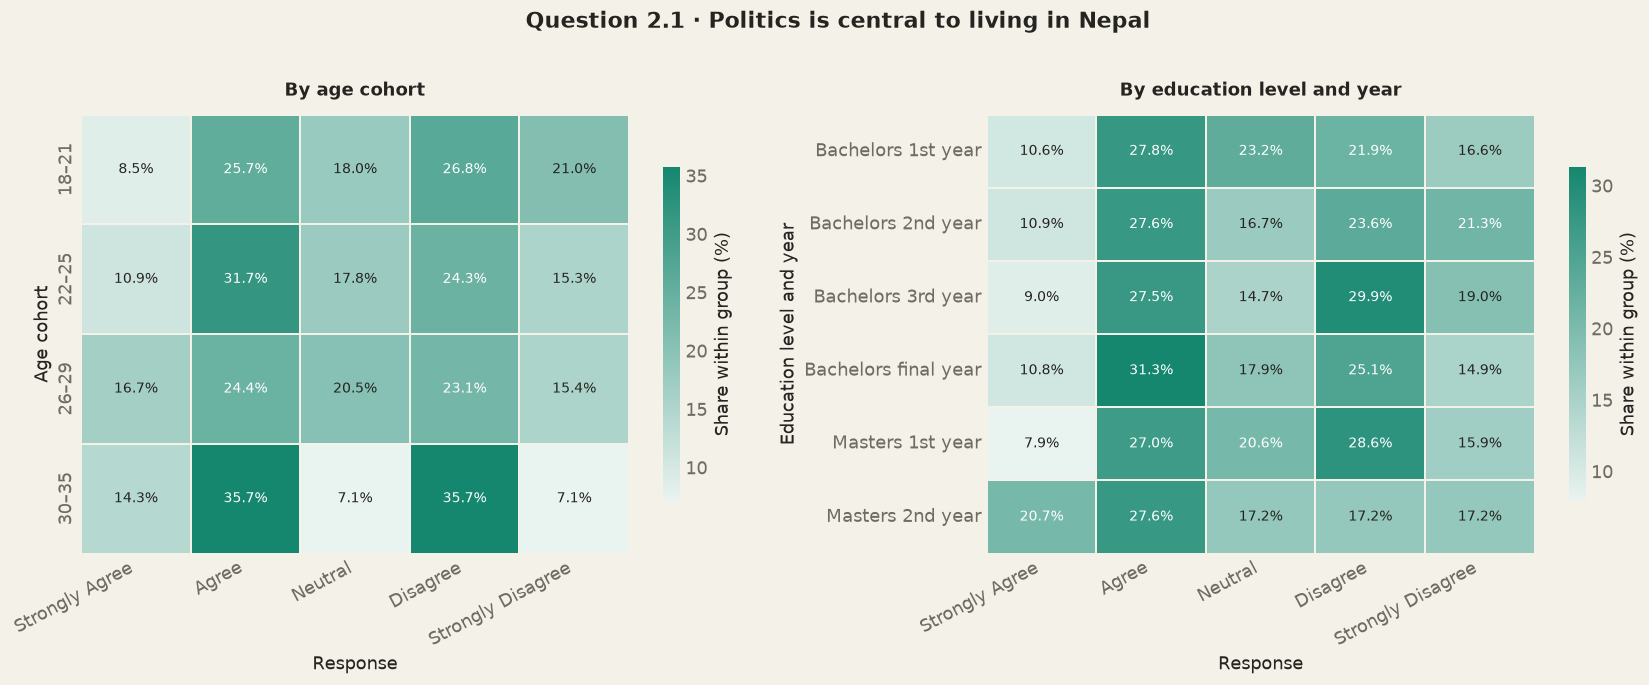

In [7]:
def draw_response_heatmap(ax, percentages, title, y_label, x_rotation=25):
    labels = percentages.map(lambda value: f"{value:.1f}%")
    heatmap = sns.heatmap(
        percentages,
        annot=labels,
        fmt="",
        cmap=REPORT_CMAP,
        linewidths=1.0,
        linecolor=REPORT_BG,
        cbar_kws={"label": "Share within group (%)", "shrink": 0.76},
        ax=ax,
    )
    ax.set_title(title, fontsize=11.5, fontweight="bold", pad=12)
    ax.set_xlabel("Response")
    ax.set_ylabel(y_label)
    ax.tick_params(axis="both", length=0, colors=REPORT_MUTED)
    ax.tick_params(axis="x", rotation=x_rotation)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    heatmap.collections[0].colorbar.outline.set_visible(False)
    heatmap.collections[0].colorbar.ax.tick_params(length=0, colors=REPORT_MUTED)
    report_heatmap_text(ax, percentages)


fig, axes = plt.subplots(1, 2, figsize=(14.8, 5.8))
fig.suptitle(
    "Question 2.1 · Politics is central to living in Nepal",
    fontsize=14,
    fontweight="bold",
    color=REPORT_INK,
    y=1.02,
)
draw_response_heatmap(
    axes[0], age_q2_1_pct, "By age cohort", "Age cohort", x_rotation=28
)
draw_response_heatmap(
    axes[1],
    education_q2_1_pct,
    "By education level and year",
    "Education level and year",
    x_rotation=28,
)
plt.tight_layout(pad=1.1, w_pad=2.0)
plt.show()

### Agreement-to-disagreement ratios

The ratio divides combined agreement by combined disagreement. Neutral and non-substantive responses are excluded. Values above one indicate more agreement; values below one indicate more disagreement.


,Agree n,Disagree n,Agree/disagree ratio,Direction
Age cohort,,,,
18–21,125,175,0.71,More disagreement
22–25,156,145,1.08,More agreement
26–29,32,30,1.07,More agreement
30–35,7,6,1.17,More agreement


,Agree n,Disagree n,Agree/disagree ratio,Direction
Education level and year,,,,
Bachelors 1st year,58,58,1.00,Equal
Bachelors 2nd year,67,78,0.86,More disagreement
Bachelors 3rd year,77,103,0.75,More disagreement
Bachelors final year,82,78,1.05,More agreement
Masters 1st year,22,28,0.79,More disagreement
Masters 2nd year,14,10,1.40,More agreement


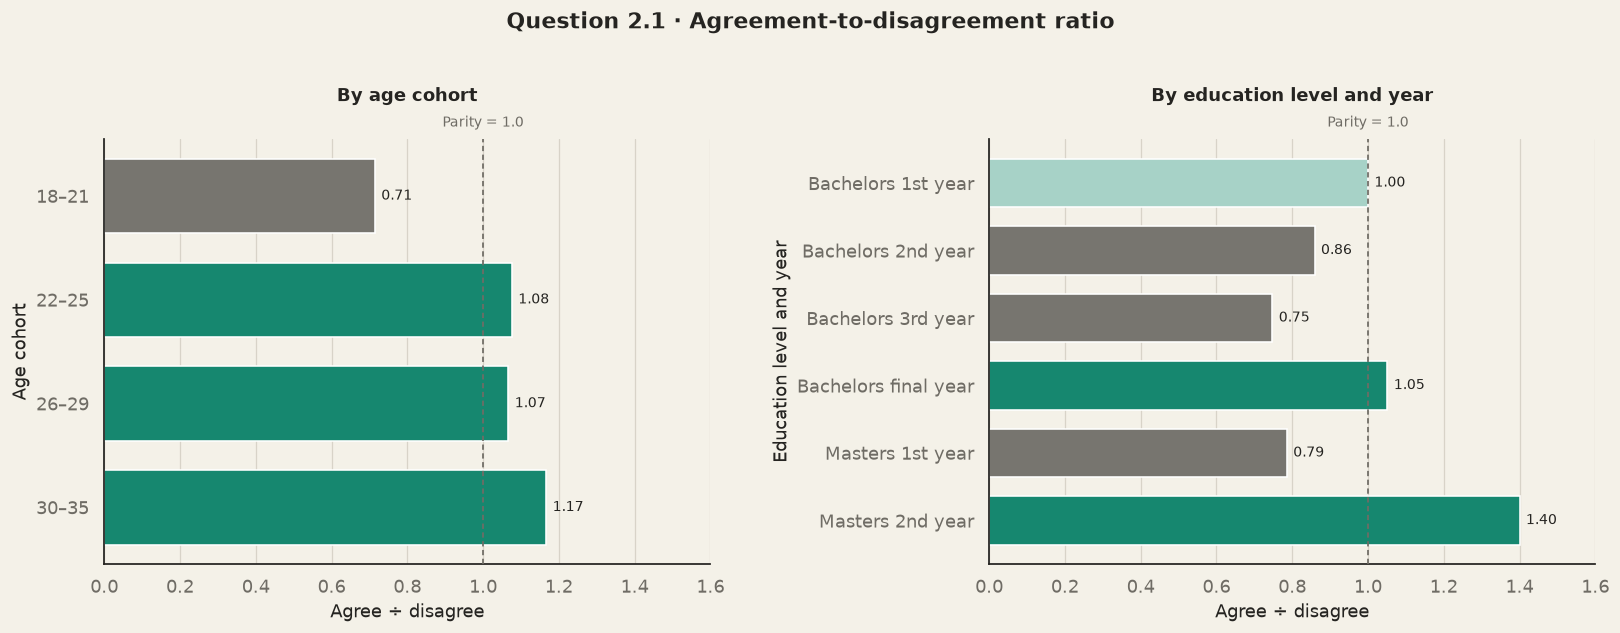

In [8]:
def build_agreement_ratio(counts):
    agree = counts[["Strongly Agree", "Agree"]].sum(axis=1)
    disagree = counts[["Disagree", "Strongly Disagree"]].sum(axis=1)
    ratio = agree.div(disagree.replace(0, np.nan))
    table = pd.DataFrame({
        "Agree n": agree.astype(int),
        "Disagree n": disagree.astype(int),
        "Agree/disagree ratio": ratio.map(lambda value: f"{value:.2f}"),
        "Direction": np.select(
            [ratio > 1, ratio < 1],
            ["More agreement", "More disagreement"],
            default="Equal",
        ),
    })
    return ratio, table


def draw_agreement_ratio(ax, ratios, title, x_limit):
    colors = [
        REPORT_TEAL if value > 1
        else REPORT_TEAL_LIGHT if value == 1
        else REPORT_GREY
        for value in ratios
    ]
    bars = ax.barh(
        ratios.index.astype(str),
        ratios.values,
        color=colors,
        height=0.72,
        zorder=2,
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.2f}" for value in ratios],
        padding=4,
        fontsize=8.5,
        color=REPORT_INK,
    )
    report_parity_line(ax)
    report_axes(ax, grid_axis="x")
    ax.set_title(title, fontsize=11.5, fontweight="bold", pad=24)
    ax.set_xlabel("Agree ÷ disagree")
    ax.set_ylabel("")
    ax.set_xlim(0, x_limit)
    ax.invert_yaxis()


age_agreement_ratio, age_agreement_table = build_agreement_ratio(
    age_q2_1_counts
)
education_agreement_ratio, education_agreement_table = build_agreement_ratio(
    education_q2_1_counts
)
age_agreement_table.index.name = "Age cohort"
education_agreement_table.index.name = "Education level and year"

display(HTML("<h4>Age cohort</h4>"))
display(age_agreement_table)
display(HTML("<h4>Education level and year</h4>"))
display(education_agreement_table)

shared_ratio_limit = max(
    1.6,
    age_agreement_ratio.max() + 0.2,
    education_agreement_ratio.max() + 0.2,
)
fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.3))
fig.suptitle(
    "Question 2.1 · Agreement-to-disagreement ratio",
    fontsize=14,
    fontweight="bold",
    color=REPORT_INK,
    y=1.03,
)
draw_agreement_ratio(
    axes[0], age_agreement_ratio, "By age cohort", shared_ratio_limit
)
draw_agreement_ratio(
    axes[1], education_agreement_ratio, "By education level and year", shared_ratio_limit
)
axes[0].set_ylabel("Age cohort")
axes[1].set_ylabel("Education level and year")
plt.tight_layout(pad=1.1, w_pad=3.0)
plt.show()

## 2. Political-news consumption

Question 2.2 records how often respondents follow political news. The original five response categories are retained.


In [9]:
q2_2_order = [
    "Daily", "Several times a week", "Weekly", "Occasionally", "Never"
]
q2_2_recode = df["q2_2"].astype("string").str.strip()

age_q2_2_counts, age_q2_2_pct, age_q2_2_table = grouped_response_summary(
    df["age_cohort"], q2_2_recode, age_order, q2_2_order, "Age cohort"
)
education_q2_2_counts, education_q2_2_pct, education_q2_2_table = (
    grouped_response_summary(
        education_analysis,
        q2_2_recode,
        education_order,
        q2_2_order,
        "Education level and year",
    )
)

display(HTML("<h4>Age cohort</h4>"))
display(age_q2_2_table)
display(HTML("<h4>Education level and year</h4>"))
display(education_q2_2_table)

Response: n (row %),Daily,Several times a week,Weekly,Occasionally,Never,Total n
Age cohort,,,,,,
18–21,164 (43.6%),100 (26.6%),20 (5.3%),83 (22.1%),9 (2.4%),376
22–25,206 (56.0%),103 (28.0%),7 (1.9%),48 (13.0%),4 (1.1%),368
26–29,64 (82.1%),6 (7.7%),3 (3.8%),5 (6.4%),0 (0.0%),78
30–35,12 (85.7%),2 (14.3%),0 (0.0%),0 (0.0%),0 (0.0%),14


Response: n (row %),Daily,Several times a week,Weekly,Occasionally,Never,Total n
Education level and year,,,,,,
Bachelors 1st year,61 (39.4%),39 (25.2%),12 (7.7%),38 (24.5%),5 (3.2%),155
Bachelors 2nd year,77 (43.3%),55 (30.9%),6 (3.4%),36 (20.2%),4 (2.2%),178
Bachelors 3rd year,114 (53.8%),58 (27.4%),7 (3.3%),31 (14.6%),2 (0.9%),212
Bachelors final year,123 (62.1%),45 (22.7%),1 (0.5%),27 (13.6%),2 (1.0%),198
Masters 1st year,43 (68.3%),12 (19.0%),4 (6.3%),4 (6.3%),0 (0.0%),63
Masters 2nd year,27 (93.1%),2 (6.9%),0 (0.0%),0 (0.0%),0 (0.0%),29


### Response patterns by age cohort and education


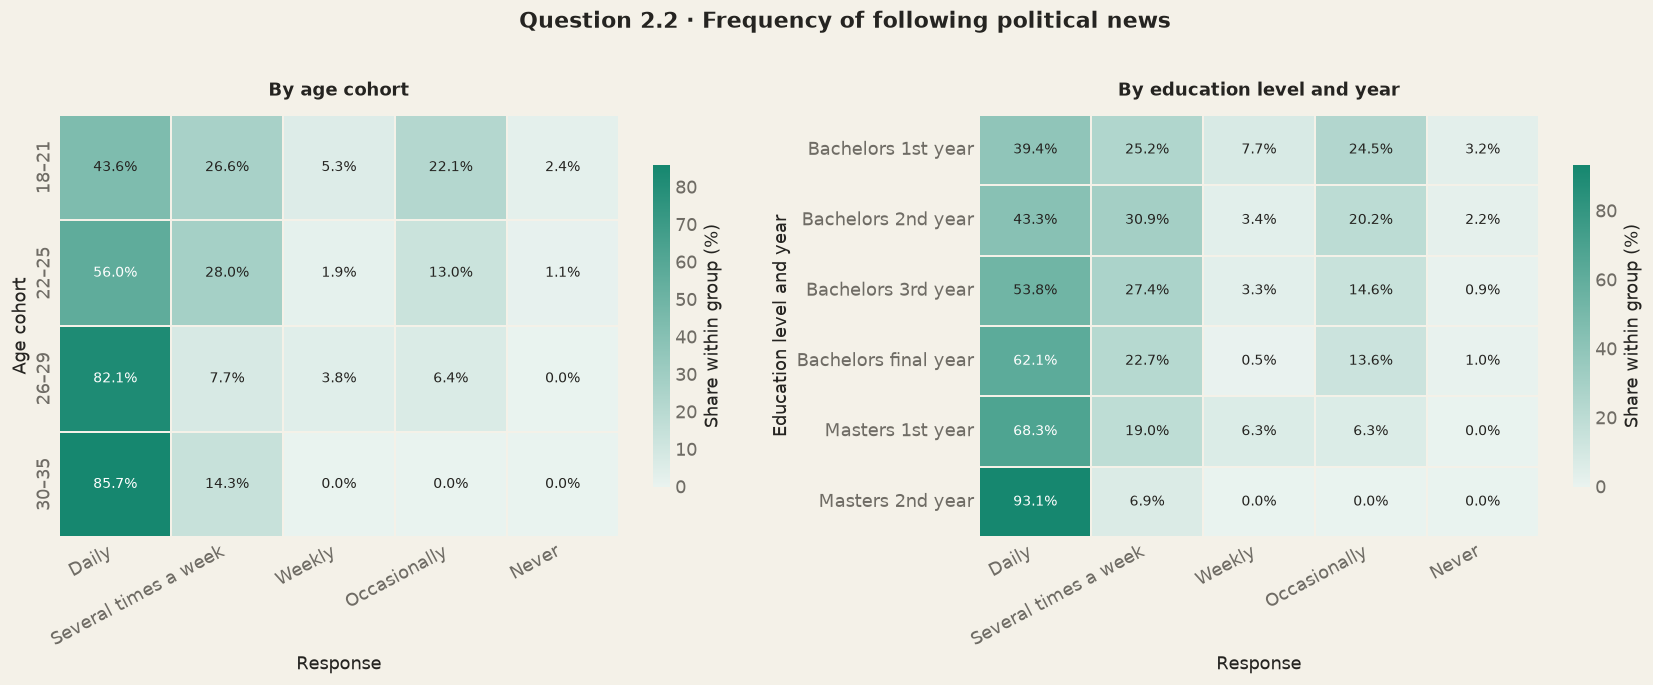

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14.8, 5.8))
fig.suptitle(
    "Question 2.2 · Frequency of following political news",
    fontsize=14,
    fontweight="bold",
    color=REPORT_INK,
    y=1.02,
)
draw_response_heatmap(
    axes[0], age_q2_2_pct, "By age cohort", "Age cohort", x_rotation=28
)
draw_response_heatmap(
    axes[1],
    education_q2_2_pct,
    "By education level and year",
    "Education level and year",
    x_rotation=28,
)
plt.tight_layout(pad=1.1, w_pad=2.0)
plt.show()

## 3. Political involvement and activity

This section first reports self-described active involvement (`q2_3`), then the six concrete activities undertaken during the previous 12 months (`q2_8_1`–`q2_8_6`). The involvement count measures breadth—the number of different activities reported—not frequency or intensity.


Valid N = 836; missing = 0


,Frequency,Percent,Cumulative percent
Category,,,
Yes,169,20.2,20.2
No,667,79.8,100.0


,"Yes, n","Yes, %",Valid N
Political activity in previous 12 months,,,
Attended campaign/rally,175,20.9,836
Volunteered for party/campaign,89,10.6,836
Joined protest/demonstration,246,29.4,836
Joined public meeting/discussion,265,31.7,836
Contacted elected representative,169,20.2,836
Joined ward user committee,37,4.4,836


,Value
Statistic,
Respondents,836
Mean,1.17
Median,1
Standard deviation,1.47


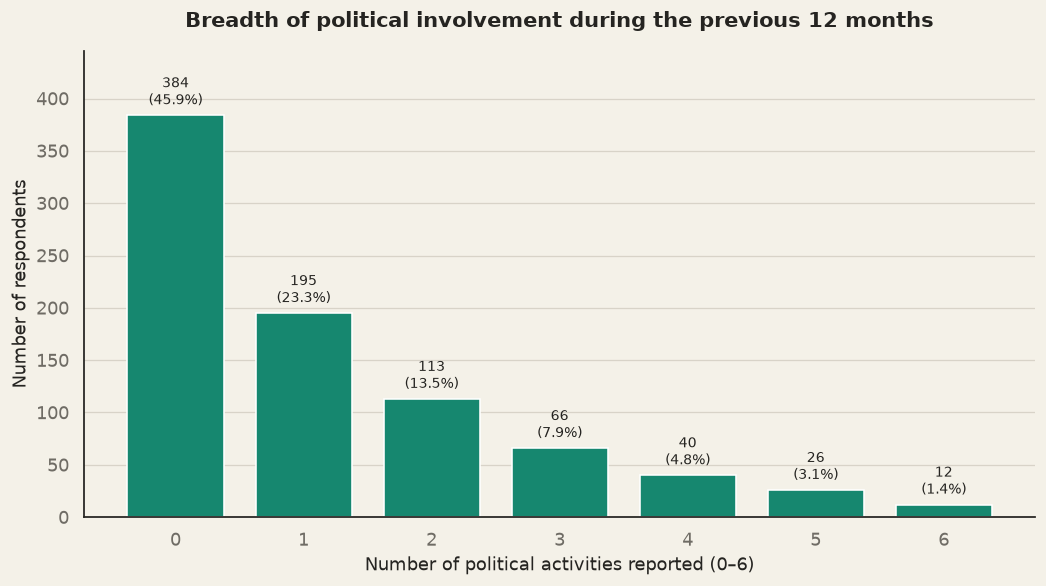

In [11]:
activity_labels = {
    "q2_8_1": "Attended campaign/rally",
    "q2_8_2": "Volunteered for party/campaign",
    "q2_8_3": "Joined protest/demonstration",
    "q2_8_4": "Joined public meeting/discussion",
    "q2_8_5": "Contacted elected representative",
    "q2_8_6": "Joined ward user committee",
}

display(HTML("<h4>Active involvement in politics or political organizations</h4>"))
display(stata_tabulate(df, "q2_3"))

activity_rows = []
for variable, label in activity_labels.items():
    responses = df[variable].astype("string").str.strip()
    valid = responses.isin(["Yes", "No"])
    yes_n = int(responses.eq("Yes").sum())
    valid_n = int(valid.sum())
    activity_rows.append({
        "Political activity in previous 12 months": label,
        "Yes, n": yes_n,
        "Yes, %": 100 * yes_n / valid_n,
        "Valid N": valid_n,
    })

activity_table = pd.DataFrame(activity_rows).set_index(
    "Political activity in previous 12 months"
)
display(activity_table.round({"Yes, %": 1}))

activity_items = df[list(activity_labels)].astype("string")
valid_activity_profile = activity_items.isin(["Yes", "No"]).all(axis=1)
political_involvement = (
    activity_items.eq("Yes").sum(axis=1).where(valid_activity_profile)
)
involvement_group_all = pd.cut(
    political_involvement,
    bins=[-0.5, 0.5, 1.5, 3.5, 6.5],
    labels=[
        "None", "One activity",
        "Two to three activities", "Four to six activities",
    ],
)

involvement_summary = pd.DataFrame({
    "Statistic": ["Respondents", "Mean", "Median", "Standard deviation"],
    "Value": [
        f"{political_involvement.notna().sum():,}",
        f"{political_involvement.mean():.2f}",
        f"{political_involvement.median():.0f}",
        f"{political_involvement.std():.2f}",
    ],
}).set_index("Statistic")
display(HTML("<h4>Political-involvement count</h4>"))
display(involvement_summary)

distribution = political_involvement.value_counts().reindex(range(7), fill_value=0)
fig, ax = plt.subplots(figsize=(9.2, 5.2))
bars = ax.bar(distribution.index, distribution.values, color=REPORT_TEAL, width=0.75)
ax.bar_label(
    bars,
    labels=[f"{value:,}\n({value / distribution.sum():.1%})" for value in distribution],
    padding=4,
    fontsize=8.5,
    color=REPORT_INK,
)
ax.set_xticks(range(7))
ax.set_xlabel("Number of political activities reported (0–6)")
ax.set_ylabel("Number of respondents")
ax.set_ylim(0, distribution.max() * 1.16)
report_title(ax, "Breadth of political involvement during the previous 12 months")
report_axes(ax, grid_axis="y")
plt.tight_layout()
plt.show()


## 4. Factors associated with viewing politics as central

The ordered-probit models use the five-category version of Question 2.1, coded from stronger disagreement to stronger agreement. They test whether frequent political-news consumption, self-reported active political involvement, and breadth of political activity are associated with stronger agreement after adjustment for background and demographic characteristics.

Political efficacy (`q2_9`) is intentionally not included. The direction between efficacy and political salience is ambiguous in cross-sectional data, so efficacy is presented separately after the model.

Models 1–3 enter the focal predictors separately; Model 4 includes all three; Model 5 replaces the linear activity count with grouped involvement levels. All models use a common complete-case sample and HC1 heteroskedasticity-robust standard errors.


In [12]:
from scipy.stats import norm
from statsmodels.miscmodels.ordinal_model import OrderedModel


# Construct the same analysis variables used in the Stata file.
model_data = pd.DataFrame(index=df.index)
model_data["politics5"] = df["q2_1"].astype("string").map({
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5,
})
model_data["politics3"] = df["q2_1"].astype("string").map({
    "Strongly Disagree": 1,
    "Disagree": 1,
    "Neutral": 2,
    "Agree": 3,
    "Strongly Agree": 3,
})
model_data["rural"] = df["life_place"].astype("string").map({
    "Urban": 0, "Rural": 1
})
model_data["female"] = df["gender"].astype("string").map({
    "Male": 0, "Female": 1
})
model_data["family_abroad"] = df["family_abroad"].astype("string").map({
    "No": 0, "Yes": 1
})
model_data["news_frequent"] = df["q2_2"].astype("string").map({
    "Daily": 1,
    "Several times a week": 1,
    "Weekly": 0,
    "Occasionally": 0,
    "Never": 0,
})
model_data["active_politics"] = df["q2_3"].astype("string").map({
    "No": 0,
    "Yes": 1,
})

involvement_items = df[[f"q2_8_{item}" for item in range(1, 7)]].astype("string")
valid_involvement = involvement_items.isin(["Yes", "No"]).all(axis=1)
model_data["political_involvement"] = (
    involvement_items.eq("Yes").sum(axis=1).where(valid_involvement)
)
model_data["involvement_group"] = pd.cut(
    model_data["political_involvement"],
    bins=[-0.5, 0.5, 1.5, 3.5, 6.5],
    labels=[
        "None", "One activity",
        "Two to three activities", "Four to six activities",
    ],
)

school = df["edu_school"].astype("string")
plus2 = df["edu_plus2"].astype("string")
model_data["school_path"] = pd.NA
model_data.loc[
    school.eq("Public") & plus2.eq("Public"), "school_path"
] = "Public at both stages"
model_data.loc[
    school.ne(plus2) & school.notna() & plus2.notna(), "school_path"
] = "Mixed public/private"
model_data.loc[
    school.eq("Private") & plus2.eq("Private"), "school_path"
] = "Private at both stages"

education = df["education"].astype("string")
model_data["education_stage"] = pd.NA
model_data.loc[
    education.isin(["Bachelors 1st year", "Bachelors 2nd year"]),
    "education_stage",
] = "Bachelors years 1-2"
model_data.loc[
    education.isin([
        "Bachelors 3rd year", "Bachelors 4th year", "Bachelors 5th year"
    ]),
    "education_stage",
] = "Bachelors years 3-5"
model_data.loc[
    education.isin(["Masters 1st year", "Masters 2nd year", "PHD"]),
    "education_stage",
] = "Masters or PhD"

religion = df["religion"].astype("string")
belief = df["religious_belief"].astype("string")
model_data["religion3"] = pd.NA
model_data.loc[religion.eq("Hindu"), "religion3"] = "Hindu"
model_data.loc[
    religion.isin(["Muslim", "Christian", "Others", "Buddhist"]),
    "religion3",
] = "Other religion"
model_data.loc[
    belief.isin(["No", "Not Sure"]), "religion3"
] = "No or uncertain religious belief"

model_data["age"] = df["age"]
model_data["ethnicity"] = df["ethnicity"].astype("string")
model_data["province"] = df["Province"].astype("string")
required_variables = [
    "politics5", "news_frequent", "active_politics",
    "political_involvement", "involvement_group",
    "rural", "school_path", "family_abroad", "female",
    "age", "education_stage", "ethnicity", "religion3",
    "province",
]
estimation_data = model_data.dropna(subset=required_variables).copy()


def reference_dummies(series, categories, reference, prefix):
    categorical = pd.Categorical(series, categories=categories)
    result = pd.get_dummies(categorical, prefix=prefix, dtype=float)
    result.index = series.index
    return result.drop(columns=[f"{prefix}_{reference}"])


controls = pd.concat([
    estimation_data[["female", "age"]].astype(float),
    reference_dummies(
        estimation_data["education_stage"],
        ["Bachelors years 1-2", "Bachelors years 3-5", "Masters or PhD"],
        "Bachelors years 1-2",
        "education",
    ),
    reference_dummies(
        estimation_data["ethnicity"],
        ["Bhramin/Chettri", "Dalit", "Janajati", "Muslim", "Madhesi"],
        "Bhramin/Chettri",
        "ethnicity",
    ),
    reference_dummies(
        estimation_data["religion3"],
        ["Hindu", "Other religion", "No or uncertain religious belief"],
        "Hindu",
        "religion",
    ),
    reference_dummies(
        estimation_data["province"],
        [
            "bagamati", "gandaki", "karnali", "koshi",
            "lumbini", "madhesh", "sudurpaschim",
        ],
        "bagamati",
        "province",
    ),
], axis=1)

school_path_dummies = reference_dummies(
    estimation_data["school_path"],
    ["Public at both stages", "Mixed public/private", "Private at both stages"],
    "Public at both stages",
    "school",
)
background_controls = pd.concat([
    estimation_data[["rural", "family_abroad"]].astype(float),
    school_path_dummies,
    controls,
], axis=1)
focal_variables = estimation_data[[
    "news_frequent", "active_politics", "political_involvement",
]].astype(float)
involvement_group_dummies = reference_dummies(
    estimation_data["involvement_group"],
    [
        "None", "One activity",
        "Two to three activities", "Four to six activities",
    ],
    "None",
    "involvement",
)

model_matrices = {
    "(1) News": pd.concat([
        focal_variables[["news_frequent"]], background_controls,
    ], axis=1),
    "(2) Active politics": pd.concat([
        focal_variables[["active_politics"]], background_controls,
    ], axis=1),
    "(3) Involvement count": pd.concat([
        focal_variables[["political_involvement"]], background_controls,
    ], axis=1),
    "(4) Joint": pd.concat([
        focal_variables, background_controls,
    ], axis=1),
    "(5) Grouped involvement": pd.concat([
        focal_variables[["news_frequent", "active_politics"]],
        involvement_group_dummies, background_controls,
    ], axis=1),
}

ordered_results = {}
robust_inference = {}
for model_name, design_matrix in model_matrices.items():
    ordered_model = OrderedModel(
        estimation_data["politics5"].astype(int),
        design_matrix,
        distr="probit",
    )
    result = ordered_model.fit(method="bfgs", disp=False, maxiter=1000)
    ordered_results[model_name] = result

    # Observation-level HC1 heteroskedasticity-robust sandwich covariance.
    scores = ordered_model.score_obs(result.params)
    bread = np.linalg.pinv(-ordered_model.hessian(result.params))
    meat = scores.T @ scores
    observations, parameters = scores.shape
    correction = observations / (observations - parameters)
    covariance = bread @ meat @ bread * correction
    standard_errors = pd.Series(
        np.sqrt(np.diag(covariance)), index=result.params.index
    )
    p_values = pd.Series(
        2 * norm.sf(np.abs(result.params / standard_errors)),
        index=result.params.index,
    )
    robust_inference[model_name] = {
        "standard_errors": standard_errors,
        "p_values": p_values,
    }

model_check = pd.DataFrame({
    "Observations": [len(estimation_data)],
    "Standard errors": ["HC1 robust"],
    "All models converged": [all(
        result.mle_retvals.get("converged", False)
        for result in ordered_results.values()
    )],
})
display(model_check)

,Observations,Standard errors,All models converged
0,816,HC1 robust,True


### Ordered-probit results


In [13]:
model_columns = list(ordered_results)
focal_terms = [
    ("news_frequent", "Frequently follows political news"),
    ("active_politics", "Actively involved in politics/organizations"),
    ("political_involvement", "Political involvement count, 0-6"),
    ("involvement_One activity", "One activity"),
    ("involvement_Two to three activities", "Two to three activities"),
    ("involvement_Four to six activities", "Four to six activities"),
]


def significance_stars(p_value):
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


report_rows = {}
for parameter, label in focal_terms:
    cells = []
    for model_name in model_columns:
        result = ordered_results[model_name]
        if parameter in result.params.index:
            coefficient = result.params[parameter]
            standard_error = robust_inference[model_name][
                "standard_errors"
            ][parameter]
            p_value = robust_inference[model_name]["p_values"][parameter]
            stars = significance_stars(p_value)
            cells.append(f"{coefficient:.3f}{stars}\n({standard_error:.3f})")
        else:
            cells.append("--")
    report_rows[label] = cells

report_rows["Background and demographic controls"] = ["Yes"] * len(model_columns)
report_rows["Outcome categories"] = ["5"] * len(model_columns)
report_rows["Observations"] = [f"{len(estimation_data):,}"] * len(model_columns)
report_rows["Standard errors"] = ["HC1 robust"] * len(model_columns)
report_rows["Log likelihood"] = [
    f"{ordered_results[name].llf:.1f}" for name in model_columns
]
report_rows["AIC"] = [
    f"{ordered_results[name].aic:.1f}" for name in model_columns
]

ordered_probit_table = pd.DataFrame.from_dict(
    report_rows,
    orient="index",
    columns=model_columns,
)
ordered_probit_table.index.name = "Predictor / model statistic"

header_html = "".join(
    f"<th>{column}</th>" for column in ordered_probit_table.columns
)
body_rows = []
for row_label, row in ordered_probit_table.iterrows():
    value_cells = "".join(
        f"<td>{'<br>'.join(str(value).splitlines())}</td>"
        for value in row
    )
    body_rows.append(f"<tr><th>{row_label}</th>{value_cells}</tr>")
body_html = "".join(body_rows)

table_html = (
    '<div id="ordered-probit-report" style="overflow-x:auto; margin:8px 0 14px 0;">'
    '<table style="border-collapse:collapse; min-width:900px; '
    'font-family:DejaVu Sans, sans-serif; font-size:12px;">'
    '<caption style="caption-side:top; text-align:left; font-size:15px; '
    'font-weight:700; color:#252421; padding:0 0 10px 0;">'
    'Ordered-probit models of agreement that politics is central to living in Nepal'
    '</caption>'
    '<thead><tr><th style="text-align:left;">Predictor / model statistic</th>'
    f'{header_html}</tr></thead>'
    f'<tbody>{body_html}</tbody></table>'
    '<style>'
    '#ordered-probit-report thead th {background:#16876F; color:white; font-weight:600; '
    'padding:7px 8px; border:1px solid #F4F1E8; text-align:center;}'
    '#ordered-probit-report tbody th {background:#F4F1E8; color:#252421; text-align:left; '
    'padding:7px 8px; border-bottom:1px solid #D8D3C8;}'
    '#ordered-probit-report tbody td {background:#F4F1E8; color:#252421; text-align:center; '
    'padding:7px 8px; border-bottom:1px solid #D8D3C8;}'
    '</style></div>'
)
display(HTML(table_html))

Predictor / model statistic,(1) News,(2) Active politics,(3) Involvement count,(4) Joint,(5) Grouped involvement
Frequently follows political news,0.242**(0.098),--,--,0.201**(0.099),0.196**(0.099)
Actively involved in politics/organizations,--,0.416***(0.109),--,0.419***(0.121),0.400***(0.118)
"Political involvement count, 0-6",--,--,0.050(0.031),-0.015(0.034),--
One activity,--,--,--,--,0.061(0.096)
Two to three activities,--,--,--,--,0.010(0.111)
Four to six activities,--,--,--,--,-0.015(0.171)
Background and demographic controls,Yes,Yes,Yes,Yes,Yes
Outcome categories,5,5,5,5,5
Observations,816,816,816,816,816
Standard errors,HC1 robust,HC1 robust,HC1 robust,HC1 robust,HC1 robust


### Interpretation

The primary analysis uses **816 respondents** with complete data on the outcome, focal predictors, and controls. In Model 1, frequent political-news consumption is positively associated with stronger agreement that politics is central (**0.242**, HC1 robust SE **0.098**, **p < 0.05**). This means that frequent news followers have a higher underlying tendency to agree than respondents who follow political news weekly, occasionally, or never, conditional on the controls.

Model 2 shows an even stronger relationship. Respondents who report active involvement in politics or political organizations have a substantially greater tendency to agree that politics is central (**0.416**, HC1 robust SE **0.109**, **p < 0.01**). In Model 3, each additional activity in the six-item involvement count has a small positive coefficient (**0.050**, HC1 robust SE **0.031**), but it does not reach conventional significance thresholds.

Model 4 includes all three focal predictors simultaneously. Frequent news consumption remains positive and statistically significant (**0.201**, HC1 robust SE **0.099**, **p < 0.05**), and active political involvement also remains positive and strongly significant (**0.419**, HC1 robust SE **0.121**, **p < 0.01**). The involvement-count coefficient becomes slightly negative and remains statistically inconclusive (**−0.015**, HC1 robust SE **0.034**). News consumption and self-reported active involvement therefore have distinct adjusted associations with the outcome, while the number of reported activities adds little once those two measures are included.

Model 5 provides no evidence that grouping the activity count reveals a hidden nonlinear relationship. Relative to no reported activities, the coefficients for one activity (**0.061**), two to three activities (**0.010**), and four to six activities (**−0.015**) are all statistically inconclusive. News consumption remains significant (**0.196**, HC1 robust SE **0.099**, **p < 0.05**), as does active political involvement (**0.400**, HC1 robust SE **0.118**, **p < 0.01**).

Ordered-probit coefficients describe movement in an unobserved tendency toward stronger agreement; they are not percentage-point changes. The findings remain associational rather than causal. In addition, `q2_3` is conceptually close to an outcome that explicitly refers to political involvement, so its strong coefficient may partly reflect consistency in how respondents describe their political orientation rather than an effect of involvement on the belief. The 712-person municipality–ward clustered specification can still be reported separately as a sensitivity analysis because it produces wider standard errors.

## 5. Political efficacy

Question 2.9 asks how confident respondents are that they can influence government decisions. It is presented after the ordered-probit analysis because it is not a predictor in that model. Conceptually, efficacy connects political engagement to formal electoral participation.


Valid N = 836; missing = 0


,Frequency,Percent,Cumulative percent
Category,,,
Very Confident,329,39.4,39.4
Confident,354,42.3,81.7
Neutral,112,13.4,95.1
Not Confident,34,4.1,99.2
Not at all confident,7,0.8,100.0


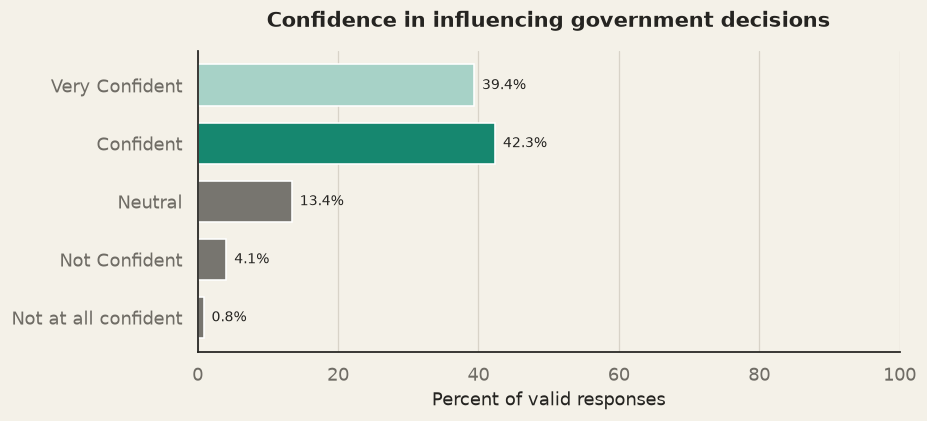

Response: n (row %),Very Confident,Confident,Neutral,Not Confident,Not at all confident,Total n
Political-involvement breadth,,,,,,
None,119 (31.0%),175 (45.6%),65 (16.9%),21 (5.5%),4 (1.0%),384
One activity,66 (33.8%),89 (45.6%),31 (15.9%),7 (3.6%),2 (1.0%),195
Two to three activities,89 (49.7%),70 (39.1%),14 (7.8%),5 (2.8%),1 (0.6%),179
Four to six activities,55 (70.5%),20 (25.6%),2 (2.6%),1 (1.3%),0 (0.0%),78


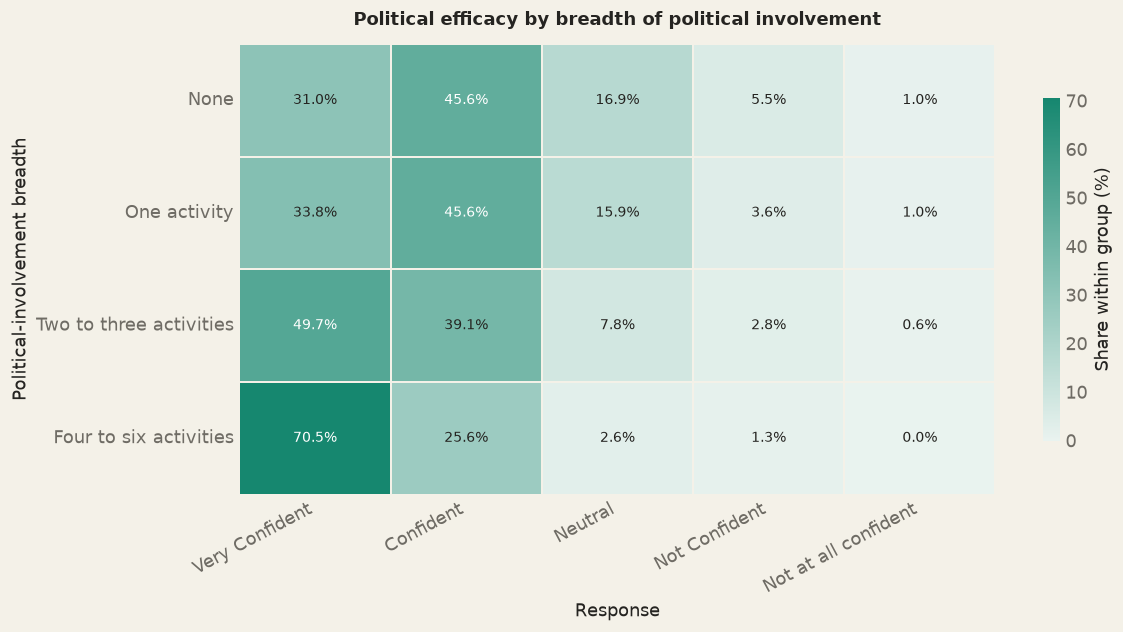

In [14]:
display(stata_tabulate(df, "q2_9"))
plot_frequency_bar(
    df,
    "q2_9",
    "Confidence in influencing government decisions",
)

efficacy_order = [
    "Very Confident", "Confident", "Neutral",
    "Not Confident", "Not at all confident",
]
efficacy_text = df["q2_9"].astype("string").str.strip()
involvement_order = list(involvement_group_all.cat.categories)
_, efficacy_pct, efficacy_table = grouped_response_summary(
    involvement_group_all,
    efficacy_text,
    involvement_order,
    efficacy_order,
    "Political-involvement breadth",
)
display(HTML("<h4>Political efficacy by breadth of involvement</h4>"))
display(efficacy_table)

fig, ax = plt.subplots(figsize=(10.5, 5.6))
draw_response_heatmap(
    ax,
    efficacy_pct,
    "Political efficacy by breadth of political involvement",
    "Political-involvement breadth",
    x_rotation=28,
)
plt.tight_layout()
plt.show()


## 6. Past electoral participation

Federal- and local-election questions were administered only to respondents aged 22 or older. The denominator therefore represents survey-defined eligibility, not verified voter registration. Response code 3 is displayed according to the questionnaire wording as “Voted, level unknown,” rather than “Not sure.”


,Voted,Did not vote,"Voted, level unknown",Survey-defined eligible N,Self-reported turnout (%)
Election,,,,,
Federal,228,224,8,460,49.6%
Local,222,228,10,460,48.3%


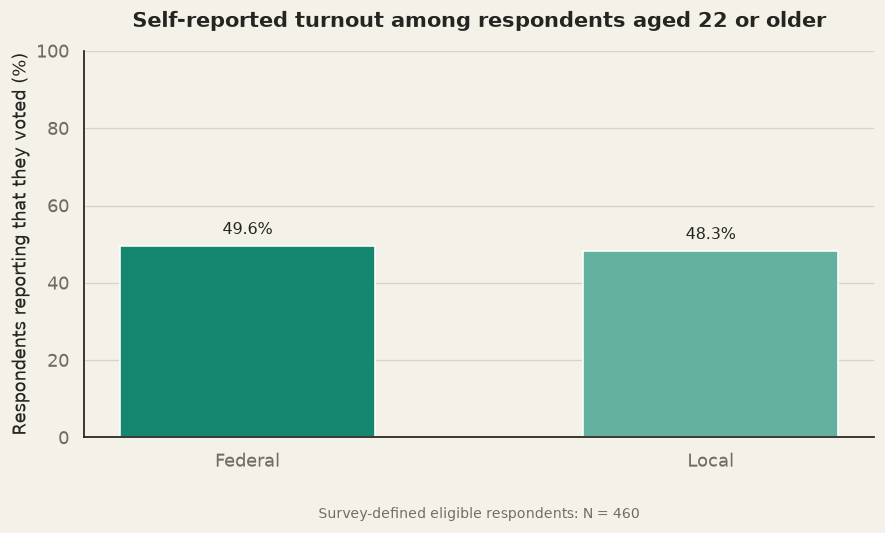

In [15]:
age_numeric = pd.to_numeric(df["age"], errors="coerce")
eligible_voters = df.loc[age_numeric.ge(22)].copy()
eligible_n = len(eligible_voters)

election_variables = {
    "Federal": "q2_4",
    "Local": "q2_6",
}
turnout_rows = []
for election, variable in election_variables.items():
    responses = (
        eligible_voters[variable].astype("string").str.strip()
        .replace({"Not Sure": "Voted, level unknown"})
    )
    counts = responses.value_counts()
    voted = int(counts.get("Yes", 0))
    did_not_vote = int(counts.get("No", 0))
    level_unknown = int(counts.get("Voted, level unknown", 0))
    turnout_rows.append({
        "Election": election,
        "Voted": voted,
        "Did not vote": did_not_vote,
        "Voted, level unknown": level_unknown,
        "Survey-defined eligible N": eligible_n,
        "Self-reported turnout (%)": 100 * voted / eligible_n,
    })

turnout_table = pd.DataFrame(turnout_rows).set_index("Election")
turnout_display = turnout_table.copy()
turnout_display["Self-reported turnout (%)"] = (
    turnout_display["Self-reported turnout (%)"].map(lambda value: f"{value:.1f}%")
)
display(turnout_display)

fig, ax = plt.subplots(figsize=(7.8, 4.8))
turnout_percentages = turnout_table["Self-reported turnout (%)"]
bars = ax.bar(
    turnout_percentages.index, turnout_percentages.values,
    color=[REPORT_TEAL, REPORT_TEAL_MID], width=0.55,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in turnout_percentages],
    padding=5,
    fontsize=10,
    color=REPORT_INK,
)
ax.set_ylabel("Respondents reporting that they voted (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)
report_title(ax, "Self-reported turnout among respondents aged 22 or older")
report_axes(ax, grid_axis="y")
ax.text(
    0.5, -0.18, f"Survey-defined eligible respondents: N = {eligible_n:,}",
    transform=ax.transAxes, ha="center", va="top",
    fontsize=9, color=REPORT_MUTED,
)
plt.tight_layout()
plt.show()


### Reasons for not voting

Each reason is reported as a percentage of respondents who said they did not vote in the corresponding election. The open-ended Other category is omitted from the chart but remains in the denominator.


,Federal,Local
Reason,,
Did not register,71.9%,70.2%
Away from registered voting location,13.8%,15.8%
Health/family issue,2.2%,2.6%
Not interested in voting process,2.7%,2.6%
Did not trust political parties/candidates,3.1%,2.2%
Intentionally boycotted the election,1.8%,1.3%
My vote would make no difference,1.8%,1.8%


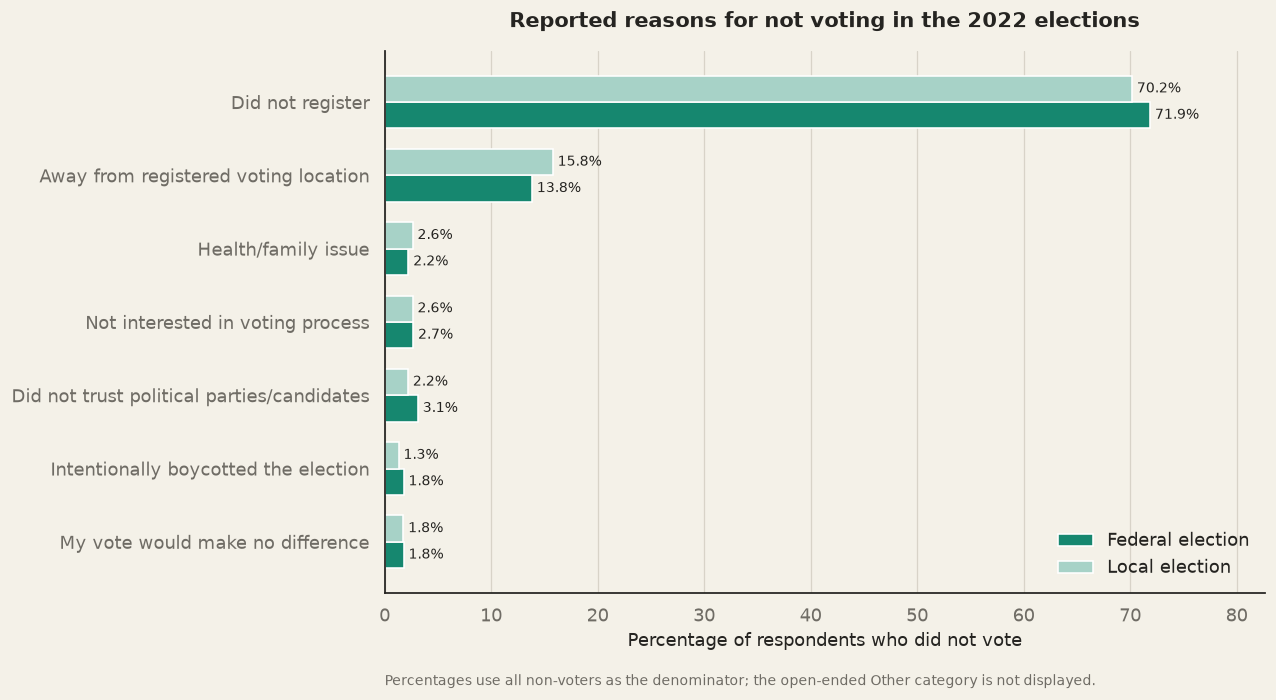

In [16]:
reason_code_labels = {
    "1": "Did not register",
    "3": "Away from registered voting location",
    "4": "Health/family issue",
    "5": "Not interested in voting process",
    "6": "Did not trust political parties/candidates",
    "7": "Intentionally boycotted the election",
    "8": "My vote would make no difference",
    "-99": "Prefer not to say",
    "96": "Other reason specified",
    "others_please_specify": "Other reason specified",
}
reported_reasons = [
    "Did not register",
    "Away from registered voting location",
    "Health/family issue",
    "Not interested in voting process",
    "Did not trust political parties/candidates",
    "Intentionally boycotted the election",
    "My vote would make no difference",
]

reason_rows = []
reason_variables = {
    "Federal": ("q2_4", "q2_4_1"),
    "Local": ("q2_6", "q2_6_1"),
}
for election, (vote_variable, reason_variable) in reason_variables.items():
    nonvoter_mask = (
        age_numeric.ge(22)
        & df[vote_variable].astype("string").str.strip().eq("No")
    )
    nonvoter_n = int(nonvoter_mask.sum())
    reasons = (
        df.loc[nonvoter_mask, reason_variable]
        .astype("string").str.strip()
        .replace(reason_code_labels)
    )
    counts = reasons.value_counts()
    for reason in reported_reasons:
        count = int(counts.get(reason, 0))
        reason_rows.append({
            "Reason": reason,
            "Election": election,
            "Count": count,
            "Percent of non-voters": 100 * count / nonvoter_n,
            "Non-voter N": nonvoter_n,
        })

nonvoting_reasons = pd.DataFrame(reason_rows)
reason_percentage_table = (
    nonvoting_reasons.pivot(
        index="Reason", columns="Election", values="Percent of non-voters"
    )
    .reindex(reported_reasons)
    .rename_axis(None, axis=1)
)
display(reason_percentage_table.map(lambda value: f"{value:.1f}%"))

plot_reasons = list(reversed(reported_reasons))
plot_table = reason_percentage_table.reindex(plot_reasons)
y_positions = np.arange(len(plot_reasons))
bar_height = 0.36
fig, ax = plt.subplots(figsize=(11.2, 6.2))
federal_bars = ax.barh(
    y_positions - bar_height / 2, plot_table["Federal"],
    height=bar_height, color=REPORT_TEAL, label="Federal election",
)
local_bars = ax.barh(
    y_positions + bar_height / 2, plot_table["Local"],
    height=bar_height, color=REPORT_TEAL_LIGHT, label="Local election",
)
for bars in (federal_bars, local_bars):
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8.5, color=REPORT_INK)
ax.set_yticks(y_positions, plot_reasons)
ax.set_xlabel("Percentage of respondents who did not vote")
ax.set_ylabel("")
ax.set_xlim(0, max(80, float(plot_table.max().max()) * 1.15))
report_title(ax, "Reported reasons for not voting in the 2022 elections")
report_axes(ax, grid_axis="x")
ax.legend(frameon=False, loc="lower right")
ax.text(
    0.0, -0.15,
    "Percentages use all non-voters as the denominator; the open-ended Other category is not displayed.",
    transform=ax.transAxes, ha="left", va="top", fontsize=8.8, color=REPORT_MUTED,
)
plt.tight_layout()
plt.show()

Failure to register was by far the most frequently reported reason for non-participation: **71.9%** of federal non-voters and **70.2%** of local non-voters selected this response. Being away from the registered voting location was the second-most-common reason, reported by **13.8%** of federal non-voters and **15.8%** of local non-voters. Distrust, lack of interest, intentional boycotting, health or family issues, and the belief that one vote would make no difference were each reported by relatively small shares. Within this student sample, non-participation therefore appears to be associated more strongly with registration and location barriers than with explicit rejection of elections.

### Consistency across the federal and local elections

The following cross-tabulation examines whether the same respondents participated in both elections. Respondents answering `Not sure` to either election question are excluded, leaving **449 respondents with substantive Yes/No answers to both questions**. Internal cells show counts followed by row percentages; the final row and column report the margins.

### Consistency across federal and local elections

The table compares the same respondents’ reported participation across the two elections. Internal cells show counts and row percentages.


,Yes,No,Row total
Federal-election response,,,
Yes,213 (94.2%),13 (5.8%),226
No,8 (3.6%),215 (96.4%),223
Column total,221,228,449


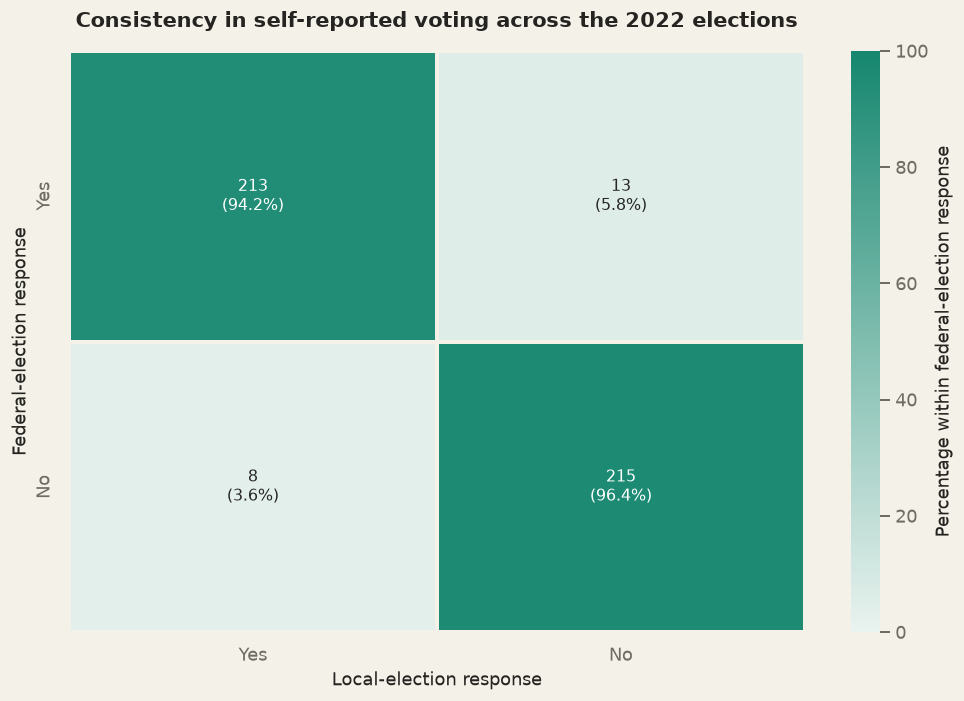

In [17]:
vote_order = ["Yes", "No"]
federal_response = eligible_voters["q2_4"].astype("string").str.strip().replace({"Not Sure": "Voted, level unknown"})
local_response = eligible_voters["q2_6"].astype("string").str.strip().replace({"Not Sure": "Voted, level unknown"})
vote_crosstab = (
    pd.crosstab(federal_response, local_response)
    .reindex(index=vote_order, columns=vote_order, fill_value=0)
)
vote_crosstab.index.name = "Federal-election response"
vote_crosstab.columns.name = "Local-election response"
row_percentages = vote_crosstab.div(vote_crosstab.sum(axis=1), axis=0) * 100

crosstab_display = pd.DataFrame(index=vote_order, columns=vote_order, dtype=object)
for row in vote_order:
    for column in vote_order:
        crosstab_display.loc[row, column] = (
            f"{vote_crosstab.loc[row, column]:,} "
            f"({row_percentages.loc[row, column]:.1f}%)"
        )
crosstab_display["Row total"] = vote_crosstab.sum(axis=1).map(lambda value: f"{value:,}")
column_total = vote_crosstab.sum(axis=0).map(lambda value: f"{value:,}")
column_total["Row total"] = f"{vote_crosstab.to_numpy().sum():,}"
crosstab_display.loc["Column total"] = column_total
crosstab_display.index.name = "Federal-election response"
display(crosstab_display)

heatmap_annotations = vote_crosstab.copy().astype(str)
for row in vote_order:
    for column in vote_order:
        heatmap_annotations.loc[row, column] = (
            f"{vote_crosstab.loc[row, column]:,}\n"
            f"({row_percentages.loc[row, column]:.1f}%)"
        )
fig, ax = plt.subplots(figsize=(8.8, 6.2))
sns.heatmap(
    row_percentages, annot=heatmap_annotations, fmt="",
    cmap=REPORT_CMAP, vmin=0, vmax=100, linewidths=1.5, linecolor=REPORT_BG,
    cbar_kws={"label": "Percentage within federal-election response"}, ax=ax,
)
ax.set_xlabel("Local-election response")
ax.set_ylabel("Federal-election response")
report_title(ax, "Consistency in self-reported voting across the 2022 elections")
plt.tight_layout()
plt.show()


Reported participation was highly consistent across the two elections. Among respondents who gave substantive answers to both questions, **94.2%** of federal-election voters also reported voting locally, while **96.4%** of federal non-voters also reported not voting locally. Overall, **428 of 449 respondents (95.3%)** reported consistent behaviour across the two elections.

The result suggests that electoral participation was not independently determined for each election for most respondents. Instead, the sample contains two relatively stable groups: respondents who participated in both elections and respondents who participated in neither. These remain self-reported records and should not be interpreted as independently verified voting histories.

## Theme 1 conclusion and transition

Theme 1 moves from political salience and information to involvement, efficacy, and past electoral behaviour. Theme 2 can now ask whether these orientations carry forward into future voting and how they relate to perceptions of political stability and the Gen-Z protest.

The principal bridge variables for Theme 2 are political-news consumption, political involvement, political efficacy, and past voting. Their relationships with future voting should be reported in Theme 2, where future voting is the outcome.


# Theme 2 · Political instability, the Gen-Z movement, and Nepal’s political future

Theme 2 begins with respondents’ assessment of Nepal’s political situation at the time of the survey. The Gen-Z movement and later components will be added after each component is reviewed and approved.


## Bridge analysis · Past voting and future electoral intention

Theme 1 documented respondents’ participation in the 2022 elections. This bridge asks whether that past participation carries forward into stated intention to vote in the 2027 local election. “Very likely” and “somewhat likely” are grouped as **Likely**, while “somewhat unlikely” and “very unlikely” are grouped as **Unlikely**. “Do not know” responses are excluded from these row percentages.

Federal and local voting are shown because they have comparable routed denominators. Provincial voting is not used in this comparison because that question was recorded for a much narrower subset of respondents.

Outcome: n (row %),Likely,Unlikely,Total n
Voted in 2022 federal election,,,
Yes,221 (98.2%),4 (1.8%),225
No,173 (83.2%),35 (16.8%),208


Outcome: n (row %),Likely,Unlikely,Total n
Voted in 2022 local election,,,
Yes,215 (98.2%),4 (1.8%),219
No,178 (83.6%),35 (16.4%),213


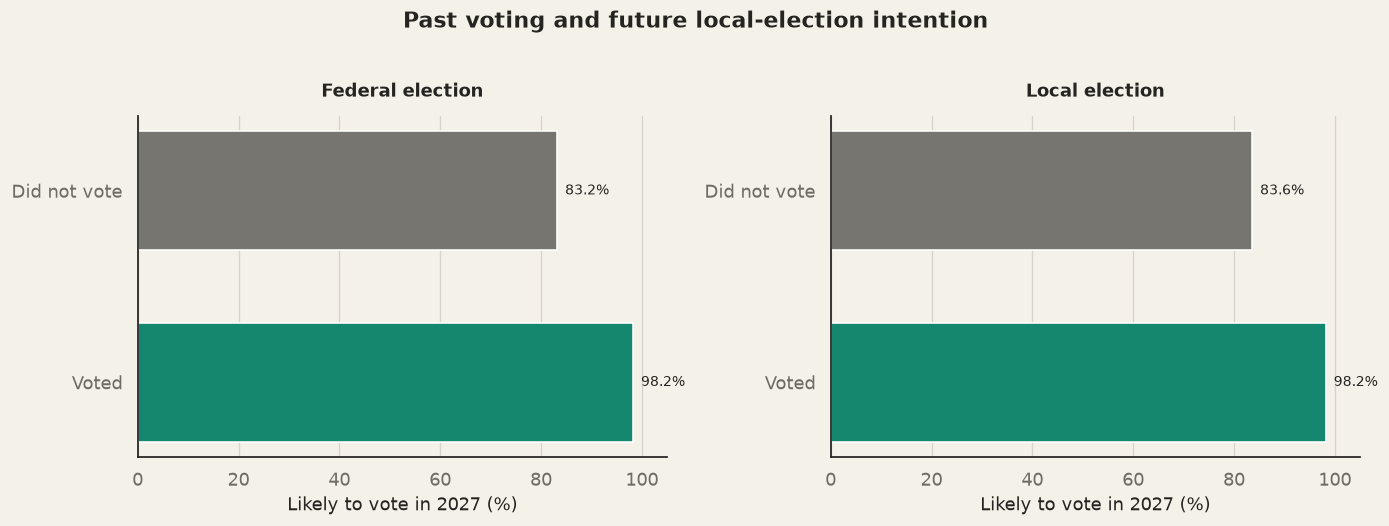

In [18]:
def bridge_crosstab(row, column, row_order, column_order, row_name):
    # Return counts, row percentages, a display table, and association statistics.
    analysis = pd.DataFrame({"row": row, "column": column}).dropna()
    counts = (
        pd.crosstab(analysis["row"], analysis["column"])
        .reindex(index=row_order, columns=column_order, fill_value=0)
    )
    percentages = counts.div(counts.sum(axis=1), axis=0).mul(100)
    table = counts.astype(int).astype(str) + " (" + percentages.map(
        lambda value: f"{value:.1f}%"
    ) + ")"
    table["Total n"] = counts.sum(axis=1).astype(int)
    table.index.name = row_name
    table.columns.name = "Outcome: n (row %)"

    chi2, p_value, _, _ = chi2_contingency(counts)
    n = int(counts.to_numpy().sum())
    cramer_v = np.sqrt(
        chi2 / (n * min(counts.shape[0] - 1, counts.shape[1] - 1))
    )
    statistics = {"n": n, "chi2": chi2, "p": p_value, "v": cramer_v}
    return counts, percentages, table, statistics


future_vote = df["q2_7"].astype("string").str.strip().map({
    "Very Likely": "Likely",
    "Somewhat Likely": "Likely",
    "Somewhat Unlikely": "Unlikely",
    "Very Unlikely": "Unlikely",
})
future_order = ["Likely", "Unlikely"]
past_vote_order = ["Yes", "No"]

future_vote_results = {}
for election, variable in {
    "Federal election": "q2_4",
    "Local election": "q2_6",
}.items():
    past_vote = df[variable].astype("string").str.strip()
    past_vote = past_vote.where(past_vote.isin(past_vote_order))
    result = bridge_crosstab(
        past_vote,
        future_vote,
        past_vote_order,
        future_order,
        f"Voted in 2022 {election.lower()}",
    )
    future_vote_results[election] = result
    display(HTML(f"<h4>{election}</h4>"))
    display(result[2])

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4), sharex=True)
for ax, (election, (_, percentages, _, _)) in zip(
    axes, future_vote_results.items()
):
    likely = percentages["Likely"]
    bars = ax.barh(
        ["Voted", "Did not vote"],
        likely.values,
        color=[REPORT_TEAL, REPORT_GREY],
        height=0.62,
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.1f}%" for value in likely.values],
        padding=5,
        fontsize=9,
        color=REPORT_INK,
    )
    ax.set_title(election, fontsize=11.5, fontweight="bold", pad=12)
    ax.set_xlabel("Likely to vote in 2027 (%)")
    ax.set_xlim(0, 105)
    ax.set_ylabel("")
    report_axes(ax, grid_axis="x")

fig.suptitle(
    "Past voting and future local-election intention",
    fontsize=14,
    fontweight="bold",
    color=REPORT_INK,
    y=1.03,
)
plt.tight_layout()
plt.show()

federal_pct = future_vote_results["Federal election"][1]["Likely"]
local_pct = future_vote_results["Local election"][1]["Likely"]
federal_stats = future_vote_results["Federal election"][3]
local_stats = future_vote_results["Local election"][3]

display(HTML(
    "<p>Future voting intention is strongly patterned by past voting. Among "
    "respondents with substantive answers, "
    f"<strong>{federal_pct['Yes']:.1f}%</strong> of past federal voters were "
    f"likely to vote in 2027, compared with <strong>{federal_pct['No']:.1f}%</strong> "
    "of federal non-voters. The corresponding local-election percentages were "
    f"<strong>{local_pct['Yes']:.1f}%</strong> and "
    f"<strong>{local_pct['No']:.1f}%</strong>. The associations are moderate "
    f"(Cramér’s V = {federal_stats['v']:.2f} for federal voting and "
    f"{local_stats['v']:.2f} for local voting; both p &lt; 0.001). Past voting "
    "therefore distinguishes degrees of future intention even though likely voting "
    "is common in both groups. These are descriptive associations based on "
    "self-reported behaviour and intention.</p>"
))

## 1. Nepal’s political situation at the time of the survey

This component establishes how students assessed Nepal’s current political stability and how they compared the present with one and five years earlier.


### 1.1 Political stability today


,Frequency,Percent
Assessment,,
Very Unstable,26,3.1
Unstable,119,14.4
Neutral,184,22.3
Stable,454,55.0
Very Stable,43,5.2


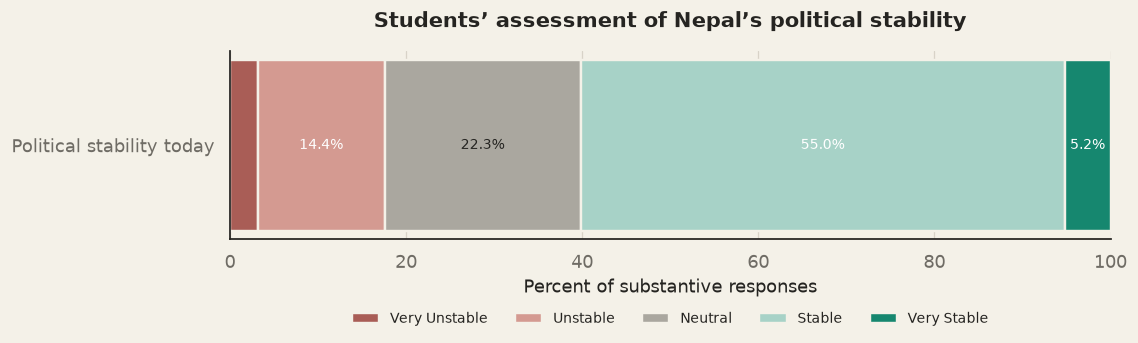

In [19]:
current_stability_order = [
    "Very Unstable", "Unstable", "Neutral", "Stable", "Very Stable"
]
current_stability = df["q3_2"].astype("string").str.strip()
current_stability = current_stability.where(
    current_stability.isin(current_stability_order)
)

current_counts = (
    current_stability.value_counts()
    .reindex(current_stability_order, fill_value=0)
)
current_percent = current_counts.div(current_counts.sum()).mul(100)
current_table = pd.DataFrame({
    "Frequency": current_counts.astype(int),
    "Percent": current_percent,
})
current_table.index.name = "Assessment"
display(current_table.round({"Percent": 1}))

stability_colors = ["#A95D56", "#D49A91", REPORT_LIGHT_GREY, REPORT_TEAL_LIGHT, REPORT_TEAL]
fig, ax = plt.subplots(figsize=(10.0, 3.4))
left = 0.0
for category, color in zip(current_stability_order, stability_colors):
    value = float(current_percent[category])
    bar = ax.barh(
        ["Political stability today"], [value], left=left,
        color=color, edgecolor=REPORT_BG, linewidth=1.5,
        label=category,
    )
    if value >= 4:
        ax.bar_label(
            bar,
            labels=[f"{value:.1f}%"],
            label_type="center",
            fontsize=9,
            color="white" if category != "Neutral" else REPORT_INK,
        )
    left += value

ax.set_xlim(0, 100)
ax.set_xlabel("Percent of substantive responses")
ax.set_ylabel("")
report_title(ax, "Students’ assessment of Nepal’s political stability")
report_axes(ax, grid_axis="x")
ax.legend(
    frameon=False, ncol=5, loc="upper center",
    bbox_to_anchor=(0.5, -0.32), fontsize=8.5,
)
plt.tight_layout()
plt.show()


### 1.2 How the present compares with the past


,More stable,About the same,Less stable
Comparison,,,
Compared with one year ago,74.7%,16.2%,9.1%
Compared with five years ago,75.9%,14.9%,9.3%


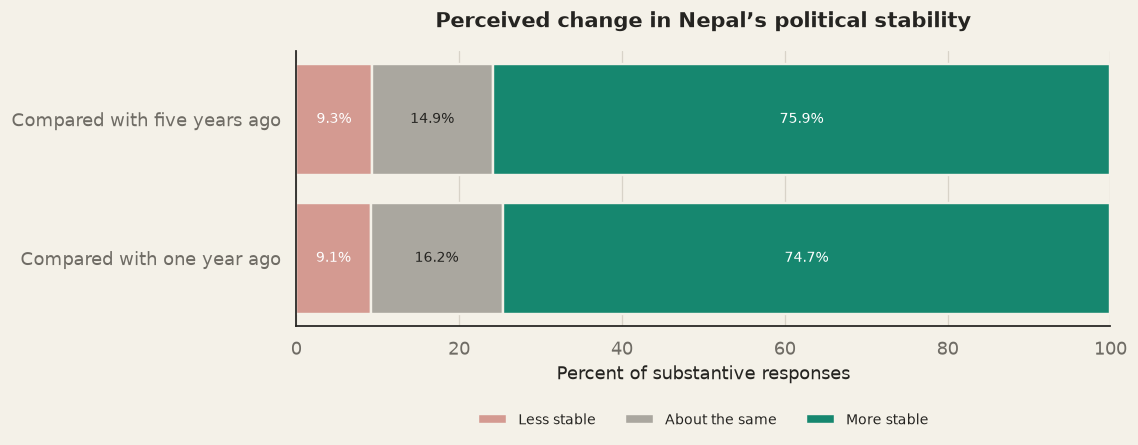

In [20]:
comparison_mapping = {
    "Much more stable": "More stable",
    "Somewhat more stable": "More stable",
    "About the same": "About the same",
    "Somewhat less stable": "Less stable",
    "Much less stable": "Less stable",
}
comparison_order = ["More stable", "About the same", "Less stable"]
comparison_variables = {
    "Compared with one year ago": "q3_3",
    "Compared with five years ago": "q3_4",
}

comparison_rows = []
for period, variable in comparison_variables.items():
    response = (
        df[variable].astype("string").str.strip()
        .map(comparison_mapping)
        .dropna()
    )
    percentages = (
        response.value_counts(normalize=True)
        .reindex(comparison_order, fill_value=0)
        .mul(100)
    )
    comparison_rows.append({"Comparison": period, **percentages.to_dict()})

comparison_percent = pd.DataFrame(comparison_rows).set_index("Comparison")
comparison_display = comparison_percent.copy()
for column in comparison_display:
    comparison_display[column] = comparison_display[column].map(
        lambda value: f"{value:.1f}%"
    )
display(comparison_display)

plot_order = ["Less stable", "About the same", "More stable"]
plot_colors = ["#D49A91", REPORT_LIGHT_GREY, REPORT_TEAL]
fig, ax = plt.subplots(figsize=(10.0, 4.2))
left = np.zeros(len(comparison_percent))
for category, color in zip(plot_order, plot_colors):
    values = comparison_percent[category].to_numpy()
    bars = ax.barh(
        comparison_percent.index,
        values,
        left=left,
        color=color,
        edgecolor=REPORT_BG,
        linewidth=1.5,
        label=category,
    )
    labels = [f"{value:.1f}%" if value >= 4 else "" for value in values]
    ax.bar_label(
        bars,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white" if category != "About the same" else REPORT_INK,
    )
    left += values

ax.set_xlim(0, 100)
ax.set_xlabel("Percent of substantive responses")
ax.set_ylabel("")
report_title(ax, "Perceived change in Nepal’s political stability")
report_axes(ax, grid_axis="x")
ax.legend(
    frameon=False, ncol=3, loc="upper center",
    bbox_to_anchor=(0.5, -0.27), fontsize=9,
)
plt.tight_layout()
plt.show()


### 1.3 Summary of the stability context


In [21]:
stable_share = float(current_percent[["Stable", "Very Stable"]].sum())
one_year_more = float(comparison_percent.loc[
    "Compared with one year ago", "More stable"
])
five_year_more = float(comparison_percent.loc[
    "Compared with five years ago", "More stable"
])

display(HTML(
    "<p>At the time of the survey, "
    f"<strong>{stable_share:.1f}%</strong> of substantive responses rated Nepal "
    "as stable or very stable. A more-stable assessment was also the dominant "
    "retrospective response: "
    f"<strong>{one_year_more:.1f}%</strong> compared the present favourably with "
    "one year earlier and "
    f"<strong>{five_year_more:.1f}%</strong> compared it favourably with five "
    "years earlier.</p>"
))


## 2. Students’ proximity to the Gen-Z movement

The survey was conducted after the September 8 Gen-Z protest. The assessments of political stability in the previous component should therefore be read as post-movement assessments. This component establishes how closely students followed or participated in the movement before examining how they explain its causes and political consequences.


### 2.1 Attention to and engagement with the movement

Respondents were asked how closely they followed the September 8 Gen-Z protest and the subsequent political developments in Nepal.


,Frequency,Percent
Response,,
Engaged directly,224,26.8
Followed very closely,477,57.1
Followed somewhat closely,116,13.9
Heard about it but followed very little,15,1.8
Did not follow it at all,4,0.5


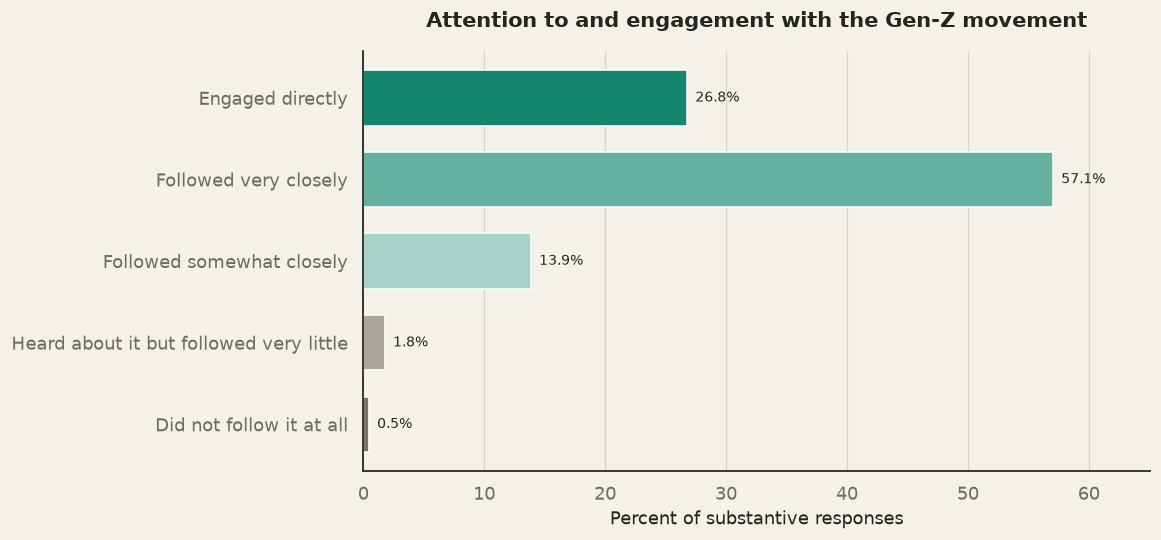

In [22]:
genz_attention_order = [
    "Engaged directly",
    "Followed very closely",
    "Followed somewhat closely",
    "Heard about it but followed very little",
    "Did not follow it at all",
]
genz_attention_labels = {
    "Engaged Directly": "Engaged directly",
    "Engaged directly": "Engaged directly",
    "Very Closely": "Followed very closely",
    "Very closely": "Followed very closely",
    "Somewhat Closely": "Followed somewhat closely",
    "Somewhat closely": "Followed somewhat closely",
    "Heard But followed Vary Little": "Heard about it but followed very little",
    "Heard but followed very little": "Heard about it but followed very little",
    "Not at All": "Did not follow it at all",
    "Not at all": "Did not follow it at all",
}

genz_attention_raw = df["q4_1"].astype("string").str.strip()
genz_attention = genz_attention_raw.replace(genz_attention_labels)
genz_attention = genz_attention.where(
    genz_attention.isin(genz_attention_order)
)

genz_attention_counts = (
    genz_attention.value_counts()
    .reindex(genz_attention_order, fill_value=0)
)
genz_attention_percent = (
    genz_attention_counts.div(genz_attention_counts.sum()).mul(100)
)
genz_attention_table = pd.DataFrame({
    "Frequency": genz_attention_counts.astype(int),
    "Percent": genz_attention_percent,
})
genz_attention_table.index.name = "Response"
display(genz_attention_table.round({"Percent": 1}))

attention_colors = [
    REPORT_TEAL,
    REPORT_TEAL_MID,
    REPORT_TEAL_LIGHT,
    REPORT_LIGHT_GREY,
    REPORT_GREY,
]
fig, ax = plt.subplots(figsize=(10.2, 4.8))
bars = ax.barh(
    genz_attention_percent.index,
    genz_attention_percent.values,
    color=attention_colors,
    height=0.68,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in genz_attention_percent.values],
    padding=5,
    fontsize=9,
    color=REPORT_INK,
)
ax.set_xlim(0, max(65, float(genz_attention_percent.max()) + 8))
ax.set_xlabel("Percent of substantive responses")
ax.set_ylabel("")
ax.invert_yaxis()
report_title(ax, "Attention to and engagement with the Gen-Z movement")
report_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()


### 2.2 Analytical grouping for later comparisons

For later cross-tabulations, the five responses are grouped into three categories while the original five-category variable remains the basis of the descriptive results above:

- **Directly engaged:** engaged directly
- **Closely followed:** followed very closely or somewhat closely
- **Limited attention:** heard about it but followed very little, or did not follow it at all

This derived variable will allow clearer comparisons with future voting, political efficacy, and expectations of political change.


In [23]:
genz_proximity_mapping = {
    "Engaged directly": "Directly engaged",
    "Followed very closely": "Closely followed",
    "Followed somewhat closely": "Closely followed",
    "Heard about it but followed very little": "Limited attention",
    "Did not follow it at all": "Limited attention",
}
genz_proximity_order = [
    "Directly engaged", "Closely followed", "Limited attention"
]
df["genz_proximity"] = pd.Categorical(
    genz_attention.map(genz_proximity_mapping),
    categories=genz_proximity_order,
    ordered=True,
)

# Confirm that the grouping retains every substantive q4_1 response.
assert df["genz_proximity"].notna().sum() == genz_attention.notna().sum()


### 2.3 Political-news consumption and Gen-Z attention

Political-news consumption is grouped into **Frequent** (daily or several times a week) and **Less frequent** (weekly, occasionally, or never). The comparison tests whether general political-information habits are reflected in attention to this specific movement.

Outcome: n (row %),Directly engaged,Closely followed,Limited attention,Total n
Political-news consumption,,,,
Frequent,184 (28.0%),462 (70.3%),11 (1.7%),657
Less frequent,40 (22.3%),131 (73.2%),8 (4.5%),179


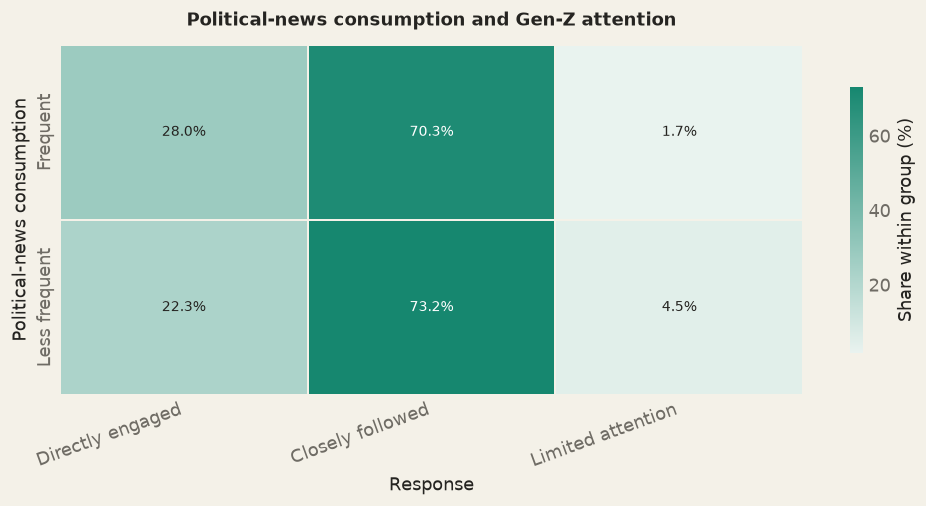

In [24]:
news_group = df["q2_2"].astype("string").str.strip().map({
    "Daily": "Frequent",
    "Several times a week": "Frequent",
    "Weekly": "Less frequent",
    "Occasionally": "Less frequent",
    "Never": "Less frequent",
})
news_order = ["Frequent", "Less frequent"]

news_attention_counts, news_attention_pct, news_attention_table, news_attention_stats = (
    bridge_crosstab(
        news_group,
        df["genz_proximity"],
        news_order,
        genz_proximity_order,
        "Political-news consumption",
    )
)
display(news_attention_table)

fig, ax = plt.subplots(figsize=(8.8, 4.5))
draw_response_heatmap(
    ax,
    news_attention_pct,
    "Political-news consumption and Gen-Z attention",
    "Political-news consumption",
    x_rotation=20,
)
plt.tight_layout()
plt.show()

display(HTML(
    "<p>The relationship is present but small. Frequent news followers were more "
    f"often directly engaged (<strong>{news_attention_pct.loc['Frequent', 'Directly engaged']:.1f}%</strong>) "
    "than less-frequent followers "
    f"(<strong>{news_attention_pct.loc['Less frequent', 'Directly engaged']:.1f}%</strong>). "
    "Limited attention was also less common among frequent followers "
    f"({news_attention_pct.loc['Frequent', 'Limited attention']:.1f}% versus "
    f"{news_attention_pct.loc['Less frequent', 'Limited attention']:.1f}%). "
    f"The overall association is weak (Cramér’s V = {news_attention_stats['v']:.2f}, "
    f"p = {news_attention_stats['p']:.3f}). News consumption provides some context "
    "for movement attention, but it does not sharply separate respondents.</p>"
))

### 2.4 Political involvement and Gen-Z attention

This comparison asks whether respondents who reported active involvement in politics or political organisations were also more directly engaged with the Gen-Z movement.

Outcome: n (row %),Directly engaged,Closely followed,Limited attention,Total n
Actively involved in politics,,,,
Yes,77 (45.6%),89 (52.7%),3 (1.8%),169
No,147 (22.0%),504 (75.6%),16 (2.4%),667


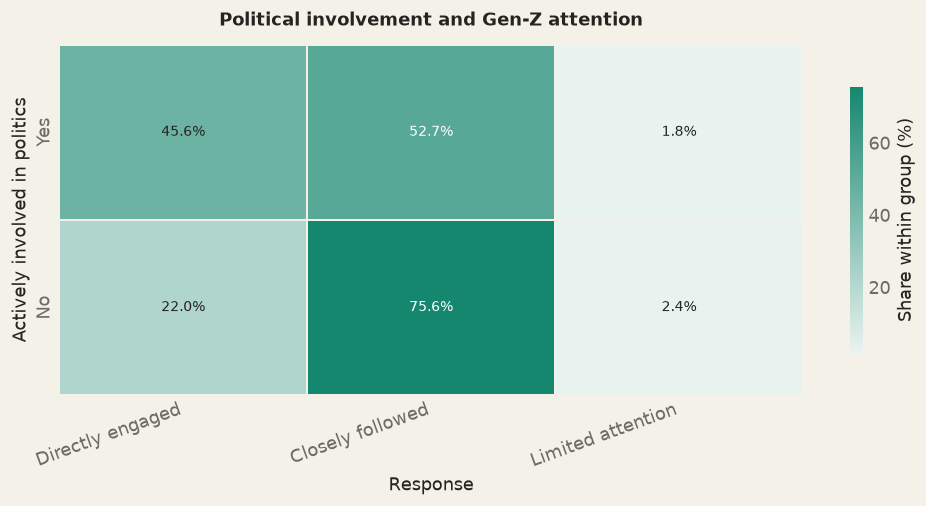

In [25]:
political_involvement = df["q2_3"].astype("string").str.strip()
involvement_order = ["Yes", "No"]

involvement_attention_counts, involvement_attention_pct, involvement_attention_table, involvement_attention_stats = (
    bridge_crosstab(
        political_involvement,
        df["genz_proximity"],
        involvement_order,
        genz_proximity_order,
        "Actively involved in politics",
    )
)
display(involvement_attention_table)

fig, ax = plt.subplots(figsize=(8.8, 4.5))
draw_response_heatmap(
    ax,
    involvement_attention_pct,
    "Political involvement and Gen-Z attention",
    "Actively involved in politics",
    x_rotation=20,
)
plt.tight_layout()
plt.show()

display(HTML(
    "<p>Prior political involvement has a clearer relationship with direct engagement. "
    f"Among politically involved respondents, <strong>{involvement_attention_pct.loc['Yes', 'Directly engaged']:.1f}%</strong> "
    "reported direct engagement with the Gen-Z movement, compared with "
    f"<strong>{involvement_attention_pct.loc['No', 'Directly engaged']:.1f}%</strong> "
    "among those not actively involved in politics. The association is moderate "
    f"(Cramér’s V = {involvement_attention_stats['v']:.2f}, p &lt; 0.001). "
    "This indicates continuity between established political involvement and direct "
    "movement engagement, without establishing a causal relationship.</p>"
))

### 2.5 Interpretation and transition

In [26]:
direct_share = float(genz_attention_percent["Engaged directly"])
very_close_share = float(genz_attention_percent["Followed very closely"])
somewhat_close_share = float(genz_attention_percent["Followed somewhat closely"])
limited_share = float(genz_attention_percent[[
    "Heard about it but followed very little",
    "Did not follow it at all",
]].sum())

display(HTML(
    "<p>Students in the sample were highly attentive to the Gen-Z movement. "
    f"<strong>{direct_share:.1f}%</strong> reported direct engagement and "
    f"<strong>{very_close_share:.1f}%</strong> followed it very closely. "
    f"Together, these groups account for <strong>{direct_share + very_close_share:.1f}%</strong> "
    "of substantive responses. A further "
    f"<strong>{somewhat_close_share:.1f}%</strong> followed it somewhat closely, "
    f"while only <strong>{limited_share:.1f}%</strong> reported limited or no attention. "
    "Political-news consumption shows only a modest relationship with attention, while "
    "prior political involvement more clearly distinguishes direct engagement. "
    "The following component therefore examines how this largely attentive student sample "
    "explains the Gen-Z protest and the broader political instability surrounding it.</p>"
))


## 3. From the Gen-Z protest to wider political instability

Having established that most respondents followed or participated in the Gen-Z movement, this component examines how they explain it. It then moves from the specific protest to students’ explanations of political instability in Nepal more broadly. The two sets of questions are presented separately because they refer to different outcomes.


In [27]:
import textwrap
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter


likert_order = [
    "Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"
]
likert_aliases = {
    "Strongly Disagree": "Strongly disagree",
    "Strongly disagree": "Strongly disagree",
    "Disagree": "Disagree",
    "Neutral": "Neutral",
    "Agree": "Agree",
    "Strongly Agree": "Strongly agree",
    "Strongly agree": "Strongly agree",
}


def prepare_likert_battery(data, item_labels):
    # Produce full five-category percentages, a ranked summary, and an audit.
    detailed_rows = {}
    audit_rows = []

    for variable, label in item_labels.items():
        raw = data[variable].astype("string").str.strip()
        substantive = raw.replace(likert_aliases)
        substantive = substantive.where(substantive.isin(likert_order))
        counts = substantive.value_counts().reindex(likert_order, fill_value=0)
        percentages = counts.div(counts.sum()).mul(100)
        detailed_rows[label] = percentages
        audit_rows.append({
            "Variable": variable,
            "Item": label,
            "Substantive N": int(substantive.notna().sum()),
            "Non-substantive N": int(substantive.isna().sum()),
        })

    detailed = pd.DataFrame.from_dict(detailed_rows, orient="index")
    detailed.index.name = "Proposed cause"
    summary = pd.DataFrame({
        "Agree or strongly agree (%)": detailed[
            ["Agree", "Strongly agree"]
        ].sum(axis=1),
        "Neutral (%)": detailed["Neutral"],
        "Disagree or strongly disagree (%)": detailed[
            ["Strongly disagree", "Disagree"]
        ].sum(axis=1),
    }).sort_values("Agree or strongly agree (%)", ascending=False)
    detailed = detailed.reindex(summary.index)
    audit = pd.DataFrame(audit_rows).set_index("Variable")
    return summary, detailed, audit


def plot_diverging_likert(percentages, title):
    # Place half of the neutral category on each side of the zero line.
    plot_data = percentages.copy()
    y_positions = np.arange(len(plot_data))

    strongly_disagree = plot_data["Strongly disagree"].to_numpy()
    disagree = plot_data["Disagree"].to_numpy()
    neutral = plot_data["Neutral"].to_numpy()
    agree = plot_data["Agree"].to_numpy()
    strongly_agree = plot_data["Strongly agree"].to_numpy()

    strongly_disagree_left = -(
        strongly_disagree + disagree + neutral / 2
    )
    disagree_left = -(disagree + neutral / 2)
    agree_left = neutral / 2
    strongly_agree_left = neutral / 2 + agree

    colors = {
        "Strongly disagree": "#A95D56",
        "Disagree": "#D49A91",
        "Neutral": REPORT_LIGHT_GREY,
        "Agree": REPORT_TEAL_LIGHT,
        "Strongly agree": REPORT_TEAL,
    }

    fig_height = 3.2 + 0.55 * len(plot_data)
    fig, ax = plt.subplots(figsize=(13.4, fig_height))
    ax.barh(
        y_positions, strongly_disagree, left=strongly_disagree_left,
        color=colors["Strongly disagree"], edgecolor=REPORT_BG, linewidth=0.8,
    )
    ax.barh(
        y_positions, disagree, left=disagree_left,
        color=colors["Disagree"], edgecolor=REPORT_BG, linewidth=0.8,
    )
    ax.barh(
        y_positions, neutral / 2, left=-neutral / 2,
        color=colors["Neutral"], edgecolor=REPORT_BG, linewidth=0.8,
    )
    ax.barh(
        y_positions, neutral / 2, left=0,
        color=colors["Neutral"], edgecolor=REPORT_BG, linewidth=0.8,
    )
    ax.barh(
        y_positions, agree, left=agree_left,
        color=colors["Agree"], edgecolor=REPORT_BG, linewidth=0.8,
    )
    ax.barh(
        y_positions, strongly_agree, left=strongly_agree_left,
        color=colors["Strongly agree"], edgecolor=REPORT_BG, linewidth=0.8,
    )

    def label_segments(values, left_edges, text_color):
        for y_position, value, left_edge in zip(
            y_positions, values, left_edges
        ):
            if value >= 7:
                ax.text(
                    left_edge + value / 2,
                    y_position,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8.2,
                    color=text_color,
                )

    label_segments(
        strongly_disagree, strongly_disagree_left, "white"
    )
    label_segments(disagree, disagree_left, REPORT_INK)
    for y_position, value in zip(y_positions, neutral):
        if value >= 7:
            ax.text(
                0, y_position, f"{value:.0f}%", ha="center", va="center",
                fontsize=8.2, color=REPORT_INK,
            )
    label_segments(agree, agree_left, REPORT_INK)
    label_segments(strongly_agree, strongly_agree_left, "white")

    wrapped_labels = [
        textwrap.fill(label, width=36) for label in plot_data.index
    ]
    ax.set_yticks(y_positions, wrapped_labels)
    ax.invert_yaxis()
    ax.set_xlim(-100, 100)
    ax.set_xticks(np.arange(-100, 101, 25))
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{abs(int(value))}%")
    )
    ax.axvline(0, color=REPORT_INK, linewidth=1.0, zorder=5)
    ax.set_xlabel("Share of substantive responses")
    ax.set_ylabel("")
    report_title(ax, title)
    report_axes(ax, grid_axis="x")
    ax.legend(
        handles=[
            Patch(facecolor=colors[category], label=category)
            for category in likert_order
        ],
        frameon=False,
        ncol=5,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.10),
        fontsize=8.5,
    )
    plt.tight_layout(pad=1.2)
    plt.show()


### 3.1 What students believe caused the Gen-Z protest

The table ranks the eight proposed causes by the share agreeing or strongly agreeing. The chart retains the original five response categories.


,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Proposed cause,,,
Corruption,93.8,2.6,3.6
"Distrust of leaders, parties, and institutions",90.2,6.6,3.2
Nepotism and elite capture,89.2,6.7,4.1
Unemployment and limited economic opportunities,85.2,7.1,7.8
Poor public services,85.0,9.9,5.2
Social-media ban,80.6,11.5,7.9
Rising cost of living,63.2,14.6,22.2
Foreign or external influence,49.4,18.9,31.7


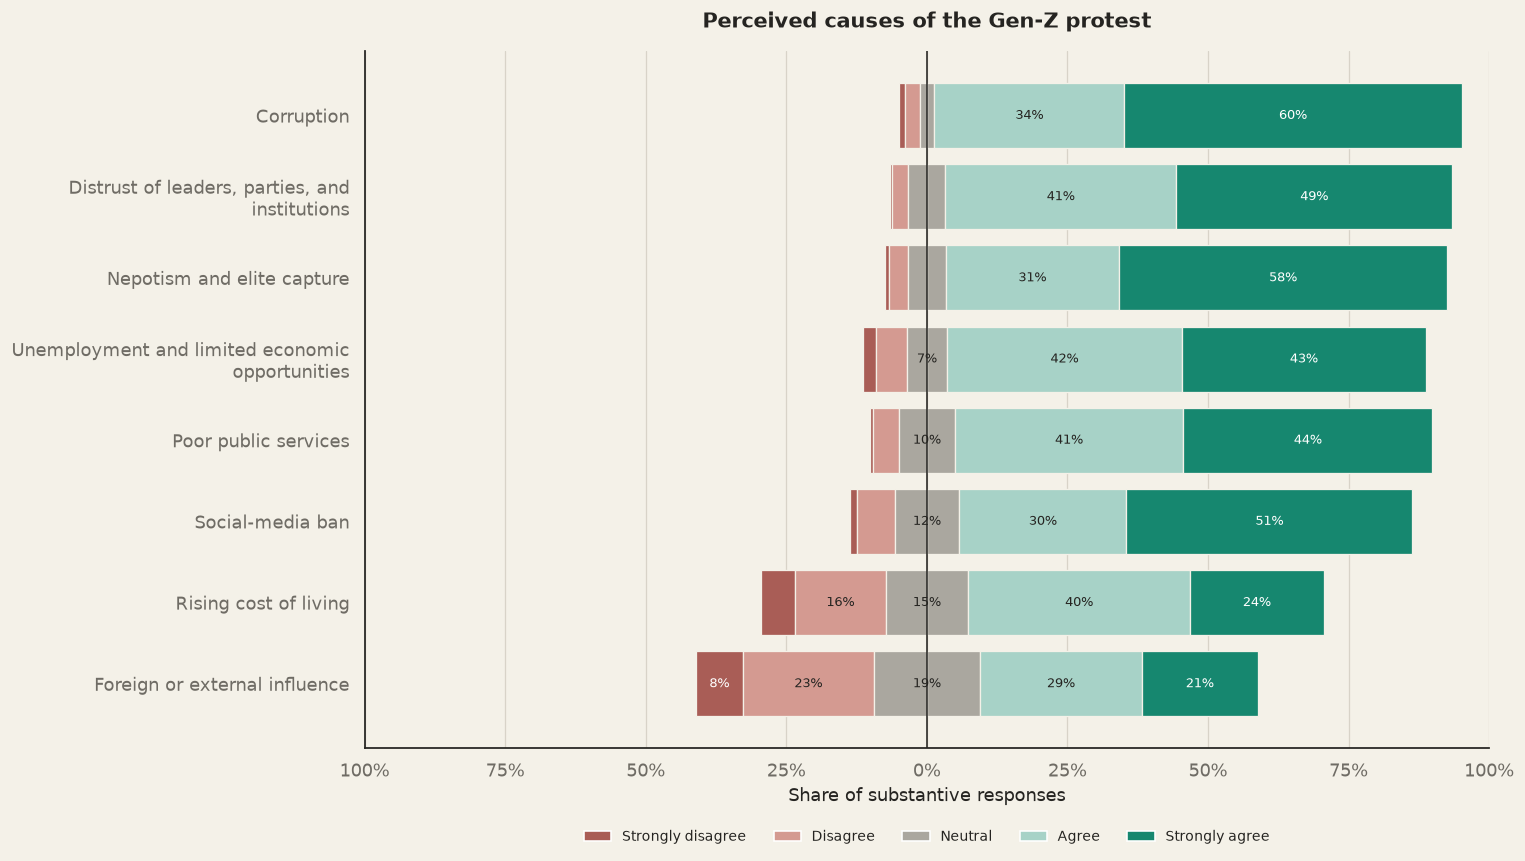

In [28]:
genz_cause_items = {
    "q4_2_1": "Corruption",
    "q4_2_2": "Poor public services",
    "q4_2_3": "Unemployment and limited economic opportunities",
    "q4_2_4": "Rising cost of living",
    "q4_2_5": "Distrust of leaders, parties, and institutions",
    "q4_2_6": "Nepotism and elite capture",
    "q4_2_7": "Social-media ban",
    "q4_2_8": "Foreign or external influence",
}

genz_cause_summary, genz_cause_detail, genz_cause_audit = (
    prepare_likert_battery(df, genz_cause_items)
)
display(genz_cause_summary.round(1))
plot_diverging_likert(
    genz_cause_detail,
    "Perceived causes of the Gen-Z protest",
)


In [29]:
genz_top = genz_cause_summary.head(3)[
    "Agree or strongly agree (%)"
]
genz_lowest_label = genz_cause_summary.index[-1]
genz_lowest_share = float(
    genz_cause_summary.iloc[-1]["Agree or strongly agree (%)"]
)
genz_external_neutral = float(
    genz_cause_detail.loc["Foreign or external influence", "Neutral"]
)
genz_external_disagree = float(
    genz_cause_summary.loc[
        "Foreign or external influence",
        "Disagree or strongly disagree (%)",
    ]
)

display(HTML(
    "<p>The most widely accepted explanations were governance-related. "
    f"Agreement reached <strong>{genz_top.iloc[0]:.1f}%</strong> for "
    f"{genz_top.index[0].lower()}, <strong>{genz_top.iloc[1]:.1f}%</strong> "
    f"for {genz_top.index[1].lower()}, and "
    f"<strong>{genz_top.iloc[2]:.1f}%</strong> for "
    f"{genz_top.index[2].lower()}. Unemployment and limited economic "
    "opportunities and the social-media ban also received broad agreement. "
    f"{genz_lowest_label} received the least agreement at "
    f"<strong>{genz_lowest_share:.1f}%</strong>; "
    f"{genz_external_neutral:.1f}% were neutral and "
    f"{genz_external_disagree:.1f}% disagreed. Students therefore understood "
    "the protest mainly through domestic governance and economic concerns, "
    "with substantially less consensus around an external explanation.</p>"
))


### 3.2 What students believe causes political instability

The analysis now moves from explanations of the Gen-Z protest to the broader institutional and political conditions students associate with instability in Nepal.


,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Proposed cause,,,
Corruption,95.9,2.4,1.7
Failure to implement policies,93.9,4.1,2.0
Frequent government changes and party conflict,93.0,4.7,2.3
Failure to formulate policies,92.8,3.2,4.0
Lack of accountability,92.1,5.6,2.3
"Protests, violence, and civic unrest",89.6,6.2,4.2
Conflict between levels of government,89.0,7.1,4.0
Foreign or external influence,76.0,15.3,8.7
Frequent transfers of government officials,63.9,18.0,18.1


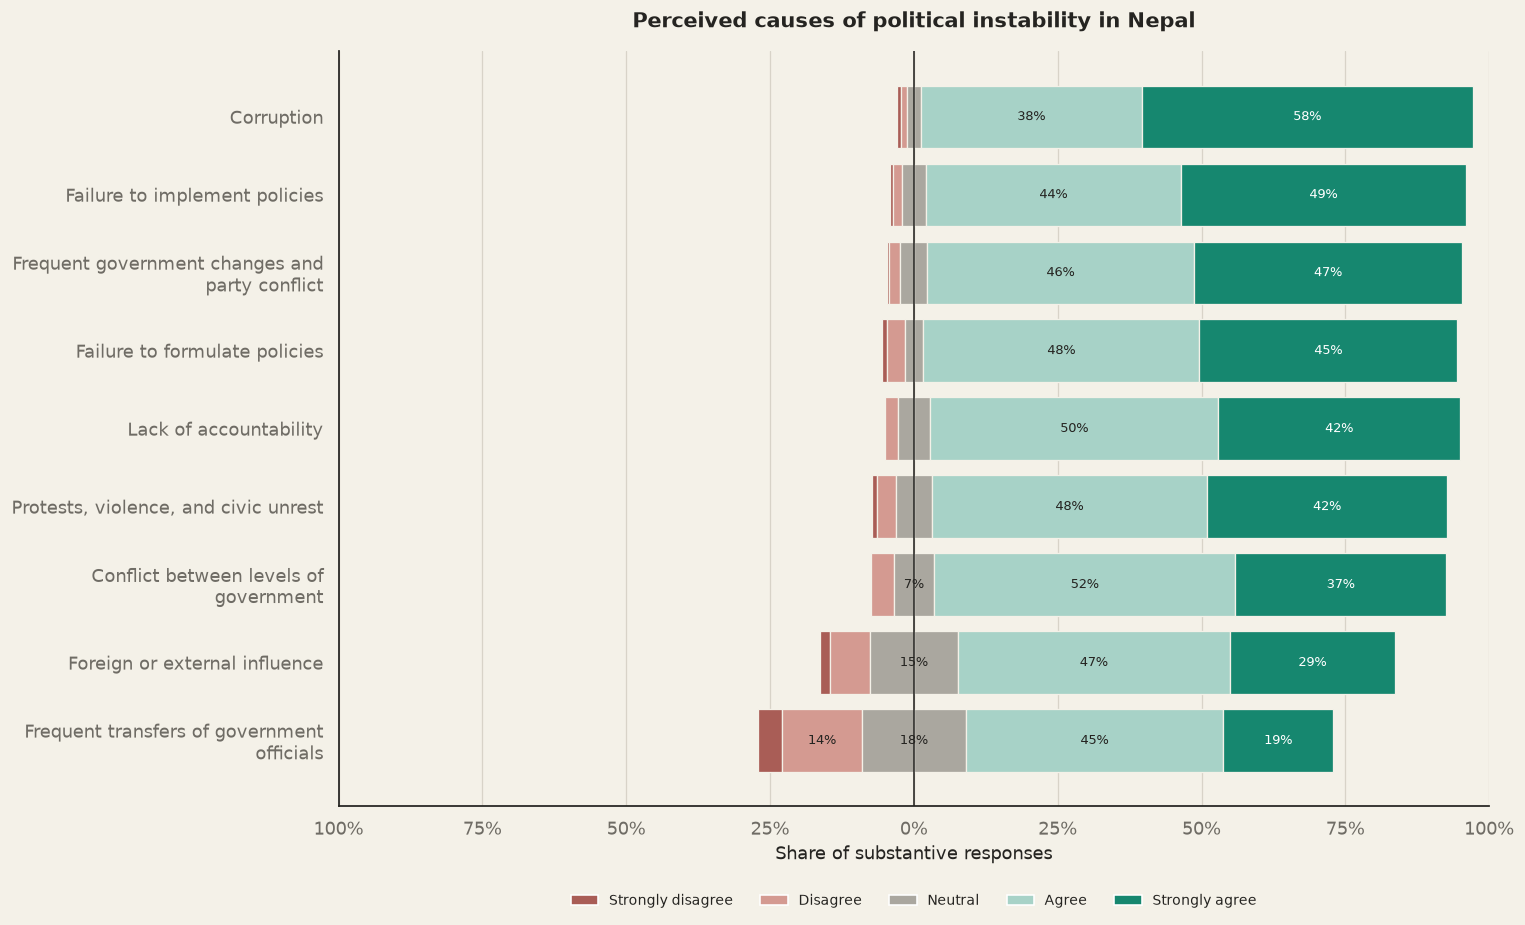

In [30]:
instability_cause_items = {
    "q3_1_1": "Frequent government changes and party conflict",
    "q3_1_2": "Failure to formulate policies",
    "q3_1_2_001": "Failure to implement policies",
    "q3_1_3": "Corruption",
    "q3_1_3_001": "Lack of accountability",
    "q3_1_4": "Protests, violence, and civic unrest",
    "q3_1_5": "Frequent transfers of government officials",
    "q3_1_6": "Conflict between levels of government",
    "q3_1_7": "Foreign or external influence",
}

instability_cause_summary, instability_cause_detail, instability_cause_audit = (
    prepare_likert_battery(df, instability_cause_items)
)
display(instability_cause_summary.round(1))
plot_diverging_likert(
    instability_cause_detail,
    "Perceived causes of political instability in Nepal",
)


In [31]:
instability_top = instability_cause_summary.head(4)[
    "Agree or strongly agree (%)"
]
instability_lowest_label = instability_cause_summary.index[-1]
instability_lowest_share = float(
    instability_cause_summary.iloc[-1]["Agree or strongly agree (%)"]
)
unrest_share = float(
    instability_cause_summary.loc[
        "Protests, violence, and civic unrest",
        "Agree or strongly agree (%)",
    ]
)

display(HTML(
    "<p>Students located political instability primarily in failures of "
    "governance and institutional performance. Agreement was highest for "
    f"{instability_top.index[0].lower()} "
    f"(<strong>{instability_top.iloc[0]:.1f}%</strong>), followed by "
    f"{instability_top.index[1].lower()} "
    f"(<strong>{instability_top.iloc[1]:.1f}%</strong>), "
    f"{instability_top.index[2].lower()} "
    f"(<strong>{instability_top.iloc[2]:.1f}%</strong>), and "
    f"{instability_top.index[3].lower()} "
    f"(<strong>{instability_top.iloc[3]:.1f}%</strong>). "
    f"A further <strong>{unrest_share:.1f}%</strong> agreed that protests, "
    "violence, and civic unrest contribute to instability. "
    f"{instability_lowest_label} ranked last, although it still received "
    f"agreement from <strong>{instability_lowest_share:.1f}%</strong> of "
    "substantive respondents.</p>"
))


### 3.3 Where the explanations overlap

Corruption and foreign or external influence appear in both batteries and can be compared directly at a descriptive level. Other themes are related but not identically worded: poor public services corresponds broadly to policy failures, while distrust of institutions and nepotism relate to accountability and party conflict. The two batteries are not combined into a single index.


In [32]:
overlap_table = pd.DataFrame({
    "Cause of Gen-Z protest (%)": [
        genz_cause_summary.loc[
            "Corruption", "Agree or strongly agree (%)"
        ],
        genz_cause_summary.loc[
            "Foreign or external influence", "Agree or strongly agree (%)"
        ],
    ],
    "Cause of political instability (%)": [
        instability_cause_summary.loc[
            "Corruption", "Agree or strongly agree (%)"
        ],
        instability_cause_summary.loc[
            "Foreign or external influence", "Agree or strongly agree (%)"
        ],
    ],
}, index=["Corruption", "Foreign or external influence"])
overlap_table["Difference (instability − protest, pp)"] = (
    overlap_table["Cause of political instability (%)"]
    - overlap_table["Cause of Gen-Z protest (%)"]
)
overlap_table.index.name = "Explanation appearing in both batteries"
display(overlap_table.round(1))

corruption_protest = float(
    overlap_table.loc["Corruption", "Cause of Gen-Z protest (%)"]
)
corruption_instability = float(
    overlap_table.loc["Corruption", "Cause of political instability (%)"]
)
external_protest = float(
    overlap_table.loc[
        "Foreign or external influence", "Cause of Gen-Z protest (%)"
    ]
)
external_instability = float(
    overlap_table.loc[
        "Foreign or external influence", "Cause of political instability (%)"
    ]
)

display(HTML(
    "<p>Corruption received very high agreement in both contexts: "
    f"<strong>{corruption_protest:.1f}%</strong> as a cause of the Gen-Z "
    f"protest and <strong>{corruption_instability:.1f}%</strong> as a cause "
    "of political instability. External influence produced a different "
    f"pattern: <strong>{external_protest:.1f}%</strong> linked it to the "
    f"protest, compared with <strong>{external_instability:.1f}%</strong> "
    "who linked it to instability more generally. The comparison is "
    "descriptive because the wording of the two questions is not identical.</p>"
))


,Cause of Gen-Z protest (%),Cause of political instability (%),"Difference (instability − protest, pp)"
Explanation appearing in both batteries,,,
Corruption,93.8,95.9,2.2
Foreign or external influence,49.4,76.0,26.6


### 3.4 Interpretation and transition

Across the two batteries, respondents placed greatest emphasis on domestic governance and institutional failures. The Gen-Z movement was additionally associated with unemployment, economic pressures, and the social-media ban. At the same time, many respondents regarded protests, violence, and civic unrest as contributors to instability. This suggests a reciprocal interpretation: political failures can generate protest, while protest and unrest can also deepen perceptions of instability.


## 4. What students believe the Gen-Z movement changed

This component examines the movement’s perceived political consequences. The six statements distinguish the movement’s historical importance, its effects on participation and inclusion, its perceived effect on party politics, and confidence that the government represents youth interests. They are presented together for comparison but are not combined into a single scale.


,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Proposed cause,,,
Increased public support for RSP,91.9,6.1,1.9
Political turning point,91.8,6.2,1.9
Greater youth civic and political participation,91.2,5.9,2.9
Inclusion of youth voices in mainstream politics,84.6,9.9,5.5
Current government represents youth interests,77.9,16.4,5.7
Government will continue to advance youth interests,76.8,17.3,6.0


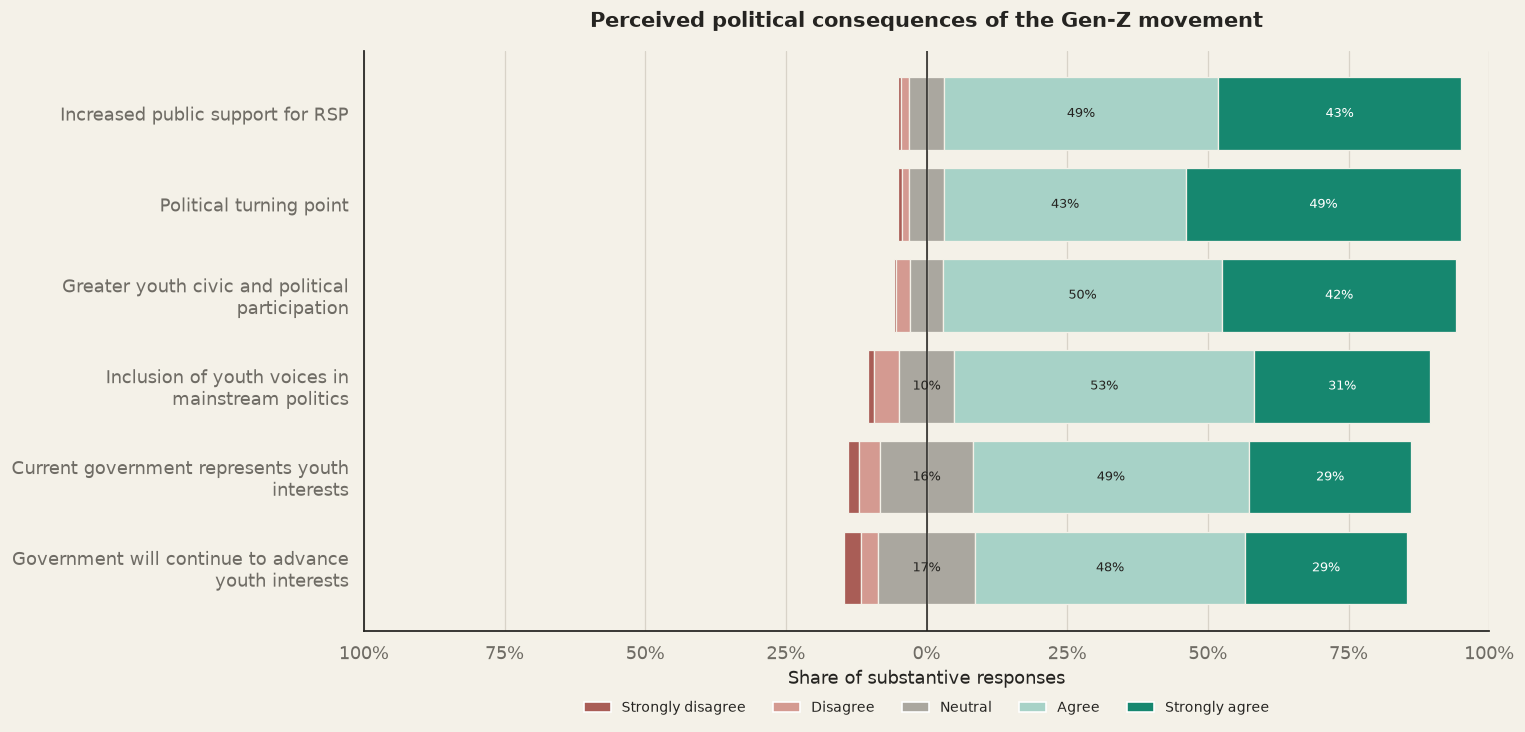

In [33]:
genz_consequence_items = {
    "q4_3": "Political turning point",
    "q4_4": "Greater youth civic and political participation",
    "q4_5": "Inclusion of youth voices in mainstream politics",
    "q4_6": "Increased public support for RSP",
    "q4_7": "Current government represents youth interests",
    "q4_8": "Government will continue to advance youth interests",
}

genz_consequence_summary, genz_consequence_detail, genz_consequence_audit = (
    prepare_likert_battery(df, genz_consequence_items)
)
display(genz_consequence_summary.round(1))
plot_diverging_likert(
    genz_consequence_detail,
    "Perceived political consequences of the Gen-Z movement",
)


### 4.1 Was the movement a political turning point?


In [34]:
turning_agree = float(
    genz_consequence_summary.loc[
        "Political turning point", "Agree or strongly agree (%)"
    ]
)
turning_neutral = float(
    genz_consequence_summary.loc["Political turning point", "Neutral (%)"]
)
turning_disagree = float(
    genz_consequence_summary.loc[
        "Political turning point", "Disagree or strongly disagree (%)"
    ]
)

display(HTML(
    f"<p><strong>{turning_agree:.1f}%</strong> agreed or strongly agreed that "
    "the Gen-Z protest represented a turning point in Nepal’s political "
    f"history. Only {turning_neutral:.1f}% were neutral and "
    f"{turning_disagree:.1f}% disagreed. Students therefore tended to view "
    "the movement as a consequential political event rather than an isolated "
    "episode.</p>"
))


### 4.2 Turning-point belief by prior political involvement

The five response categories are grouped as **Agree**, **Neutral**, and **Disagree** to examine whether prior political involvement is related to interpreting the protest as a historical turning point.

Outcome: n (row %),Agree,Neutral,Disagree,Total n
Actively involved in politics,,,,
Yes,149 (88.7%),13 (7.7%),6 (3.6%),168
No,616 (92.6%),39 (5.9%),10 (1.5%),665


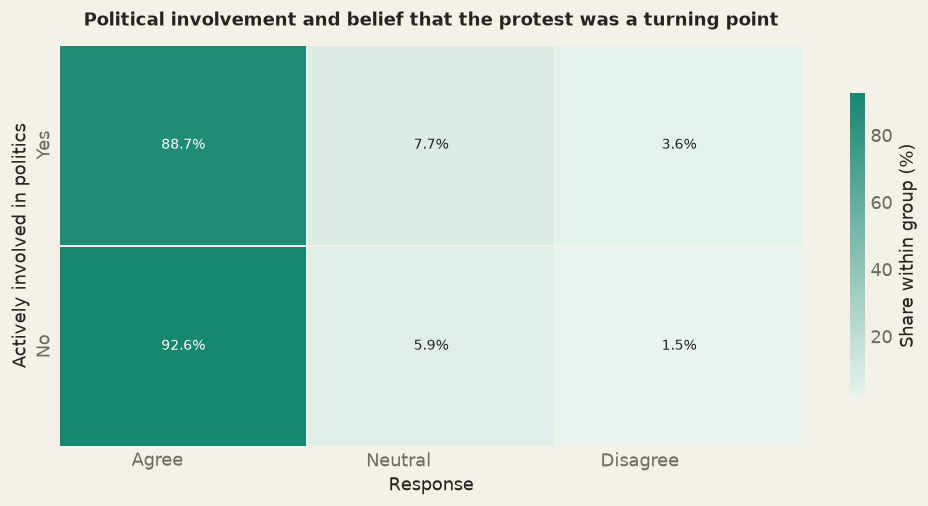

In [35]:
turning_point_group = df["q4_3"].astype("string").str.strip().map({
    "Strongly Agree": "Agree",
    "Agree": "Agree",
    "Neutral": "Neutral",
    "Disagree": "Disagree",
    "Strongly Disagree": "Disagree",
})
turning_order = ["Agree", "Neutral", "Disagree"]

involvement_turning_counts, involvement_turning_pct, involvement_turning_table, involvement_turning_stats = (
    bridge_crosstab(
        political_involvement,
        turning_point_group,
        involvement_order,
        turning_order,
        "Actively involved in politics",
    )
)
display(involvement_turning_table)

fig, ax = plt.subplots(figsize=(8.8, 4.5))
draw_response_heatmap(
    ax,
    involvement_turning_pct,
    "Political involvement and belief that the protest was a turning point",
    "Actively involved in politics",
    x_rotation=0,
)
plt.tight_layout()
plt.show()

display(HTML(
    "<p>Belief that the protest was a turning point is widespread in both groups. "
    f"Agreement was <strong>{involvement_turning_pct.loc['Yes', 'Agree']:.1f}%</strong> "
    "among politically involved respondents and "
    f"<strong>{involvement_turning_pct.loc['No', 'Agree']:.1f}%</strong> among those "
    "not actively involved. The association is weak and statistically inconclusive "
    f"(Cramér’s V = {involvement_turning_stats['v']:.2f}, "
    f"p = {involvement_turning_stats['p']:.3f}). The turning-point interpretation "
    "therefore appears to be broadly shared rather than confined to already politically "
    "involved students.</p>"
))

### 4.3 Youth participation and inclusion

In [36]:
participation_agree = float(
    genz_consequence_summary.loc[
        "Greater youth civic and political participation",
        "Agree or strongly agree (%)",
    ]
)
inclusion_agree = float(
    genz_consequence_summary.loc[
        "Inclusion of youth voices in mainstream politics",
        "Agree or strongly agree (%)",
    ]
)
inclusion_neutral = float(
    genz_consequence_summary.loc[
        "Inclusion of youth voices in mainstream politics", "Neutral (%)"
    ]
)

display(HTML(
    f"<p><strong>{participation_agree:.1f}%</strong> believed that the "
    "movement increased youth civic and political participation. Agreement "
    "that it increased the inclusion of youth voices in mainstream politics "
    f"was also high, at <strong>{inclusion_agree:.1f}%</strong>, although "
    f"{inclusion_neutral:.1f}% remained neutral. The results suggest stronger "
    "confidence in youth mobilisation than in the institutional inclusion of "
    "youth voices.</p>"
))


### 4.4 Perceived effect on party politics

In [37]:
rsp_agree = float(
    genz_consequence_summary.loc[
        "Increased public support for RSP", "Agree or strongly agree (%)"
    ]
)
rsp_neutral = float(
    genz_consequence_summary.loc[
        "Increased public support for RSP", "Neutral (%)"
    ]
)
rsp_disagree = float(
    genz_consequence_summary.loc[
        "Increased public support for RSP",
        "Disagree or strongly disagree (%)",
    ]
)

display(HTML(
    f"<p><strong>{rsp_agree:.1f}%</strong> perceived that the movement "
    "increased public support for the Rastriya Swatantra Party. "
    f"{rsp_neutral:.1f}% were neutral and {rsp_disagree:.1f}% disagreed. "
    "This item measures respondents’ perceptions of a party-system effect; "
    "it does not measure their own support for RSP or actual electoral change.</p>"
))


### 4.5 Does the government represent youth interests?

In [38]:
current_youth_agree = float(
    genz_consequence_summary.loc[
        "Current government represents youth interests",
        "Agree or strongly agree (%)",
    ]
)
future_youth_agree = float(
    genz_consequence_summary.loc[
        "Government will continue to advance youth interests",
        "Agree or strongly agree (%)",
    ]
)
current_youth_neutral = float(
    genz_consequence_summary.loc[
        "Current government represents youth interests", "Neutral (%)"
    ]
)
future_youth_neutral = float(
    genz_consequence_summary.loc[
        "Government will continue to advance youth interests", "Neutral (%)"
    ]
)

display(HTML(
    f"<p><strong>{current_youth_agree:.1f}%</strong> agreed that the current "
    "government represents youth interests, while "
    f"<strong>{future_youth_agree:.1f}%</strong> expected the government to "
    "continue advancing those interests. These majorities are smaller than "
    "those recorded for the movement’s broader political consequences. "
    f"Neutral responses were also higher, at {current_youth_neutral:.1f}% "
    f"and {future_youth_neutral:.1f}%, respectively. The difference reflects "
    "greater uncertainty about sustained institutional representation than "
    "about the movement’s immediate political importance.</p>"
))


### 4.6 Interpretation and transition

In [39]:
movement_labels = [
    "Political turning point",
    "Greater youth civic and political participation",
    "Inclusion of youth voices in mainstream politics",
    "Increased public support for RSP",
]
government_labels = [
    "Current government represents youth interests",
    "Government will continue to advance youth interests",
]
movement_agreement = genz_consequence_summary.loc[
    movement_labels, "Agree or strongly agree (%)"
]
government_agreement = genz_consequence_summary.loc[
    government_labels, "Agree or strongly agree (%)"
]

display(HTML(
    "<p>Agreement with the four movement-level consequences ranged from "
    f"<strong>{movement_agreement.min():.1f}%</strong> to "
    f"<strong>{movement_agreement.max():.1f}%</strong>. Agreement with the "
    "two government-representation statements was lower, ranging from "
    f"<strong>{government_agreement.min():.1f}%</strong> to "
    f"<strong>{government_agreement.max():.1f}%</strong>. Students therefore "
    "expressed strong confidence that the movement changed political "
    "participation and party competition, alongside more cautious confidence "
    "that the government would translate that momentum into sustained youth "
    "representation.</p>"
))


## 5. Future stability and expectations of political change

The analysis now moves from students’ assessment of the Gen-Z movement to their expectations about Nepal’s broader political trajectory. It first examines whether students expect stability to improve over the next five years, and then considers how likely they think specific forms of political change are.


### 5.1 Expected stability five years from now


,Frequency,Percent
Expected stability in five years,,
More stable,601,83.5
About the same,66,9.2
Less stable,53,7.4


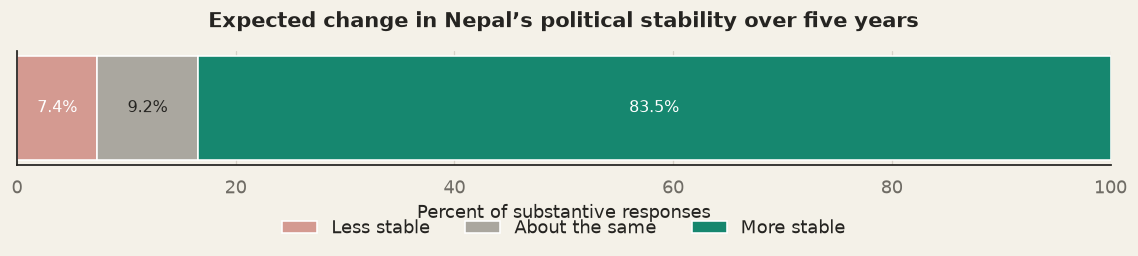

In [40]:
future_stability_map = {
    "Much more stable": "More stable",
    "Somewhat more stable": "More stable",
    "About the same": "About the same",
    "Somewhat less stable": "Less stable",
    "Much less stable": "Less stable",
}
future_stability_order = ["More stable", "About the same", "Less stable"]

future_stability = df["q3_5"].map(future_stability_map)
future_stability_counts = future_stability.value_counts().reindex(
    future_stability_order, fill_value=0
)
future_stability_percent = (
    future_stability_counts / future_stability_counts.sum() * 100
)
future_stability_table = pd.DataFrame(
    {
        "Frequency": future_stability_counts,
        "Percent": future_stability_percent.round(1),
    }
)
future_stability_table.index.name = "Expected stability in five years"

future_stability_audit = {
    "Substantive N": int(future_stability.notna().sum()),
    "Non-substantive N": int(future_stability.isna().sum()),
}

display(future_stability_table)

plot_order = ["Less stable", "About the same", "More stable"]
plot_colors = ["#D49A91", REPORT_LIGHT_GREY, REPORT_TEAL]

fig, ax = plt.subplots(figsize=(10, 2.7))
left = 0
for category, color in zip(plot_order, plot_colors):
    value = float(future_stability_percent[category])
    ax.barh([0], [value], left=left, color=color, height=0.48, label=category)
    if value >= 5:
        text_color = "white" if category in {"Less stable", "More stable"} else REPORT_INK
        ax.text(left + value / 2, 0, f"{value:.1f}%", ha="center", va="center", color=text_color, fontsize=10)
    left += value

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Percent of substantive responses")
report_title(ax, "Expected change in Nepal’s political stability over five years")
report_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.34), ncol=3, frameon=False)
plt.tight_layout()
plt.show()


In [41]:
more_stable_pct = future_stability_percent["More stable"]
same_stability_pct = future_stability_percent["About the same"]
less_stable_pct = future_stability_percent["Less stable"]

display(HTML(f''' 
<div class="interpretation">
<strong>Interpretation.</strong> A large majority of substantive respondents ({more_stable_pct:.1f}%) expected Nepal to be more stable in five years. Only {same_stability_pct:.1f}% expected stability to remain about the same and {less_stable_pct:.1f}% expected the country to become less stable. This is evidence of optimism about the <em>direction</em> of change; because the question asks respondents to compare the future with the present, it should not be read as an absolute rating of future stability.
</div>
'''))


### 5.2 Expectations of government change


,Likely (%),Don't know (%),Unlikely (%)
Expected political change,,,
Government change within one year,18.4,46.1,35.5
Government change before next federal election,23.8,31.0,45.1
Major political event within five years,41.3,12.2,46.5
New political force within five years,41.1,20.7,38.2


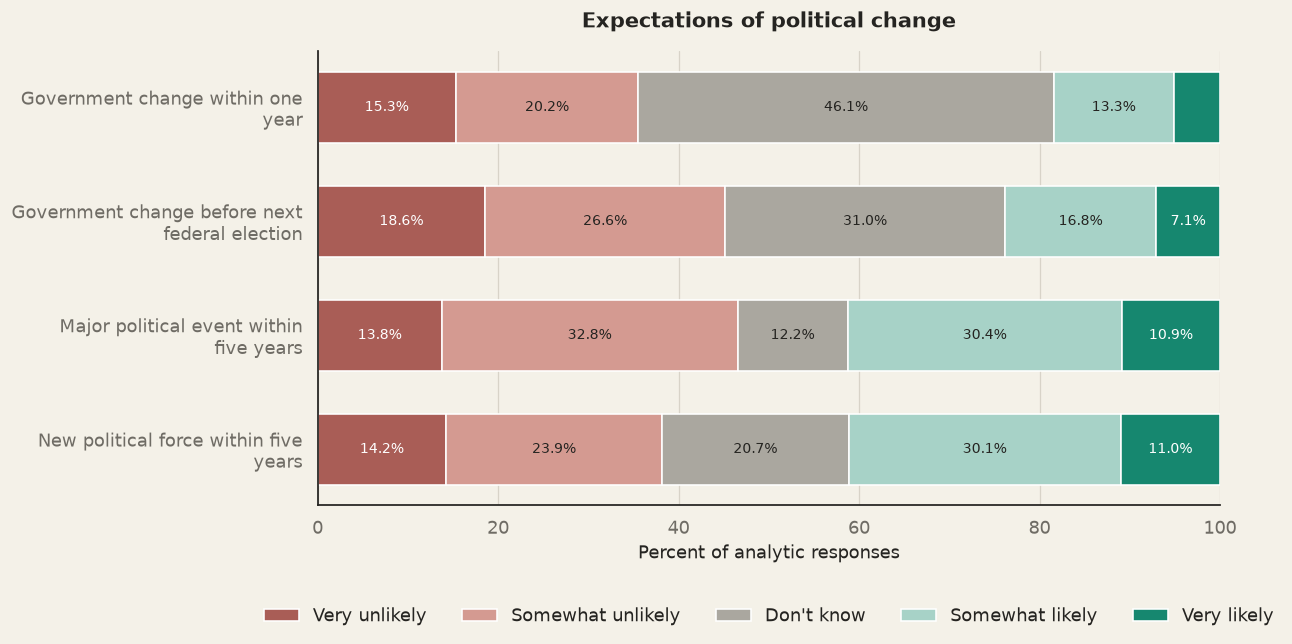

In [42]:
political_change_labels = {
    "q3_6": "Government change within one year",
    "q3_7": "Government change before next federal election",
    "q3_8": "Major political event within five years",
    "q3_9": "New political force within five years",
}
political_change_aliases = {
    "Very Unlikely": "Very unlikely",
    "Somewhat Unlikely": "Somewhat unlikely",
    "Donot Know": "Don't know",
    "Don't Know": "Don't know",
    "Somewhat Likely": "Somewhat likely",
    "Very Likely": "Very likely",
}
political_change_order = [
    "Very unlikely",
    "Somewhat unlikely",
    "Don't know",
    "Somewhat likely",
    "Very likely",
]

political_change_detail = pd.DataFrame(index=political_change_labels.values())
political_change_summary = pd.DataFrame(index=political_change_labels.values())
political_change_audit = {}

for variable, label in political_change_labels.items():
    cleaned = df[variable].map(political_change_aliases)
    cleaned = cleaned.where(cleaned.isin(political_change_order))
    counts = cleaned.value_counts().reindex(political_change_order, fill_value=0)
    analytic_n = int(counts.sum())
    percentages = counts / analytic_n * 100
    political_change_detail.loc[label, political_change_order] = percentages
    political_change_summary.loc[label, "Likely (%)"] = (
        percentages["Somewhat likely"] + percentages["Very likely"]
    )
    political_change_summary.loc[label, "Don't know (%)"] = percentages["Don't know"]
    political_change_summary.loc[label, "Unlikely (%)"] = (
        percentages["Very unlikely"] + percentages["Somewhat unlikely"]
    )
    political_change_audit[variable] = {
        "Analytic N": analytic_n,
        "Excluded N": int(len(df) - analytic_n),
        "Don't know N": int(counts["Don't know"]),
    }

political_change_summary.index.name = "Expected political change"
display(political_change_summary.round(1))

change_colors = {
    "Very unlikely": "#A95D56",
    "Somewhat unlikely": "#D49A91",
    "Don't know": REPORT_LIGHT_GREY,
    "Somewhat likely": REPORT_TEAL_LIGHT,
    "Very likely": REPORT_TEAL,
}

fig, ax = plt.subplots(figsize=(11, 5.8))
y_positions = np.arange(len(political_change_detail))
left = np.zeros(len(political_change_detail))

for category in political_change_order:
    values = political_change_detail[category].astype(float).to_numpy()
    ax.barh(
        y_positions,
        values,
        left=left,
        color=change_colors[category],
        height=0.62,
        label=category,
    )
    for row, value in enumerate(values):
        if value >= 7:
            text_color = "white" if category in {"Very unlikely", "Very likely"} else REPORT_INK
            ax.text(left[row] + value / 2, row, f"{value:.1f}%", ha="center", va="center", color=text_color, fontsize=9)
    left += values

ax.set_xlim(0, 100)
ax.set_yticks(y_positions)
ax.set_yticklabels([textwrap.fill(label, 32) for label in political_change_detail.index])
ax.invert_yaxis()
ax.set_xlabel("Percent of analytic responses")
report_title(ax, "Expectations of political change")
report_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19), ncol=5, frameon=False)
plt.tight_layout()
plt.show()


In [43]:
one_year = political_change_summary.loc["Government change within one year"]
pre_election = political_change_summary.loc[
    "Government change before next federal election"
]

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Expectations of government change are marked by uncertainty, especially in the immediate term. For change within one year, {one_year["Don't know (%)"]:.1f}% answered “don’t know,” compared with {one_year["Likely (%)"]:.1f}% who considered it likely and {one_year["Unlikely (%)"]:.1f}% who considered it unlikely. Looking ahead to the next federal election, uncertainty fell to {pre_election["Don't know (%)"]:.1f}%, but the share considering government change unlikely ({pre_election["Unlikely (%)"]:.1f}%) still exceeded the share considering it likely ({pre_election["Likely (%)"]:.1f}%).
</div>
'''))


### 5.3 Expectations of broader political change


In [44]:
major_event = political_change_summary.loc["Major political event within five years"]
new_force = political_change_summary.loc["New political force within five years"]

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Students were divided about whether a major political event would occur within five years: {major_event["Likely (%)"]:.1f}% considered it likely and {major_event["Unlikely (%)"]:.1f}% considered it unlikely, while {major_event["Don't know (%)"]:.1f}% were uncertain. Expectations of a new political force were somewhat more open: {new_force["Likely (%)"]:.1f}% considered its emergence likely, compared with {new_force["Unlikely (%)"]:.1f}% who considered it unlikely and {new_force["Don't know (%)"]:.1f}% who did not know. The results suggest no settled consensus about the form that future political change will take.
</div>
'''))


### 5.4 Interpretation and transition


In [45]:
display(HTML('''
<div class="interpretation">
<strong>Overall reading.</strong> The findings reveal a distinction between optimism about Nepal’s future direction and confidence about the political pathway leading there. Students may believe Nepal will become more stable without being certain about whether government turnover, a major political event, or a new political force will produce that outcome. These descriptive patterns should not be interpreted as evidence that the Gen-Z movement caused the expectations reported here.
</div>
'''))


## 6. Risks to future stability and sources of hope

The expectation that Nepal will become more stable does not imply that students see the path ahead as free of obstacles. This component examines the risks they associate with Nepal’s future stability and the developments from which they derive hope.


### 6.1 Perceived risks to Nepal’s future stability


,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Perceived risk,,,
Corruption,96.0,2.2,1.8
Unemployment and limited economic opportunities,94.6,3.2,2.2
Lack of accountability,94.1,4.3,1.6
Rising cost of living,88.1,7.5,4.3
Ethnic or religious conflict,88.0,6.7,5.3
Political exclusion,87.4,9.8,2.8
Social-media misinformation,84.1,11.0,4.9
Foreign or external influence,79.7,13.9,6.4


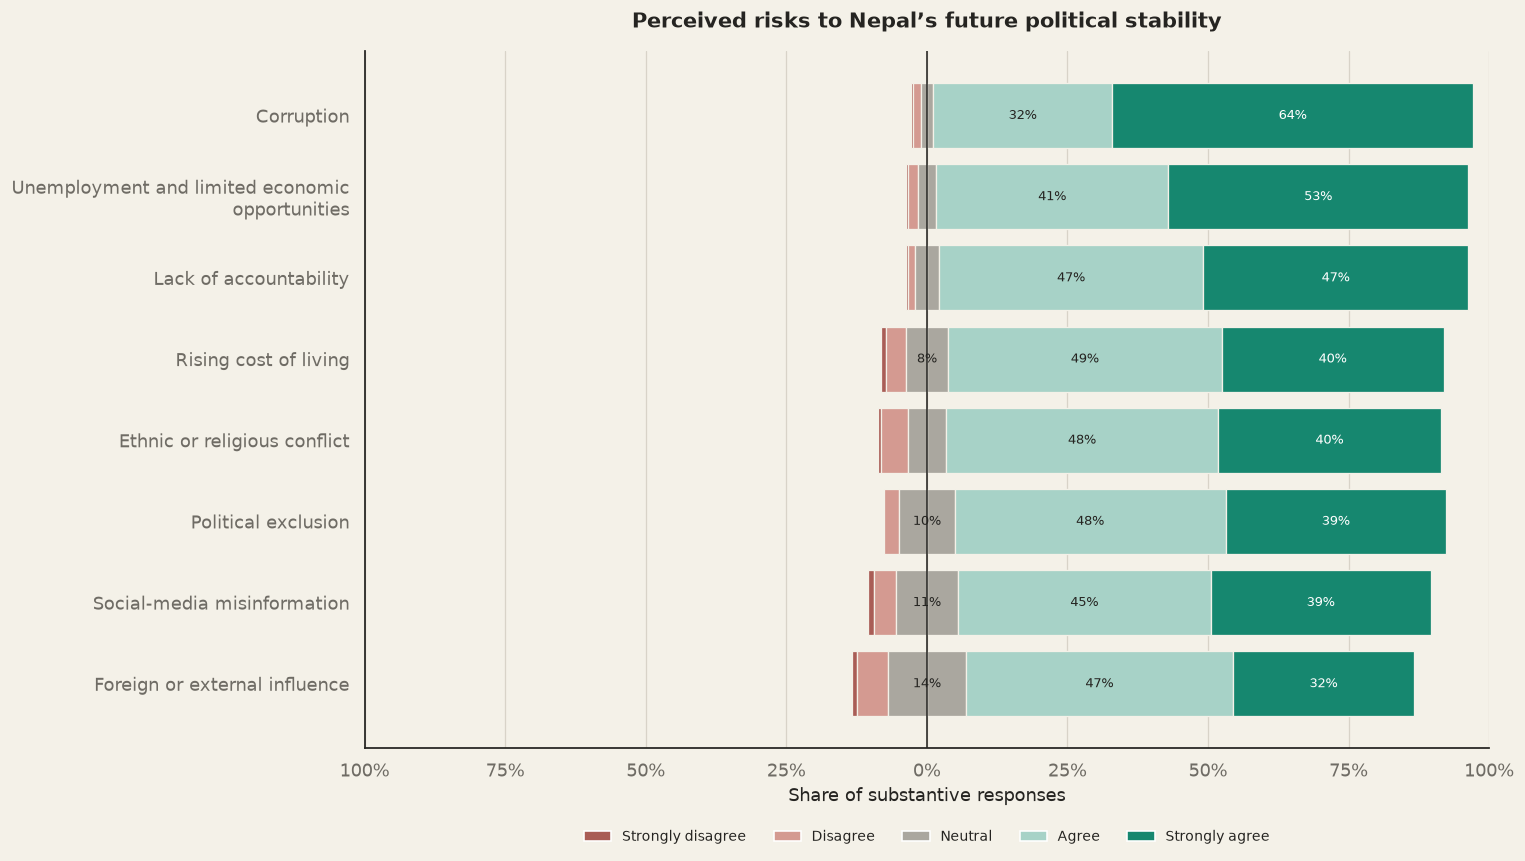

In [46]:
future_risk_labels = {
    "q3_10_11": "Corruption",
    "q3_10_11_001": "Lack of accountability",
    "q3_10_12": "Unemployment and limited economic opportunities",
    "q3_10_13": "Political exclusion",
    "q3_10_14": "Rising cost of living",
    "q3_10_15": "Social-media misinformation",
    "q3_10_16": "Foreign or external influence",
    "q3_10_17": "Ethnic or religious conflict",
}

risk_summary, risk_detail, risk_audit = prepare_likert_battery(
    df, future_risk_labels
)
risk_summary.index.name = "Perceived risk"
risk_detail.index.name = "Perceived risk"

display(risk_summary.round(1))
plot_diverging_likert(
    risk_detail,
    "Perceived risks to Nepal’s future political stability",
)


In [47]:
risk_agreement = risk_summary["Agree or strongly agree (%)"]
top_risks = risk_agreement.nlargest(3)
lowest_risk = risk_agreement.idxmin()

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Students expressed high levels of concern across the entire set of risks. Corruption received the broadest agreement ({top_risks.iloc[0]:.1f}%), followed by unemployment and limited economic opportunities ({risk_agreement["Unemployment and limited economic opportunities"]:.1f}%) and lack of accountability ({risk_agreement["Lack of accountability"]:.1f}%). Even {lowest_risk.lower()}, the lowest-ranked item, was identified as a risk by {risk_agreement[lowest_risk]:.1f}% of substantive respondents. The pattern suggests that students understand instability as multidimensional, while placing particular emphasis on governance failures and economic insecurity.
</div>
'''))


### 6.2 Sources of hope for Nepal


,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Source of hope,,,
Youth political participation,82.2,14.3,3.5
Governance and anti-corruption reforms,69.8,18.7,11.5
Improved democracy,67.1,23.3,9.6
Economic and employment prospects,58.4,22.0,19.6


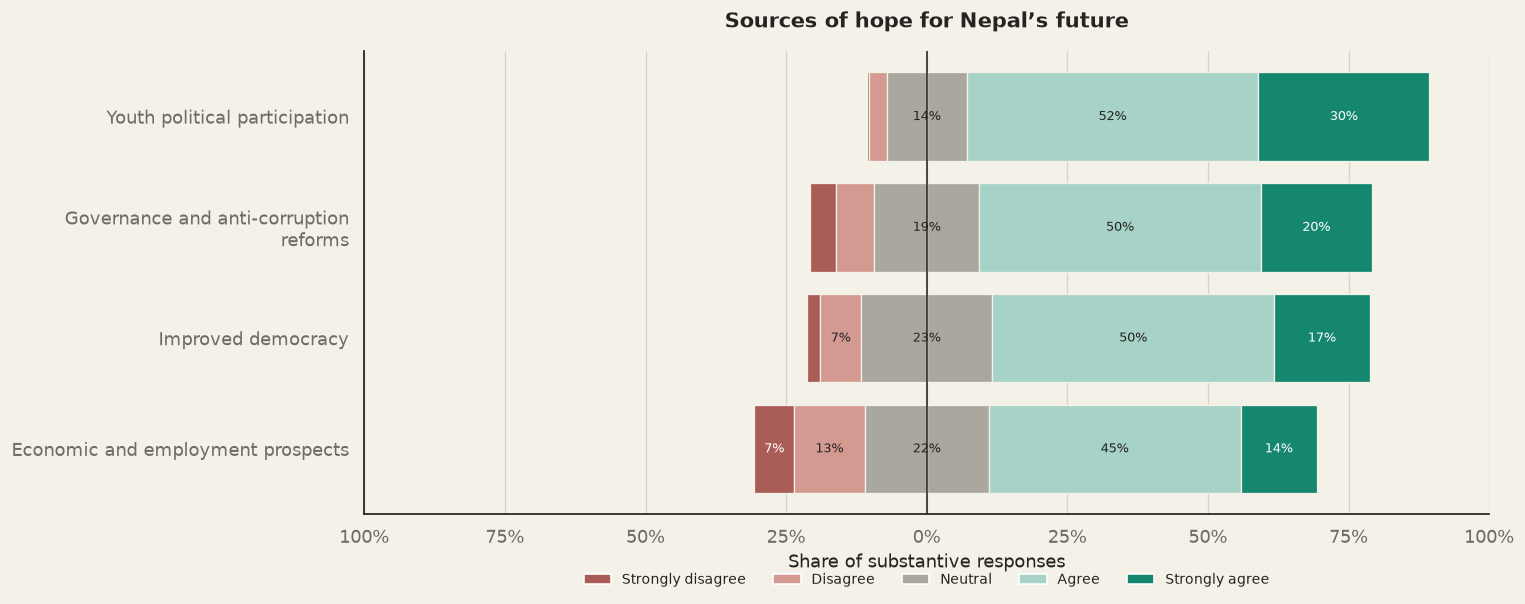

In [48]:
hope_labels = {
    "q3_11_1": "Governance and anti-corruption reforms",
    "q3_11_2": "Youth political participation",
    "q3_11_3": "Improved democracy",
    "q3_11_4": "Economic and employment prospects",
}

hope_summary, hope_detail, hope_audit = prepare_likert_battery(
    df, hope_labels
)
hope_summary.index.name = "Source of hope"
hope_detail.index.name = "Source of hope"

display(hope_summary.round(1))
plot_diverging_likert(
    hope_detail,
    "Sources of hope for Nepal’s future",
)


In [49]:
hope_agreement = hope_summary["Agree or strongly agree (%)"]
youth_hope = hope_agreement["Youth political participation"]
governance_hope = hope_agreement["Governance and anti-corruption reforms"]
democracy_hope = hope_agreement["Improved democracy"]
economic_hope = hope_agreement["Economic and employment prospects"]

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Youth political participation was the most widely shared source of hope ({youth_hope:.1f}%), followed by governance and anti-corruption reforms ({governance_hope:.1f}%) and improved democracy ({democracy_hope:.1f}%). Economic and employment prospects ranked last, although a majority still regarded them as a source of hope ({economic_hope:.1f}%). In the context of the preceding analysis, the prominence of youth participation is consistent with students assigning political significance to greater youth engagement. It does not, however, establish that the Gen-Z movement caused these expectations.
</div>
'''))


### 6.3 Bringing risks and hope together


In [50]:
display(HTML('''
<div class="interpretation">
<strong>Overall reading.</strong> Students’ optimism appears conditional rather than unconditional. They expect Nepal to move towards greater stability while continuing to identify corruption, weak accountability, and economic insecurity as major threats. At the same time, their hope rests more strongly on youth participation and institutional reform than on economic prospects alone. Together, these findings suggest that students envisage a more stable future, but believe that reaching it will require political engagement and meaningful governance reform.
</div>
'''))


The Nepal-focused findings now provide the bridge to Theme 3. The next chapter examines whether students plan to build their futures in Nepal or abroad, then situates those aspirations within their view of youth politics and stability across South Asia.

# Theme 3 · Youth aspirations, migration intentions, and the South Asian outlook

This chapter moves from political attitudes to the choices students imagine for their own futures. It begins with family migration experience and the intention to go abroad or remain in Nepal, distinguishes study, work, and enterprise plans, and then asks whether those intentions vary with political expectations. The final components widen the frame to youth protest and political stability across South Asia.

All percentages use the relevant valid-response base. Conditional follow-up questions are reported only for the respondents who received them. “Prefer not to say,” “Don’t know,” system missing values, and the residual `-99` code are excluded only where the text explicitly refers to substantive responses; undecided migration intentions remain visible in descriptive tables. Associations are descriptive, and the cross-sectional survey cannot establish causality.

## 1. Family migration context

,Frequency,Percent
Close family member has lived abroad,,
Yes,355,42.5
No,481,57.5


,Frequency,Percent among those with family abroad
Family member returned permanently,,
Yes,57,16.1
No,297,83.7
Not Sure,1,0.3


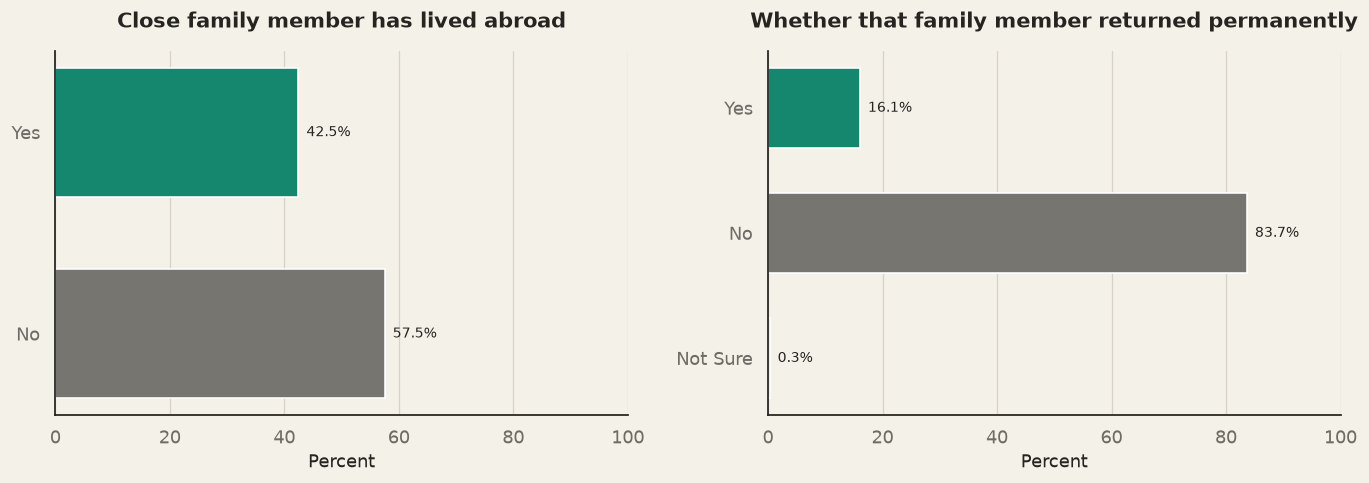

In [51]:
family_order = ["Yes", "No"]
family_abroad = df["family_abroad"].astype("string").str.strip()
family_counts = family_abroad.value_counts().reindex(family_order, fill_value=0)
family_pct = family_counts.div(family_counts.sum()).mul(100)

return_raw = df["family_returned"].astype("string").str.strip()
return_order = ["Yes", "No", "Not Sure"]
return_counts = return_raw.value_counts().reindex(return_order, fill_value=0)
return_pct = return_counts.div(return_counts.sum()).mul(100)

family_table = pd.DataFrame({
    "Frequency": family_counts.astype(int),
    "Percent": family_pct,
})
family_table.index.name = "Close family member has lived abroad"

return_table = pd.DataFrame({
    "Frequency": return_counts.astype(int),
    "Percent among those with family abroad": return_pct,
})
return_table.index.name = "Family member returned permanently"

display(HTML("<h4>Family experience abroad</h4>"))
display(family_table.round(1))
display(HTML("<h4>Permanent return among families with experience abroad</h4>"))
display(return_table.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))
for ax, values, title, colors in [
    (
        axes[0], family_pct,
        "Close family member has lived abroad",
        [REPORT_TEAL, REPORT_GREY],
    ),
    (
        axes[1], return_pct,
        "Whether that family member returned permanently",
        [REPORT_TEAL, REPORT_GREY, REPORT_LIGHT_GREY],
    ),
]:
    bars = ax.barh(values.index, values.values, color=colors, height=0.64)
    ax.bar_label(
        bars,
        labels=[f"{value:.1f}%" for value in values],
        padding=5,
        fontsize=9,
        color=REPORT_INK,
    )
    ax.set_xlim(0, 100)
    ax.set_xlabel("Percent")
    ax.set_ylabel("")
    ax.invert_yaxis()
    report_title(ax, title)
    report_axes(ax, grid_axis="x")
plt.tight_layout(w_pad=2.0)
plt.show()

In [52]:
family_exposure_share = float(family_pct["Yes"])
family_return_share = float(return_pct["Yes"])

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Family migration is common but not universal in this student sample. A close family member had lived or was living abroad for <strong>{family_exposure_share:.1f}%</strong> of respondents. Among those with that experience, only <strong>{family_return_share:.1f}%</strong> reported that the family member had returned permanently. Migration aspirations are therefore being formed in a context where many students have a direct family connection to living abroad, while permanent return is relatively uncommon.
</div>
'''))

## 2. Intention to go abroad or remain in Nepal

,Frequency,Percent
Current plan,,
Go Abroad,309,37.0
Stay in Nepal,421,50.4
Don't Know,106,12.7


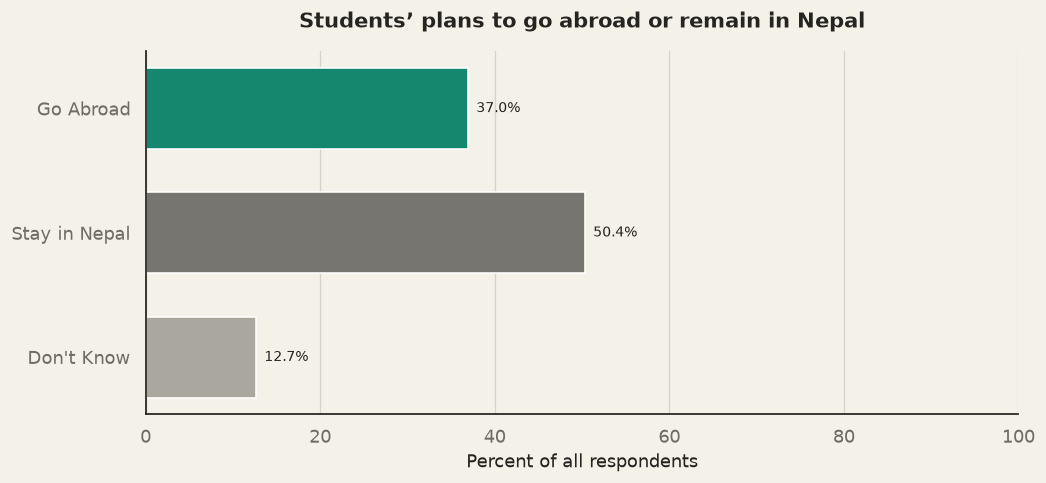

In [53]:
migration_order = ["Go Abroad", "Stay in Nepal", "Don't Know"]
migration_intention = df["migration_plan"].astype("string").str.strip()
migration_counts = migration_intention.value_counts().reindex(
    migration_order, fill_value=0
)
migration_pct = migration_counts.div(migration_counts.sum()).mul(100)

migration_table = pd.DataFrame({
    "Frequency": migration_counts.astype(int),
    "Percent": migration_pct,
})
migration_table.index.name = "Current plan"
display(migration_table.round(1))

fig, ax = plt.subplots(figsize=(9.2, 4.3))
bars = ax.barh(
    migration_pct.index,
    migration_pct.values,
    color=[REPORT_TEAL, REPORT_GREY, REPORT_LIGHT_GREY],
    height=0.65,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in migration_pct],
    padding=5,
    fontsize=9,
    color=REPORT_INK,
)
ax.set_xlim(0, 100)
ax.set_xlabel("Percent of all respondents")
ax.set_ylabel("")
ax.invert_yaxis()
report_title(ax, "Students’ plans to go abroad or remain in Nepal")
report_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Staying in Nepal was the single most common plan, reported by <strong>{migration_pct["Stay in Nepal"]:.1f}%</strong> of respondents. A substantial <strong>{migration_pct["Go Abroad"]:.1f}%</strong> planned to go abroad, while <strong>{migration_pct["Don't Know"]:.1f}%</strong> remained undecided. The result is not a simple majority–minority contrast: almost half of the sample either anticipated leaving or had not settled on remaining in Nepal.
</div>
'''))

### 2.1 How migration intention varies across the sample

Outcome: n (row %),Go Abroad,Stay in Nepal,Don't Know,Total n
Family abroad,,,,
Yes,169 (47.6%),141 (39.7%),45 (12.7%),355
No,140 (29.1%),280 (58.2%),61 (12.7%),481


Outcome: n (row %),Go Abroad,Stay in Nepal,Don't Know,Total n
Gender,,,,
Male,181 (40.1%),210 (46.6%),60 (13.3%),451
Female,128 (33.2%),211 (54.8%),46 (11.9%),385


Outcome: n (row %),Go Abroad,Stay in Nepal,Don't Know,Total n
Place lived most of life,,,,
Urban,216 (44.4%),200 (41.1%),71 (14.6%),487
Rural,93 (26.6%),221 (63.3%),35 (10.0%),349


Outcome: n (row %),Go Abroad,Stay in Nepal,Don't Know,Total n
Age cohort,,,,
18–21,123 (32.7%),198 (52.7%),55 (14.6%),376
22–25,159 (43.2%),163 (44.3%),46 (12.5%),368
26–29,26 (33.3%),47 (60.3%),5 (6.4%),78
30–35,1 (7.1%),13 (92.9%),0 (0.0%),14


Outcome: n (row %),Go Abroad,Stay in Nepal,Don't Know,Total n
Current education stage,,,,
Bachelor’s,287 (38.6%),355 (47.8%),101 (13.6%),743
Master’s,22 (23.9%),65 (70.7%),5 (5.4%),92


,Valid N,Cramér’s V,p-value
Characteristic,,,
Family abroad,836,2.0e-01,0.0e+00
Gender,836,8.3e-02,5.6e-02
Place lived most of life,836,2.2e-01,0.0e+00
Age cohort,836,1.2e-01,5.0e-04
Current education stage,835,1.4e-01,2.0e-04


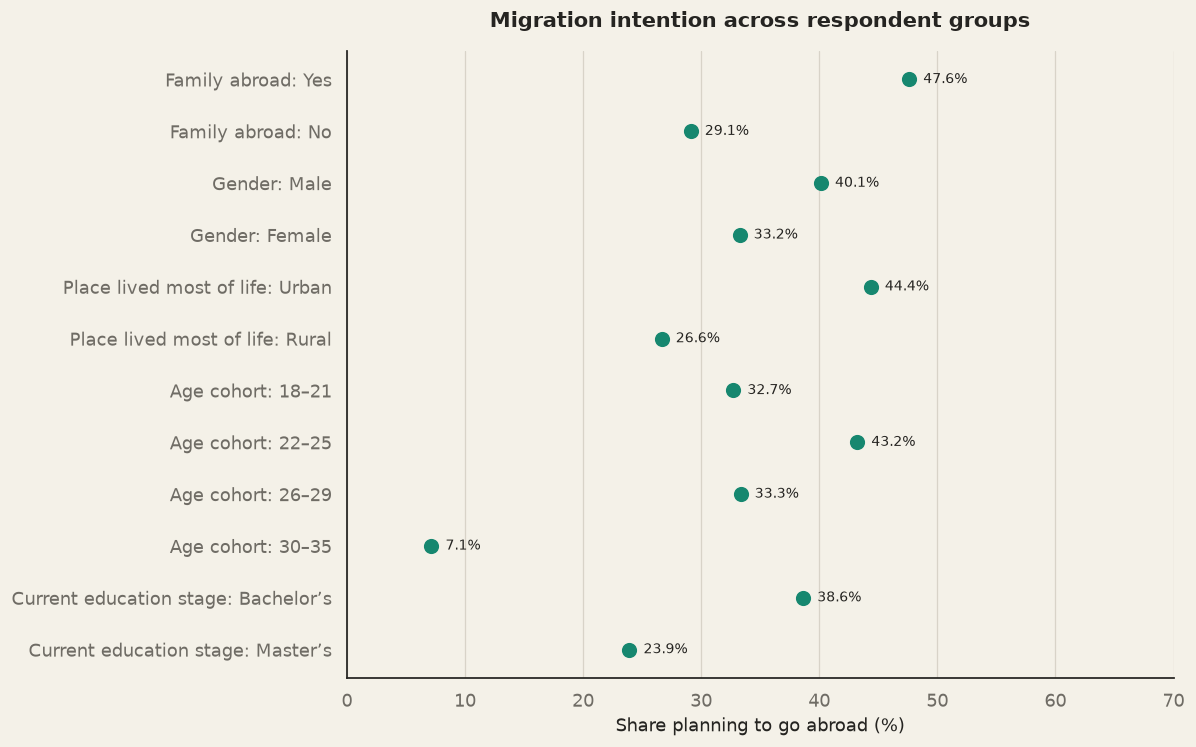

In [54]:
education_stage = df["education"].astype("string").str.strip().map(
    lambda value: (
        "Bachelor’s" if str(value).startswith("Bachelors")
        else "Master’s" if str(value).startswith("Masters")
        else pd.NA
    )
)

migration_groups = {
    "Family abroad": (
        family_abroad.where(family_abroad.isin(family_order)),
        ["Yes", "No"],
    ),
    "Gender": (
        df["gender"].astype("string").str.strip(),
        ["Male", "Female"],
    ),
    "Place lived most of life": (
        df["life_place"].astype("string").str.strip(),
        ["Urban", "Rural"],
    ),
    "Age cohort": (df["age_cohort"], age_order),
    "Current education stage": (
        education_stage,
        ["Bachelor’s", "Master’s"],
    ),
}

migration_cross_results = {}
plot_rows = []
association_rows = []

for group_name, (group_values, group_order) in migration_groups.items():
    result = bridge_crosstab(
        group_values,
        migration_intention.where(migration_intention.isin(migration_order)),
        group_order,
        migration_order,
        group_name,
    )
    migration_cross_results[group_name] = result
    display(HTML(f"<h4>{group_name}</h4>"))
    display(result[2])
    for category in result[1].index:
        plot_rows.append({
            "Characteristic": f"{group_name}: {category}",
            "Plan to go abroad (%)": result[1].loc[category, "Go Abroad"],
        })
    association_rows.append({
        "Characteristic": group_name,
        "Valid N": result[3]["n"],
        "Cramér’s V": result[3]["v"],
        "p-value": result[3]["p"],
    })

association_table = pd.DataFrame(association_rows).set_index("Characteristic")
display(HTML("<h4>Strength of the descriptive associations</h4>"))
display(association_table.round({"Cramér’s V": 3, "p-value": 4}))

migration_group_plot = pd.DataFrame(plot_rows).iloc[::-1]
fig, ax = plt.subplots(figsize=(10.5, 6.6))
ax.scatter(
    migration_group_plot["Plan to go abroad (%)"],
    migration_group_plot["Characteristic"],
    s=72,
    color=REPORT_TEAL,
    zorder=3,
)
for y_position, value in enumerate(
    migration_group_plot["Plan to go abroad (%)"]
):
    ax.text(
        value + 1.2,
        y_position,
        f"{value:.1f}%",
        va="center",
        fontsize=8.7,
        color=REPORT_INK,
    )
ax.set_xlim(0, max(70, migration_group_plot["Plan to go abroad (%)"].max() + 10))
ax.set_xlabel("Share planning to go abroad (%)")
ax.set_ylabel("")
report_title(ax, "Migration intention across respondent groups")
report_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

In [55]:
family_go = migration_cross_results["Family abroad"][1]["Go Abroad"]
urban_rural_go = migration_cross_results["Place lived most of life"][1][
    "Go Abroad"
]
education_go = migration_cross_results["Current education stage"][1][
    "Go Abroad"
]

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Family exposure produces one of the clearest descriptive contrasts: <strong>{family_go["Yes"]:.1f}%</strong> of respondents with a close family member abroad planned to leave, compared with <strong>{family_go["No"]:.1f}%</strong> among those without that experience. Urban-background students also reported plans to leave more often than rural-background students (<strong>{urban_rural_go["Urban"]:.1f}%</strong> versus <strong>{urban_rural_go["Rural"]:.1f}%</strong>). The education-stage contrast is also substantial: <strong>{education_go["Bachelor’s"]:.1f}%</strong> of bachelor’s students and <strong>{education_go["Master’s"]:.1f}%</strong> of master’s students planned to go abroad. These are unadjusted relationships; the probit model later in the chapter examines them jointly.
</div>
'''))

## 3. What students plan to do

### 3.1 Plans among students intending to go abroad

,Frequency,Percent among respondents planning to go abroad
Purpose,,
Study,61,19.7
Work,68,22.0
Study and Work,172,55.7
Travel,8,2.6


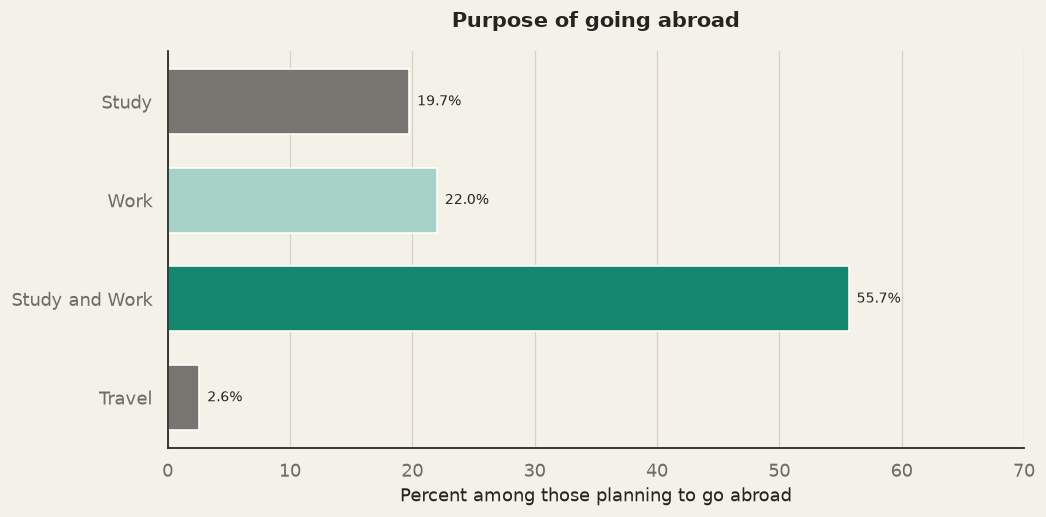

In [56]:
abroad_order = ["Study", "Work", "Study and Work", "Travel"]
abroad_plan = df["abroad_purpose"].astype("string").str.strip()
abroad_counts = abroad_plan.value_counts().reindex(abroad_order, fill_value=0)
abroad_pct = abroad_counts.div(abroad_counts.sum()).mul(100)
abroad_table = pd.DataFrame({
    "Frequency": abroad_counts.astype(int),
    "Percent among respondents planning to go abroad": abroad_pct,
})
abroad_table.index.name = "Purpose"
display(abroad_table.round(1))

fig, ax = plt.subplots(figsize=(9.2, 4.6))
bars = ax.barh(
    abroad_pct.index,
    abroad_pct.values,
    color=highlight_bar_colors(abroad_pct.values),
    height=0.66,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in abroad_pct],
    padding=5,
    fontsize=9,
    color=REPORT_INK,
)
ax.set_xlim(0, max(70, abroad_pct.max() + 10))
ax.set_xlabel("Percent among those planning to go abroad")
ax.set_ylabel("")
ax.invert_yaxis()
report_title(ax, "Purpose of going abroad")
report_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

### 3.2 Plans among students intending to remain in Nepal

,Frequency,Percent among respondents planning to stay
Plan in Nepal,,
Study further,138,32.8
Seek a job,6,1.4
Start a business,14,3.3
Study and seek a job,224,53.2
Study and start a business,35,8.3
Seek a job and start a business,4,1.0


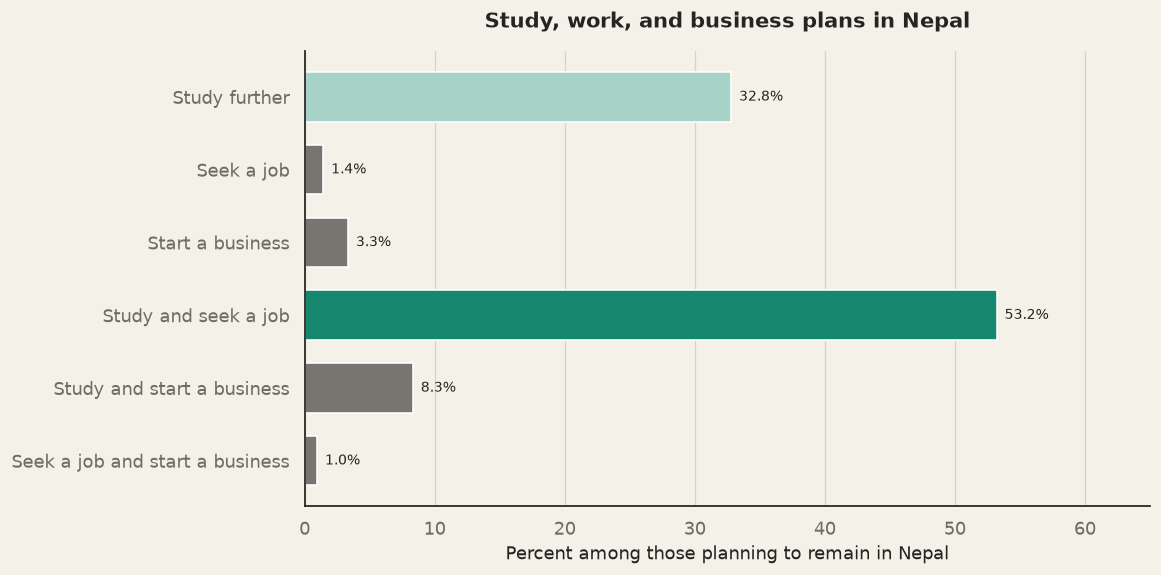

In [57]:
nepal_order = [
    "Study Further",
    "Seek a Job",
    "Start a business",
    "Study and Seek a job",
    "Study and Start a business",
    "Seek a job and Start a business",
]
nepal_labels = {
    "Study Further": "Study further",
    "Seek a Job": "Seek a job",
    "Start a business": "Start a business",
    "Study and Seek a job": "Study and seek a job",
    "Study and Start a business": "Study and start a business",
    "Seek a job and Start a business": "Seek a job and start a business",
}
nepal_plan = df["nepal_plan"].astype("string").str.strip()
nepal_counts = nepal_plan.value_counts().reindex(nepal_order, fill_value=0)
nepal_counts.index = [nepal_labels[value] for value in nepal_counts.index]
nepal_pct = nepal_counts.div(nepal_counts.sum()).mul(100)
nepal_table = pd.DataFrame({
    "Frequency": nepal_counts.astype(int),
    "Percent among respondents planning to stay": nepal_pct,
})
nepal_table.index.name = "Plan in Nepal"
display(nepal_table.round(1))

fig, ax = plt.subplots(figsize=(10.2, 5.1))
bars = ax.barh(
    nepal_pct.index,
    nepal_pct.values,
    color=highlight_bar_colors(nepal_pct.values),
    height=0.68,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in nepal_pct],
    padding=5,
    fontsize=9,
    color=REPORT_INK,
)
ax.set_xlim(0, max(65, nepal_pct.max() + 10))
ax.set_xlabel("Percent among those planning to remain in Nepal")
ax.set_ylabel("")
ax.invert_yaxis()
report_title(ax, "Study, work, and business plans in Nepal")
report_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

In [58]:
display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Among prospective migrants, combining study and work was dominant (<strong>{abroad_pct["Study and Work"]:.1f}%</strong>), while work alone and study alone were much less common. Among those planning to remain in Nepal, the leading aspiration was to combine further study with seeking a job (<strong>{nepal_pct["Study and seek a job"]:.1f}%</strong>), followed by further study alone (<strong>{nepal_pct["Study further"]:.1f}%</strong>). Business-oriented plans formed a smaller share. Both groups therefore link their immediate future strongly to education and employment, although they differ on whether those opportunities are expected inside or outside Nepal.
</div>
'''))

## 4. Migration intention and Nepal’s political outlook

Outcome: n (row %),Go Abroad,Stay in Nepal,Don't Know,Total n
Expected stability of Nepal in five years,,,,
More stable,221 (36.8%),312 (51.9%),68 (11.3%),601
About the same,23 (34.8%),31 (47.0%),12 (18.2%),66
Less stable,23 (43.4%),26 (49.1%),4 (7.5%),53


Outcome: n (row %),Go Abroad,Stay in Nepal,Don't Know,Total n
Government represents youth interests,,,,
Agree,226 (35.0%),338 (52.3%),82 (12.7%),646
Neutral,59 (43.4%),62 (45.6%),15 (11.0%),136
Disagree,20 (42.6%),19 (40.4%),8 (17.0%),47


,Valid N,Cramér’s V,p-value
Political outlook measure,,,
Expected stability of Nepal in five years,720,5.4e-02,0.4
Government represents youth interests,829,5.8e-02,0.2


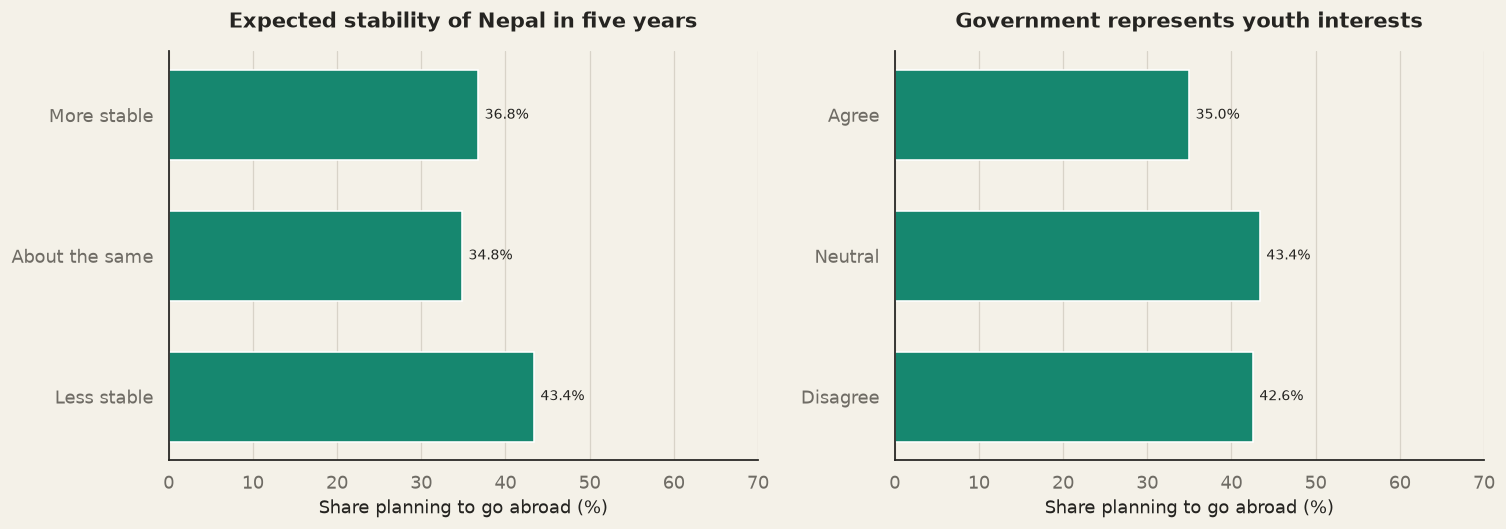

In [59]:
future_stability_group = df["q3_5"].astype("string").str.strip().map({
    "Much more stable": "More stable",
    "Somewhat more stable": "More stable",
    "About the same": "About the same",
    "Somewhat less stable": "Less stable",
    "Much less stable": "Less stable",
})
future_stability_order = ["More stable", "About the same", "Less stable"]

youth_representation_group = df["q4_7"].astype("string").str.strip().map({
    "Strongly Agree": "Agree",
    "Agree": "Agree",
    "Neutral": "Neutral",
    "Disagree": "Disagree",
    "Strongly Disagree": "Disagree",
})
representation_order = ["Agree", "Neutral", "Disagree"]

political_migration_groups = {
    "Expected stability of Nepal in five years": (
        future_stability_group, future_stability_order
    ),
    "Government represents youth interests": (
        youth_representation_group, representation_order
    ),
}

political_migration_results = {}
political_association_rows = []
for group_name, (group_values, group_order) in political_migration_groups.items():
    result = bridge_crosstab(
        group_values,
        migration_intention.where(migration_intention.isin(migration_order)),
        group_order,
        migration_order,
        group_name,
    )
    political_migration_results[group_name] = result
    display(HTML(f"<h4>{group_name}</h4>"))
    display(result[2])
    political_association_rows.append({
        "Political outlook measure": group_name,
        "Valid N": result[3]["n"],
        "Cramér’s V": result[3]["v"],
        "p-value": result[3]["p"],
    })

display(
    pd.DataFrame(political_association_rows)
    .set_index("Political outlook measure")
    .round({"Cramér’s V": 3, "p-value": 4})
)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.7))
for ax, (title, (_, percentages, _, _)) in zip(
    axes, political_migration_results.items()
):
    bars = ax.barh(
        percentages.index.astype(str),
        percentages["Go Abroad"],
        color=REPORT_TEAL,
        height=0.64,
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.1f}%" for value in percentages["Go Abroad"]],
        padding=4,
        fontsize=8.8,
        color=REPORT_INK,
    )
    ax.set_xlim(0, 70)
    ax.set_xlabel("Share planning to go abroad (%)")
    ax.set_ylabel("")
    ax.invert_yaxis()
    report_title(ax, title)
    report_axes(ax, grid_axis="x")
plt.tight_layout(w_pad=2.0)
plt.show()

In [60]:
stability_go = political_migration_results[
    "Expected stability of Nepal in five years"
][1]["Go Abroad"]
representation_go = political_migration_results[
    "Government represents youth interests"
][1]["Go Abroad"]

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Migration plans do not move in a simple linear direction with political optimism. Respondents expecting Nepal to become more stable still reported substantial plans to leave (<strong>{stability_go["More stable"]:.1f}%</strong>), while the corresponding shares were <strong>{stability_go["About the same"]:.1f}%</strong> among those expecting no change and <strong>{stability_go["Less stable"]:.1f}%</strong> among those expecting less stability. Beliefs about whether the government represents youth interests also show only a descriptive association. The later multivariable model tests whether these outlook measures retain an independent relationship after adjustment for background characteristics.
</div>
'''))

## 5. Youth protest as a South Asian phenomenon

### 5.1 Attention to protests elsewhere in Asia

,Frequency,Percent of substantive responses
Attention,,
Very Closely,74,8.9
Somewhat Closely,323,38.7
Not Very Closely,339,40.6
Not at all,99,11.9


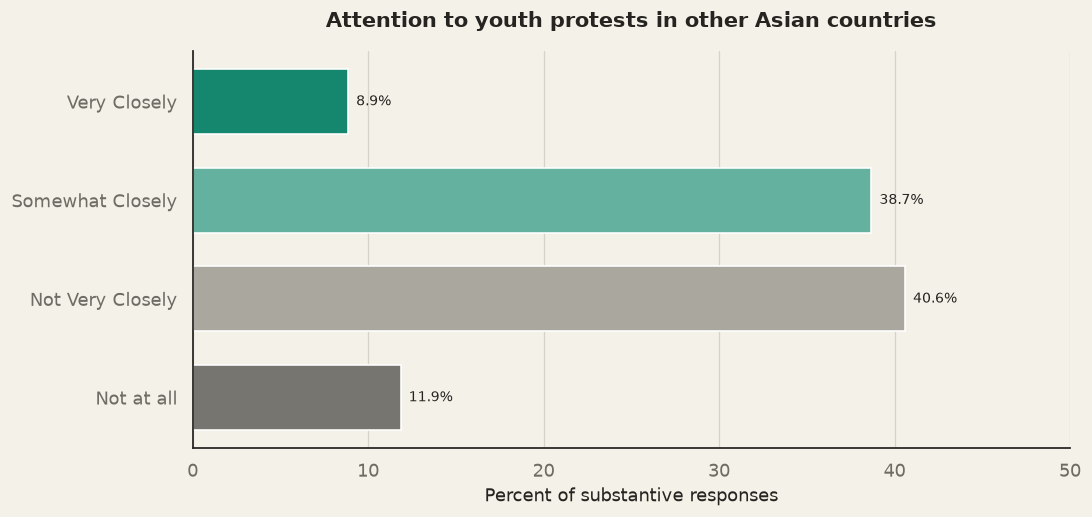

In [61]:
regional_attention_order = [
    "Very Closely", "Somewhat Closely", "Not Very Closely", "Not at all"
]
regional_attention = df["q5_1"].astype("string").str.strip()
regional_attention = regional_attention.where(
    regional_attention.isin(regional_attention_order)
)
regional_attention_counts = regional_attention.value_counts().reindex(
    regional_attention_order, fill_value=0
)
regional_attention_pct = regional_attention_counts.div(
    regional_attention_counts.sum()
).mul(100)
regional_attention_table = pd.DataFrame({
    "Frequency": regional_attention_counts.astype(int),
    "Percent of substantive responses": regional_attention_pct,
})
regional_attention_table.index.name = "Attention"
display(regional_attention_table.round(1))

fig, ax = plt.subplots(figsize=(9.6, 4.6))
bars = ax.barh(
    regional_attention_pct.index,
    regional_attention_pct.values,
    color=[REPORT_TEAL, REPORT_TEAL_MID, REPORT_LIGHT_GREY, REPORT_GREY],
    height=0.66,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in regional_attention_pct],
    padding=5,
    fontsize=9,
    color=REPORT_INK,
)
ax.set_xlim(0, max(50, regional_attention_pct.max() + 8))
ax.set_xlabel("Percent of substantive responses")
ax.set_ylabel("")
ax.invert_yaxis()
report_title(ax, "Attention to youth protests in other Asian countries")
report_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

### 5.2 Perceived protest spillover across countries

,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Proposed cause,,,
Protests in one country encourage protests elsewhere in South Asia,75.8,12.7,11.6


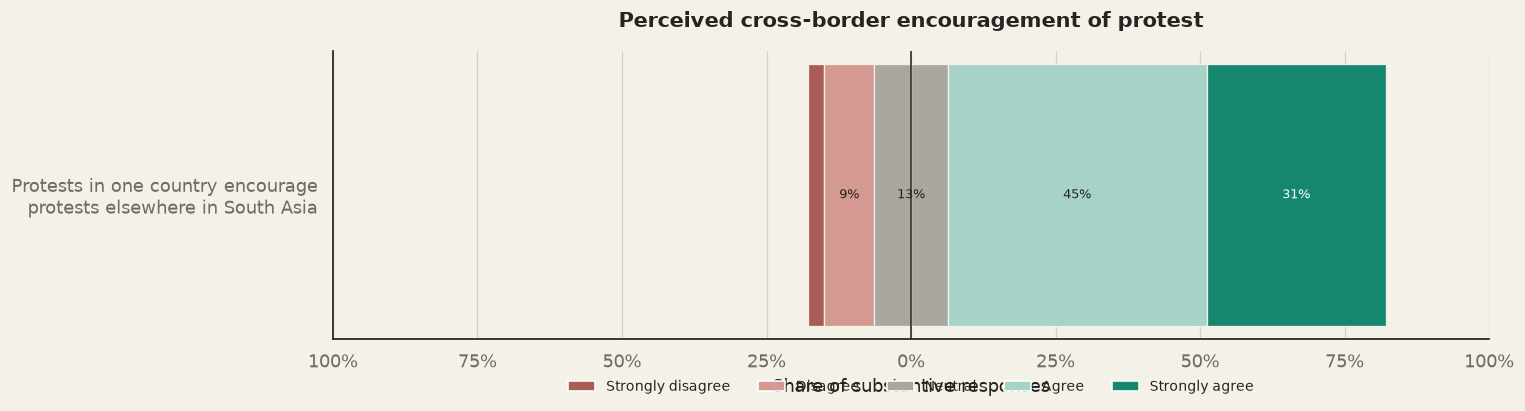

In [62]:
spillover_items = {
    "q5_3": "Protests in one country encourage protests elsewhere in South Asia"
}
spillover_summary, spillover_detail, spillover_audit = prepare_likert_battery(
    df, spillover_items
)
display(spillover_summary.round(1))
plot_diverging_likert(
    spillover_detail,
    "Perceived cross-border encouragement of protest",
)

### 5.3 Perceived causes of youth dissent across South Asia

,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Perceived cause,,,
"Poor governance, corruption, and public services",89.1,7.1,3.9
Unemployment and limited economic opportunities,89.0,7.0,4.0
"Distrust of leaders, parties, and institutions",87.0,10.1,2.9
Nepotism and elite capture,84.2,10.9,4.9
Political exclusion,71.5,18.4,10.1
Foreign or external influence,70.1,18.9,11.0


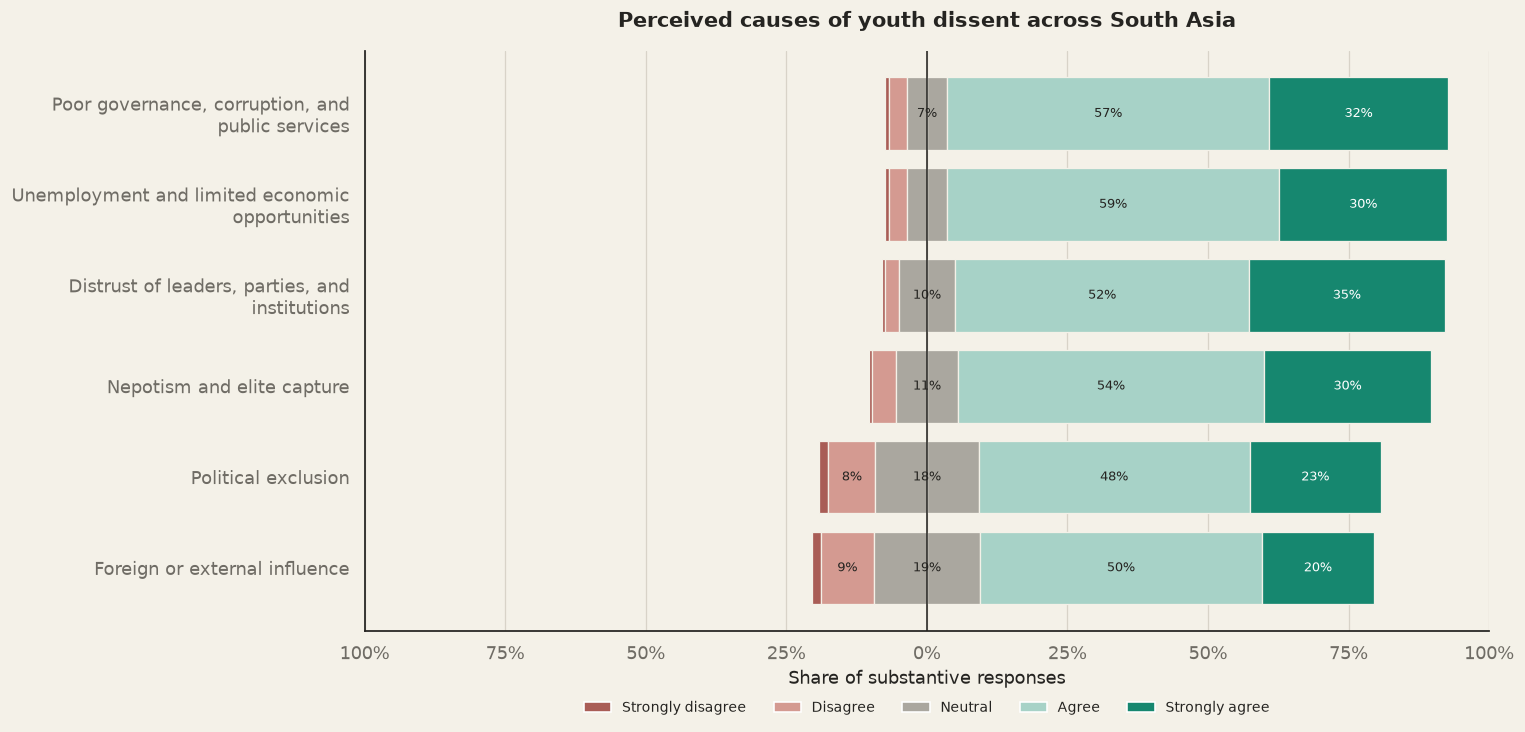

In [63]:
regional_dissent_labels = {
    "q5_2_1": "Poor governance, corruption, and public services",
    "q5_2_2": "Unemployment and limited economic opportunities",
    "q5_2_3": "Distrust of leaders, parties, and institutions",
    "q5_2_4": "Political exclusion",
    "q5_2_5": "Nepotism and elite capture",
    "q5_2_6": "Foreign or external influence",
}
regional_dissent_summary, regional_dissent_detail, regional_dissent_audit = (
    prepare_likert_battery(df, regional_dissent_labels)
)
regional_dissent_summary.index.name = "Perceived cause"
display(regional_dissent_summary.round(1))
plot_diverging_likert(
    regional_dissent_detail,
    "Perceived causes of youth dissent across South Asia",
)

In [64]:
regional_follow_close = float(
    regional_attention_pct[["Very Closely", "Somewhat Closely"]].sum()
)
spillover_agree = float(
    spillover_summary.iloc[0]["Agree or strongly agree (%)"]
)
regional_dissent_top = regional_dissent_summary[
    "Agree or strongly agree (%)"
].nlargest(3)

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> A combined <strong>{regional_follow_close:.1f}%</strong> followed protests in the named Asian countries very or somewhat closely, far below the exceptionally high attention to Nepal’s Gen-Z movement reported in Theme 2. Nevertheless, <strong>{spillover_agree:.1f}%</strong> agreed that protest in one country can encourage protest elsewhere in South Asia. Students most strongly attributed regional youth dissent to {regional_dissent_top.index[0].lower()} (<strong>{regional_dissent_top.iloc[0]:.1f}%</strong>), {regional_dissent_top.index[1].lower()} (<strong>{regional_dissent_top.iloc[1]:.1f}%</strong>), and {regional_dissent_top.index[2].lower()} (<strong>{regional_dissent_top.iloc[2]:.1f}%</strong>). Their regional diagnosis therefore largely echoes the governance and economic concerns identified in Nepal.
</div>
'''))

## 6. Political stability, risks, and sources of hope across South Asia

### 6.1 Current regional stability and five-year optimism

,Frequency,Percent
q5_4,,
Very Stable,23,2.8
Stable,376,45.0
Neutral,184,22.0
Unstable,168,20.1
Very Unstable,18,2.2
Don't Know,67,8.0


,Frequency,Percent
q5_5,,
Very Optimistic,56,6.7
Somewhat Optimistic,527,63.0
Neutral,118,14.1
Somewhat Pessimistic,35,4.2
Very Pessimistic,23,2.8
Don't Know,77,9.2


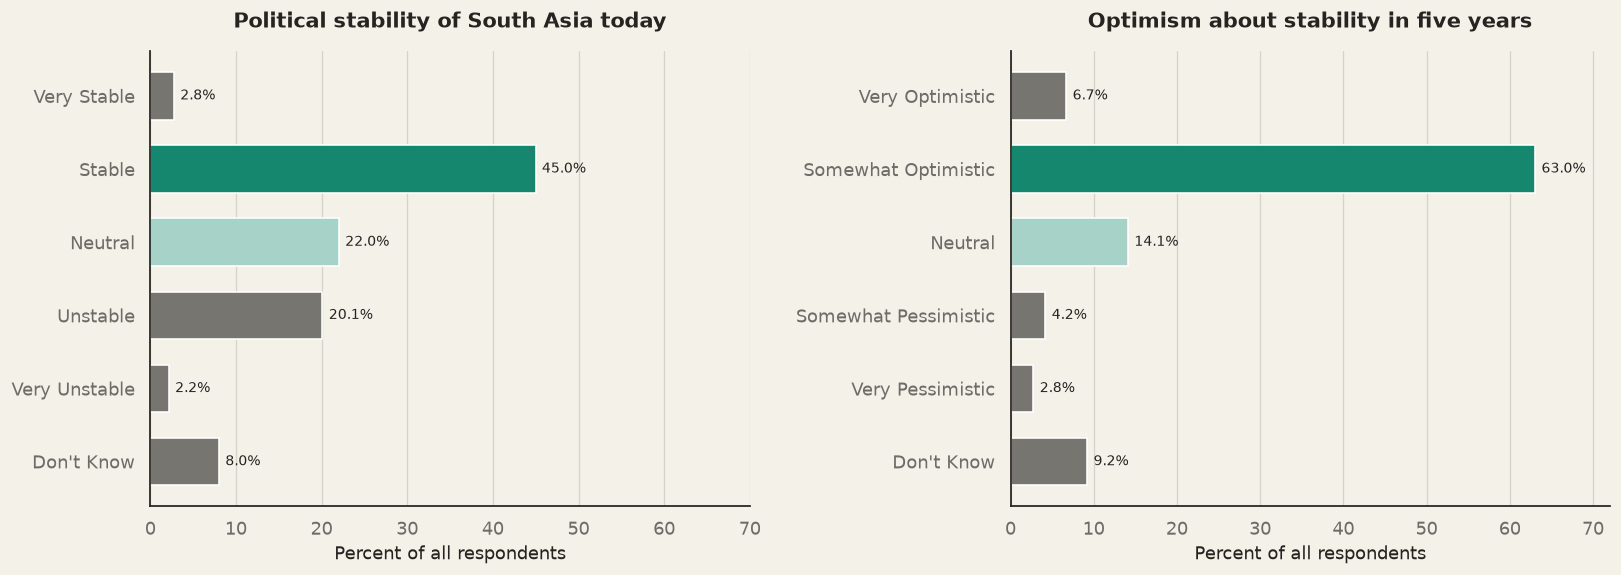

In [65]:
# q5_4 inherited comparison labels from another survey item in the cleaned file.
# Reconstruct its six questionnaire categories from the underlying numeric codes.
df_raw_codes = pd.read_stata(data_path, convert_categoricals=False)
regional_stability = df_raw_codes["q5_4"].map({
    1: "Very Stable",
    2: "Stable",
    3: "Neutral",
    4: "Unstable",
    5: "Very Unstable",
    6: "Don't Know",
})
regional_stability_order = [
    "Very Stable", "Stable", "Neutral", "Unstable", "Very Unstable",
    "Don't Know",
]
regional_stability_counts = regional_stability.value_counts().reindex(
    regional_stability_order, fill_value=0
)
regional_stability_pct = regional_stability_counts.div(
    regional_stability_counts.sum()
).mul(100)

regional_optimism_order = [
    "Very Optimistic", "Somewhat Optimistic", "Neutral",
    "Somewhat Pessimistic", "Very Pessimistic", "Don't Know",
]
regional_optimism = df["q5_5"].astype("string").str.strip()
regional_optimism_counts = regional_optimism.value_counts().reindex(
    regional_optimism_order, fill_value=0
)
regional_optimism_pct = regional_optimism_counts.div(
    regional_optimism_counts.sum()
).mul(100)

display(HTML("<h4>Political stability of South Asia today</h4>"))
display(pd.DataFrame({
    "Frequency": regional_stability_counts.astype(int),
    "Percent": regional_stability_pct,
}).round(1))
display(HTML("<h4>Optimism about stability over the next five years</h4>"))
display(pd.DataFrame({
    "Frequency": regional_optimism_counts.astype(int),
    "Percent": regional_optimism_pct,
}).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.1))
for ax, values, title in [
    (axes[0], regional_stability_pct, "Political stability of South Asia today"),
    (axes[1], regional_optimism_pct, "Optimism about stability in five years"),
]:
    bars = ax.barh(
        values.index,
        values.values,
        color=highlight_bar_colors(values.values),
        height=0.65,
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.1f}%" for value in values],
        padding=4,
        fontsize=8.5,
        color=REPORT_INK,
    )
    ax.set_xlim(0, max(70, values.max() + 9))
    ax.set_xlabel("Percent of all respondents")
    ax.set_ylabel("")
    ax.invert_yaxis()
    report_title(ax, title)
    report_axes(ax, grid_axis="x")
plt.tight_layout(w_pad=2.2)
plt.show()

In [66]:
regional_stability_substantive = regional_stability.where(
    regional_stability.ne("Don't Know")
).dropna()
regional_stable_share = 100 * regional_stability_substantive.isin(
    ["Very Stable", "Stable"]
).mean()
regional_optimism_substantive = regional_optimism.where(
    regional_optimism.ne("Don't Know")
).dropna()
regional_optimistic_share = 100 * regional_optimism_substantive.isin(
    ["Very Optimistic", "Somewhat Optimistic"]
).mean()

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Among substantive responses, <strong>{regional_stable_share:.1f}%</strong> rated South Asia as stable or very stable at the time of the survey. Looking ahead, <strong>{regional_optimistic_share:.1f}%</strong> were very or somewhat optimistic about regional stability over the next five years. The forward-looking assessment is therefore considerably more positive than the evaluation of present conditions. The current-stability categories in this notebook are reconstructed from the questionnaire codes because the cleaned file attached incorrect comparative labels to `q5_4`.
</div>
'''))

### 6.2 Perceived risks to regional stability

,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Perceived regional risk,,,
Corruption and lack of accountability,90.6,7.6,1.9
Unemployment and limited economic opportunities,90.3,7.6,2.1
Political exclusion,85.8,11.7,2.5
Ethnic or religious conflict,85.8,10.5,3.7
Rising cost of living,84.1,12.8,3.1
Social-media misinformation,82.6,14.5,3.0
Foreign or external influence,77.2,16.9,5.9


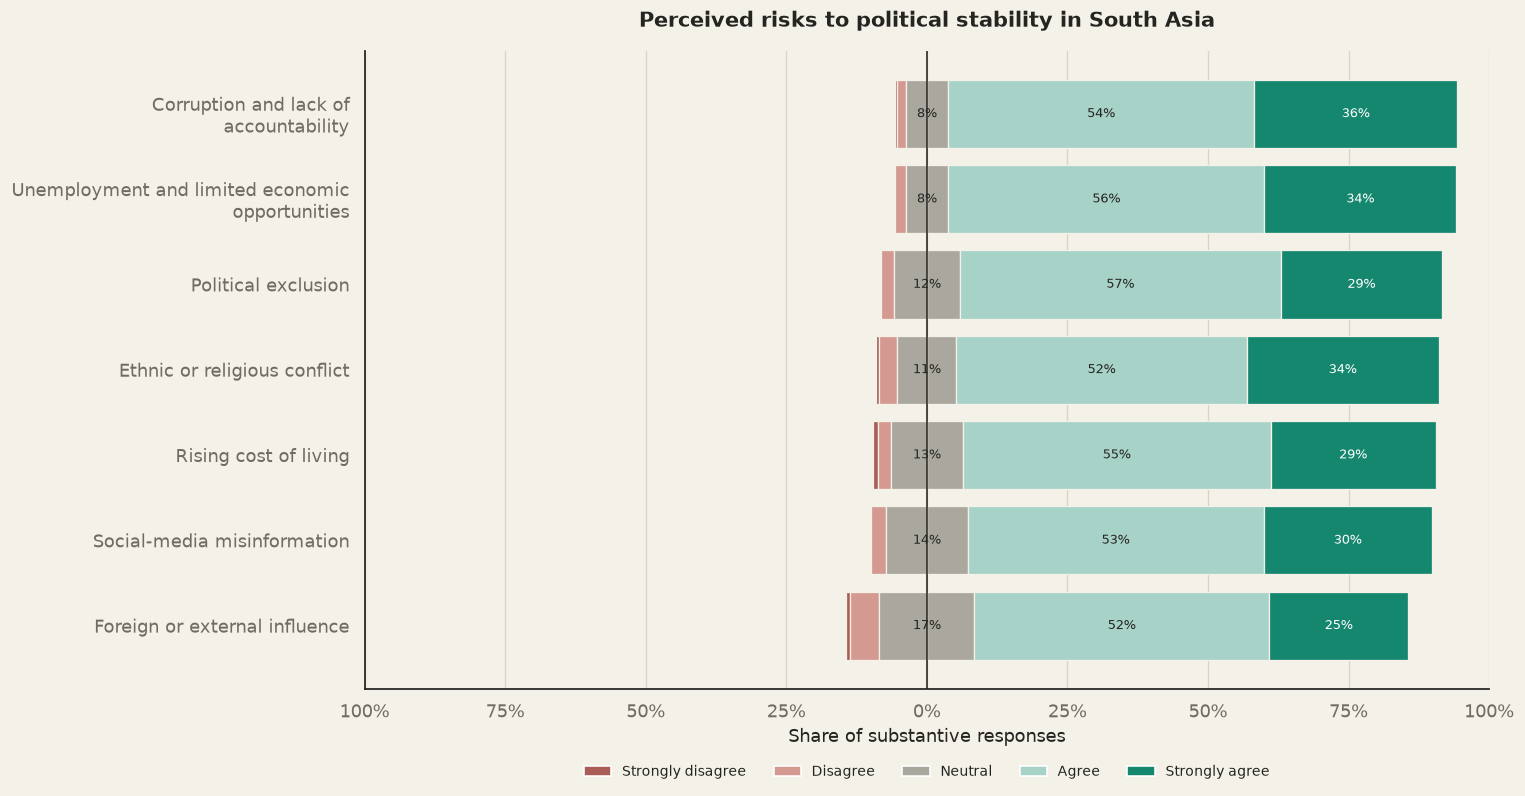

In [67]:
regional_risk_labels = {
    "q5_6_1": "Corruption and lack of accountability",
    "q5_6_2": "Unemployment and limited economic opportunities",
    "q5_6_3": "Political exclusion",
    "q5_6_4": "Rising cost of living",
    "q5_6_5": "Social-media misinformation",
    "q5_6_6": "Foreign or external influence",
    "q5_6_7": "Ethnic or religious conflict",
}
regional_risk_summary, regional_risk_detail, regional_risk_audit = (
    prepare_likert_battery(df, regional_risk_labels)
)
regional_risk_summary.index.name = "Perceived regional risk"
display(regional_risk_summary.round(1))
plot_diverging_likert(
    regional_risk_detail,
    "Perceived risks to political stability in South Asia",
)

### 6.3 Sources of hope for South Asia

,Agree or strongly agree (%),Neutral (%),Disagree or strongly disagree (%)
Source of regional hope,,,
Youth political participation,79.3,16.2,4.5
Governance and anti-corruption reforms,63.8,24.5,11.7
Improved democracy,63.8,26.5,9.7
Economic and employment prospects,59.8,24.4,15.9


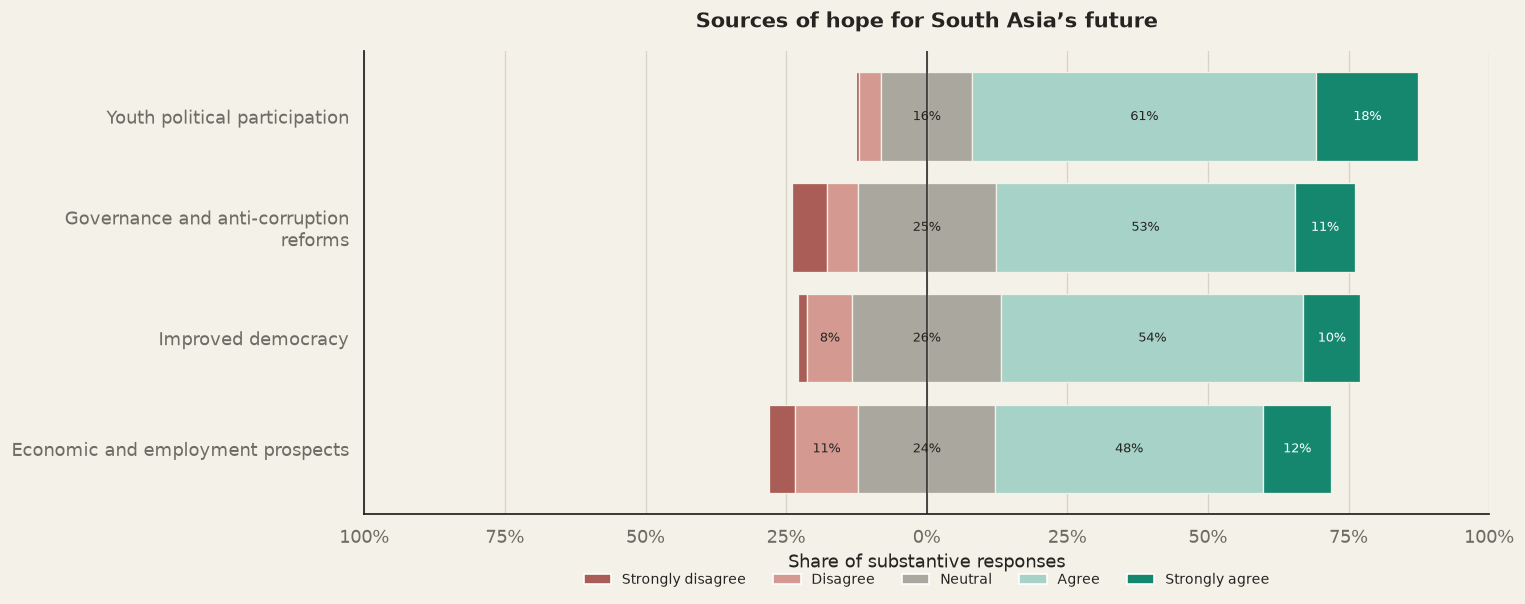

In [68]:
regional_hope_labels = {
    "q5_7_1": "Governance and anti-corruption reforms",
    "q5_7_2": "Youth political participation",
    "q5_7_3": "Improved democracy",
    "q5_7_4": "Economic and employment prospects",
}
regional_hope_summary, regional_hope_detail, regional_hope_audit = (
    prepare_likert_battery(df, regional_hope_labels)
)
regional_hope_summary.index.name = "Source of regional hope"
display(regional_hope_summary.round(1))
plot_diverging_likert(
    regional_hope_detail,
    "Sources of hope for South Asia’s future",
)

### 6.4 Nepal and South Asia in comparative perspective

,Nepal,South Asia
Unemployment and limited economic opportunities,94.6,90.3
Political exclusion,87.4,85.8
Rising cost of living,88.1,84.1
Social-media misinformation,84.1,82.6
Foreign or external influence,79.7,77.2
Ethnic or religious conflict,88.0,85.8


,Nepal,South Asia
Youth political participation,82.2,79.3
Governance and anti-corruption reforms,69.8,63.8
Improved democracy,67.1,63.8
Economic and employment prospects,58.4,59.8


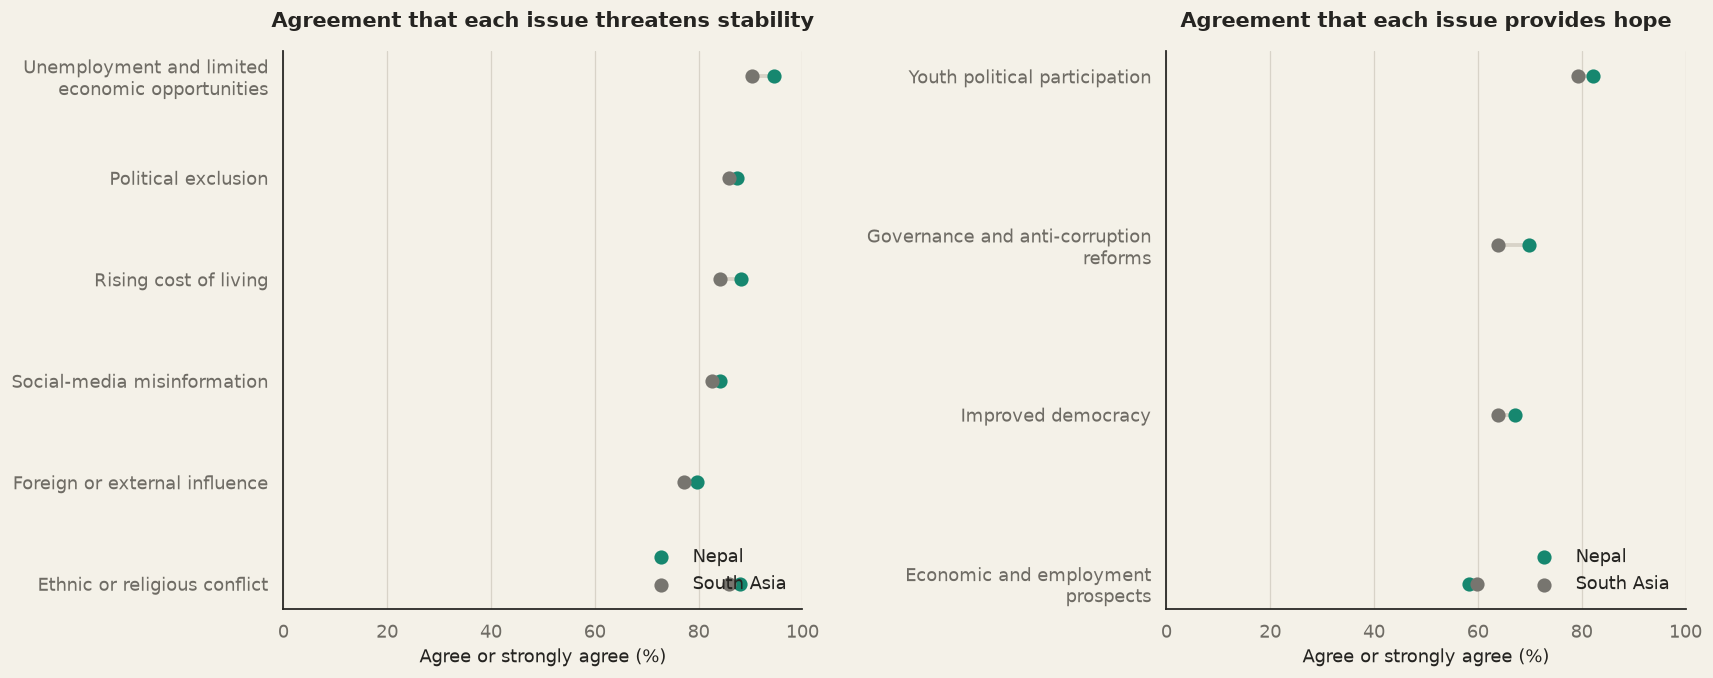

In [69]:
matched_risks = [
    "Unemployment and limited economic opportunities",
    "Political exclusion",
    "Rising cost of living",
    "Social-media misinformation",
    "Foreign or external influence",
    "Ethnic or religious conflict",
]
risk_comparison = pd.DataFrame({
    "Nepal": risk_summary.loc[
        matched_risks, "Agree or strongly agree (%)"
    ],
    "South Asia": regional_risk_summary.loc[
        matched_risks, "Agree or strongly agree (%)"
    ],
})
hope_comparison = pd.DataFrame({
    "Nepal": hope_summary["Agree or strongly agree (%)"],
    "South Asia": regional_hope_summary["Agree or strongly agree (%)"],
})

display(HTML("<h4>Matched stability risks</h4>"))
display(risk_comparison.round(1))
display(HTML("<h4>Matched sources of hope</h4>"))
display(hope_comparison.round(1))

fig, axes = plt.subplots(1, 2, figsize=(15.0, 6.0))
for ax, comparison, title in [
    (axes[0], risk_comparison, "Agreement that each issue threatens stability"),
    (axes[1], hope_comparison, "Agreement that each issue provides hope"),
]:
    y_positions = np.arange(len(comparison))
    for y, nepal_value, regional_value in zip(
        y_positions, comparison["Nepal"], comparison["South Asia"]
    ):
        ax.plot(
            [nepal_value, regional_value], [y, y],
            color=REPORT_GRID, linewidth=2.4, zorder=1,
        )
    ax.scatter(
        comparison["Nepal"], y_positions,
        color=REPORT_TEAL, s=62, label="Nepal", zorder=3,
    )
    ax.scatter(
        comparison["South Asia"], y_positions,
        color=REPORT_GREY, s=62, label="South Asia", zorder=3,
    )
    ax.set_yticks(
        y_positions,
        [textwrap.fill(label, width=31) for label in comparison.index],
    )
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("Agree or strongly agree (%)")
    ax.set_ylabel("")
    report_title(ax, title)
    report_axes(ax, grid_axis="x")
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    legend_handles, legend_labels, frameon=False,
    loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=2,
)
plt.tight_layout(rect=(0, 0.08, 1, 1), w_pad=3.0)
plt.show()

In [70]:
regional_risk_top = regional_risk_summary[
    "Agree or strongly agree (%)"
].nlargest(3)
regional_hope_rank = regional_hope_summary[
    "Agree or strongly agree (%)"
].sort_values(ascending=False)

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> Regional risk perceptions are broad and intense. The three highest-ranked concerns were {regional_risk_top.index[0].lower()} (<strong>{regional_risk_top.iloc[0]:.1f}%</strong>), {regional_risk_top.index[1].lower()} (<strong>{regional_risk_top.iloc[1]:.1f}%</strong>), and {regional_risk_top.index[2].lower()} (<strong>{regional_risk_top.iloc[2]:.1f}%</strong>). Youth political participation was also the strongest source of regional hope (<strong>{regional_hope_rank.iloc[0]:.1f}%</strong>), while {regional_hope_rank.index[-1].lower()} ranked last (<strong>{regional_hope_rank.iloc[-1]:.1f}%</strong>). The Nepal–South Asia comparison shows substantial continuity in how respondents diagnose risks and locate hope: youth agency and governance reform matter in both frames, while confidence in economic prospects is more restrained.
</div>
'''))

### 6.5 Migration intention and optimism about South Asia

Outcome: n (row %),Go Abroad,Stay in Nepal,Don't Know,Total n
Outlook for South Asian stability,,,,
Optimistic,225 (38.6%),283 (48.5%),75 (12.9%),583
Neutral,41 (34.7%),63 (53.4%),14 (11.9%),118
Pessimistic,24 (41.4%),27 (46.6%),7 (12.1%),58


,Valid N,Cramér’s V,p-value
Migration intention × regional optimism,759,2.8e-02,0.9


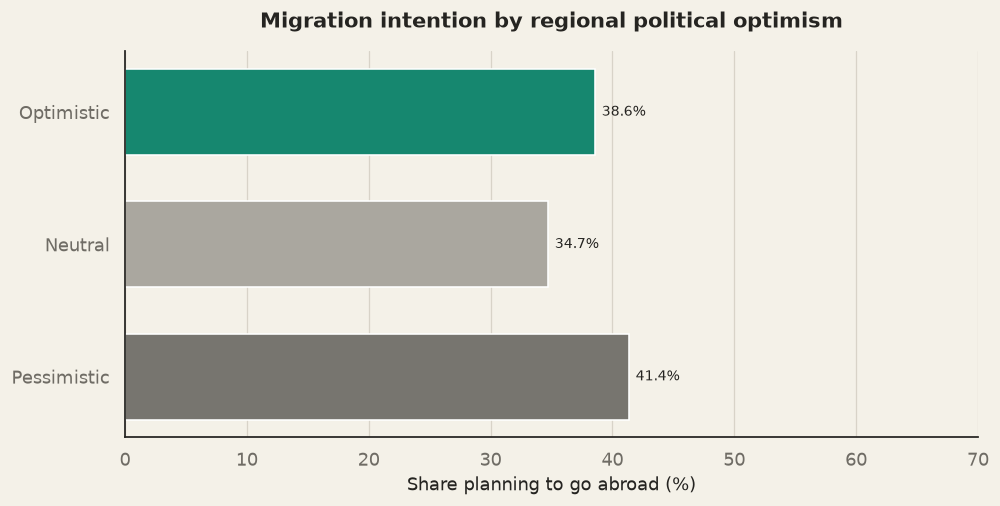

In [71]:
regional_optimism_group = regional_optimism.map({
    "Very Optimistic": "Optimistic",
    "Somewhat Optimistic": "Optimistic",
    "Neutral": "Neutral",
    "Somewhat Pessimistic": "Pessimistic",
    "Very Pessimistic": "Pessimistic",
})
regional_optimism_group_order = ["Optimistic", "Neutral", "Pessimistic"]
regional_migration_result = bridge_crosstab(
    regional_optimism_group,
    migration_intention.where(migration_intention.isin(migration_order)),
    regional_optimism_group_order,
    migration_order,
    "Outlook for South Asian stability",
)
display(regional_migration_result[2])
display(pd.DataFrame({
    "Valid N": [regional_migration_result[3]["n"]],
    "Cramér’s V": [regional_migration_result[3]["v"]],
    "p-value": [regional_migration_result[3]["p"]],
}, index=["Migration intention × regional optimism"]).round(4))

fig, ax = plt.subplots(figsize=(8.8, 4.5))
bars = ax.barh(
    regional_migration_result[1].index,
    regional_migration_result[1]["Go Abroad"],
    color=[REPORT_TEAL, REPORT_LIGHT_GREY, REPORT_GREY],
    height=0.65,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in regional_migration_result[1]["Go Abroad"]],
    padding=4,
    fontsize=9,
    color=REPORT_INK,
)
ax.set_xlim(0, 70)
ax.set_xlabel("Share planning to go abroad (%)")
ax.set_ylabel("")
ax.invert_yaxis()
report_title(ax, "Migration intention by regional political optimism")
report_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

## 7. Probit model of the intention to go abroad

The model compares respondents with a definite plan to **go abroad** against those with a definite plan to **stay in Nepal**. The 106 undecided respondents are omitted from the binary outcome, and complete-case analysis is used for the predictors. Reported effects are average marginal effects: the estimated percentage-point change in the probability of planning to go abroad, holding the other included variables constant. These estimates describe associations, not causal effects.

Model N = 594; converged = True; McFadden pseudo-R² = 0.094


,Coefficient,Robust SE,z,p-value,95% CI low,95% CI high
Predictor,,,,,,
Age (five-year increase),3.3e-01,1.4e-01,2.3e+00,2.1e-02,4.9e-02,6.2e-01
Female (vs male),-2.0e-01,1.1e-01,-1.8e+00,7.9e-02,-4.2e-01,2.3e-02
Rural background (vs urban),-5.2e-01,1.1e-01,-4.6e+00,0.0e+00,-7.3e-01,-3.0e-01
Close family member abroad,5.7e-01,1.1e-01,5.3e+00,0.0e+00,3.6e-01,7.9e-01
Master’s student (vs bachelor’s),-1.1e+00,2.3e-01,-4.7e+00,0.0e+00,-1.5e+00,-6.2e-01
Political efficacy (one-point increase),-7.9e-02,6.9e-02,-1.1e+00,2.6e-01,-2.1e-01,5.7e-02
Political activities (one additional),9.0e-03,4.0e-02,2.2e-01,8.2e-01,-7.0e-02,8.8e-02
Expected Nepal stability (one-point increase),5.0e-03,5.9e-02,8.6e-02,9.3e-01,-1.1e-01,1.2e-01
Youth representation (one-point increase),-7.5e-02,6.9e-02,-1.1e+00,2.7e-01,-2.1e-01,5.9e-02


,Average marginal effect (percentage points),Robust SE,z,p-value,95% CI low,95% CI high
Predictor,,,,,,
Age (five-year increase),11.8,5.0,2.3e+00,2.0e-02,1.9,21.6
Female (vs male),-7.0,4.0,-1.8e+00,8.0e-02,-14.9,0.8
Rural background (vs urban),-18.1,3.7,-4.9e+00,0.0e+00,-25.3,-10.9
Close family member abroad,20.1,3.6,5.7e+00,0.0e+00,13.2,27.1
Master’s student (vs bachelor’s),-37.5,7.7,-4.9e+00,0.0e+00,-52.5,-22.4
Political efficacy (one-point increase),-2.8,2.4,-1.1e+00,2.5e-01,-7.5,2.0
Political activities (one additional),0.3,1.4,2.2e-01,8.2e-01,-2.5,3.1
Expected Nepal stability (one-point increase),0.2,2.1,9.0e-02,9.3e-01,-3.9,4.2
Youth representation (one-point increase),-2.6,2.4,-1.1e+00,2.7e-01,-7.3,2.1


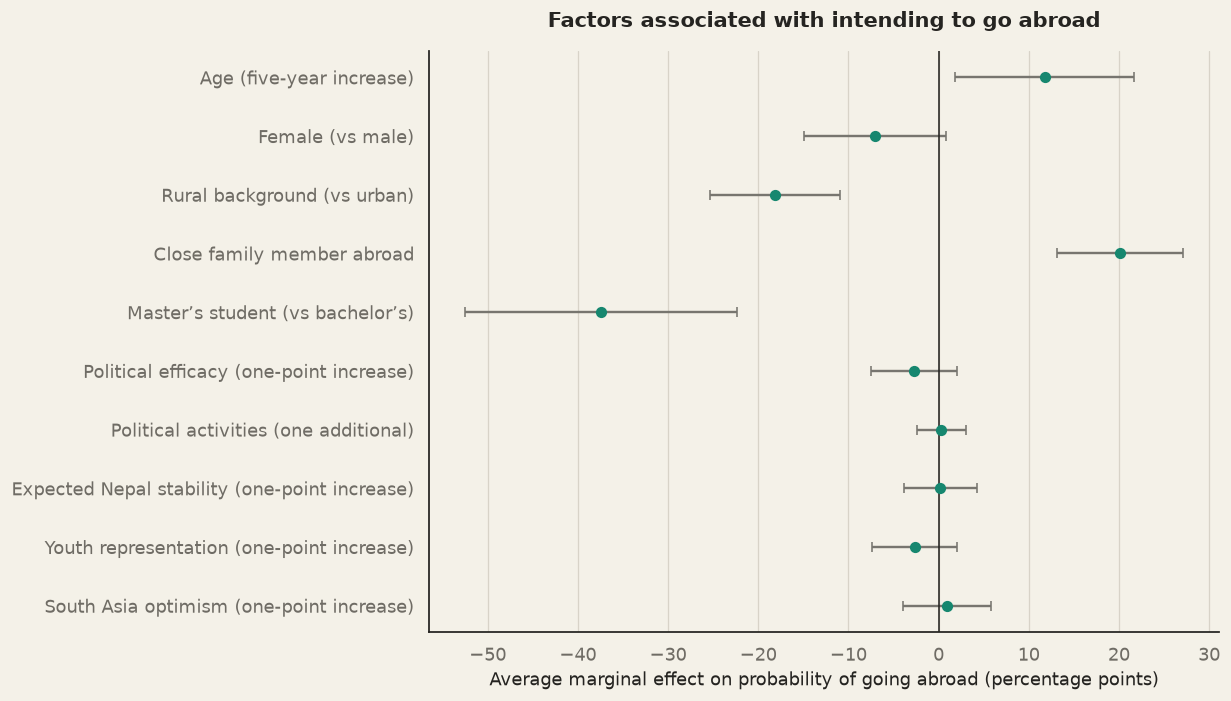

In [72]:
import statsmodels.api as sm

migration_model_data = pd.DataFrame(index=df.index)
migration_model_data["go_abroad"] = migration_intention.map({
    "Go Abroad": 1,
    "Stay in Nepal": 0,
})
migration_model_data["age_five_years"] = (df["age"] - 22) / 5
migration_model_data["female"] = df["gender"].astype("string").map({
    "Male": 0, "Female": 1,
})
migration_model_data["rural_background"] = (
    df["life_place"].astype("string").map({"Urban": 0, "Rural": 1})
)
migration_model_data["family_abroad"] = family_abroad.map({
    "No": 0, "Yes": 1,
})

education_text = df["education"].astype("string").str.strip()
migration_model_data["masters_student"] = (
    education_text.str.startswith("Masters").astype(float)
)
migration_model_data.loc[
    education_text.eq("PHD"), "masters_student"
] = np.nan

migration_model_data["political_efficacy"] = (
    df["q2_9"].astype("string").map({
        "Not at all confident": 1,
        "Not Confident": 2,
        "Neutral": 3,
        "Confident": 4,
        "Very Confident": 5,
    })
)
migration_model_data["political_activities"] = model_data[
    "political_involvement"
]
migration_model_data["future_nepal_stability"] = (
    df["q3_5"].astype("string").map({
        "Much less stable": 1,
        "Somewhat less stable": 2,
        "About the same": 3,
        "Somewhat more stable": 4,
        "Much more stable": 5,
    })
)
migration_model_data["youth_representation"] = (
    df["q4_7"].astype("string").map({
        "Strongly Disagree": 1,
        "Disagree": 2,
        "Neutral": 3,
        "Agree": 4,
        "Strongly Agree": 5,
    })
)
migration_model_data["regional_optimism"] = regional_optimism.map({
    "Very Pessimistic": 1,
    "Somewhat Pessimistic": 2,
    "Neutral": 3,
    "Somewhat Optimistic": 4,
    "Very Optimistic": 5,
})

migration_complete = migration_model_data.dropna().copy()
migration_y = migration_complete.pop("go_abroad").astype(float)
migration_x = sm.add_constant(migration_complete, has_constant="add")
migration_probit = sm.Probit(migration_y, migration_x).fit(
    disp=False, cov_type="HC1"
)

predictor_labels = {
    "age_five_years": "Age (five-year increase)",
    "female": "Female (vs male)",
    "rural_background": "Rural background (vs urban)",
    "family_abroad": "Close family member abroad",
    "masters_student": "Master’s student (vs bachelor’s)",
    "political_efficacy": "Political efficacy (one-point increase)",
    "political_activities": "Political activities (one additional)",
    "future_nepal_stability": "Expected Nepal stability (one-point increase)",
    "youth_representation": "Youth representation (one-point increase)",
    "regional_optimism": "South Asia optimism (one-point increase)",
}

coefficient_table = pd.DataFrame({
    "Coefficient": migration_probit.params,
    "Robust SE": migration_probit.bse,
    "z": migration_probit.tvalues,
    "p-value": migration_probit.pvalues,
    "95% CI low": migration_probit.conf_int()[0],
    "95% CI high": migration_probit.conf_int()[1],
}).drop(index="const")
coefficient_table.index = coefficient_table.index.map(predictor_labels)
coefficient_table.index.name = "Predictor"

migration_marginal = migration_probit.get_margeff(at="overall").summary_frame()
migration_ame_table = pd.DataFrame({
    "Average marginal effect (percentage points)": migration_marginal["dy/dx"] * 100,
    "Robust SE": migration_marginal["Std. Err."] * 100,
    "z": migration_marginal["z"],
    "p-value": migration_marginal["Pr(>|z|)"],
    "95% CI low": migration_marginal["Conf. Int. Low"] * 100,
    "95% CI high": migration_marginal["Cont. Int. Hi."] * 100,
})
migration_ame_table.index = migration_ame_table.index.map(predictor_labels)
migration_ame_table.index.name = "Predictor"

print(
    f"Model N = {len(migration_y):,}; converged = "
    f"{migration_probit.mle_retvals.get('converged', False)}; "
    f"McFadden pseudo-R² = {migration_probit.prsquared:.3f}"
)
display(HTML("<h4>Probit coefficients</h4>"))
display(coefficient_table.round(3))
display(HTML("<h4>Average marginal effects</h4>"))
display(migration_ame_table.round(2))

plot_ame = migration_ame_table.iloc[::-1]
fig, ax = plt.subplots(figsize=(10.8, 6.2))
ax.errorbar(
    plot_ame["Average marginal effect (percentage points)"],
    plot_ame.index,
    xerr=[
        plot_ame["Average marginal effect (percentage points)"]
        - plot_ame["95% CI low"],
        plot_ame["95% CI high"]
        - plot_ame["Average marginal effect (percentage points)"],
    ],
    fmt="o",
    markersize=6,
    color=REPORT_TEAL,
    ecolor=REPORT_GREY,
    elinewidth=1.5,
    capsize=3,
)
ax.axvline(0, color=REPORT_INK, linewidth=1.0)
ax.set_xlabel("Average marginal effect on probability of going abroad (percentage points)")
ax.set_ylabel("")
report_title(ax, "Factors associated with intending to go abroad")
report_axes(ax, grid_axis="x")
plt.tight_layout()
plt.show()

In [73]:
ame = migration_ame_table["Average marginal effect (percentage points)"]
pvals = migration_ame_table["p-value"]

display(HTML(f'''
<div class="interpretation">
<strong>Interpretation.</strong> After adjustment for the other included variables, having a close family member abroad was associated with a <strong>{ame["Close family member abroad"]:.1f}-percentage-point</strong> higher probability of planning to go abroad (p &lt; 0.001). A rural background was associated with a <strong>{abs(ame["Rural background (vs urban)"]):.1f}-point lower</strong> probability (p &lt; 0.001), and master’s students had a <strong>{abs(ame["Master’s student (vs bachelor’s)"]):.1f}-point lower</strong> probability than bachelor’s students (p &lt; 0.001). A five-year increase in age was associated with a <strong>{ame["Age (five-year increase)"]:.1f}-point higher</strong> probability (p = {pvals["Age (five-year increase)"]:.3f}). Political efficacy, political activity, expectations of Nepal’s future stability, perceived youth representation, and optimism about South Asian stability were not independently significant at the 5% level in this specification. The results suggest that migration intention is more clearly structured by family exposure and life-course background than by the political outlook measures included here; they should not be read as causal effects.
</div>
'''))

## 8. Theme 3 conclusion and cross-theme synthesis

In [74]:
display(HTML(f'''
<div class="interpretation">
<strong>Overall reading.</strong> The sample combines strong political engagement with divided personal futures. Although staying in Nepal was the largest single plan (<strong>{migration_pct["Stay in Nepal"]:.1f}%</strong>), more than one in three intended to go abroad and a further <strong>{migration_pct["Don't Know"]:.1f}%</strong> were undecided. Students on both paths emphasized study and employment. Family migration experience was strongly connected to plans to leave, while political optimism did not independently explain migration intention in the probit model.
<br><br>
The regional findings reinforce the earlier themes. Students saw youth protest across South Asia primarily through governance, corruption, trust, and economic opportunity; they also believed protest can travel across borders. Their outlook was cautiously hopeful: future regional stability was viewed more positively than current conditions, and youth political participation was the strongest source of hope for both Nepal and South Asia. Taken together, the three themes portray students as politically attentive and hopeful about youth agency, but still making educational and migration choices under persistent concerns about institutions and economic opportunity.
</div>
'''))

### Analytical cautions

- The survey describes 836 students in the final non-pilot sample; it is not a probability estimate for all young people in Nepal.
- Voting, political engagement, migration plans, and attitudes are self-reported.
- Migration intention is not the same as completed migration and may change over time.
- Cross-tabulations and regression coefficients are associations from one survey wave. Temporal ordering and causal effects cannot be established.
- Non-substantive responses are shown or excluded according to the stated denominator, and conditional questions use only the eligible respondents.